# 03. Interpretabilidad del modelo e Invisible Dog Score

Este notebook tiene como objetivo interpretar el modelo final seleccionado en la fase de modelización y transformar sus probabilidades en una herramienta operativa de priorización: el **Invisible Dog Score**.

A diferencia de la fase de modelización, en este notebook no se entrenan nuevos modelos ni se redefinen variables. Se parte del dataset preparado y del modelo final guardado previamente, con el fin de:

- reconstruir las predicciones del modelo final;
- transformar la probabilidad estimada en un score entre 0 y 100;
- definir bandas operativas de riesgo;
- analizar la distribución del score;
- estudiar la capacidad de priorización mediante deciles y segmentos Top-K;
- interpretar el comportamiento global y local del modelo;
- generar salidas exportables para su análisis y uso posterior.

El objetivo final es que el modelo no se interprete únicamente como un clasificador binario, sino como una herramienta de apoyo a la decisión que permita priorizar perros con mayor riesgo estimado de larga estancia.

In [1]:
# Librerías principales

from pathlib import Path
import os
import sys
import warnings
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

print("Librerías principales cargadas correctamente.")

Librerías principales cargadas correctamente.


In [2]:
# Comprobación de SHAP

try:
    import shap
    SHAP_DISPONIBLE = True
    print("SHAP cargado correctamente.")
    print("Versión de SHAP:", shap.__version__)
except ImportError:
    SHAP_DISPONIBLE = False
    print("SHAP no está instalado en este entorno.")
    print("Instálalo desde la terminal de VS Code con:")
    print(r'& "$env:USERPROFILE\venvs\invisible-dogs\Scripts\python.exe" -m pip install shap')

SHAP cargado correctamente.
Versión de SHAP: 0.52.0


## 1. Carga de datos, modelo final y validaciones iniciales

En esta primera parte se cargan los elementos necesarios para interpretar el modelo final:

- el dataset preparado;
- el modelo final guardado;
- las variables utilizadas por CatBoost y LightGBM;
- el umbral de decisión seleccionado;
- los pesos del ensemble.

Antes de calcular el Invisible Dog Score, se realizan comprobaciones para asegurar que el dataset contiene todas las variables necesarias para reconstruir las predicciones del modelo.

In [3]:
# Definición de rutas del proyecto para ejecución local en VS Code

project_path = Path.cwd()

if project_path.name == "notebooks":
    project_path = project_path.parent

data_path = project_path / "data"
processed_data_path = data_path / "processed"

outputs_path = project_path / "outputs"
figures_path = outputs_path / "figures"
models_path = outputs_path / "models"
interpretability_path = outputs_path / "interpretability"

for path in [figures_path, models_path, interpretability_path]:
    path.mkdir(parents=True, exist_ok=True)

print("Ruta del proyecto:", project_path)
print("Carpeta de datos procesados:", processed_data_path)
print("Carpeta de modelos:", models_path)
print("Carpeta de figuras:", figures_path)
print("Carpeta de interpretabilidad:", interpretability_path)

print("\nComprobaciones:")
print("Existe data/processed:", processed_data_path.exists())
print("Existe outputs/models:", models_path.exists())
print("Existe outputs/figures:", figures_path.exists())
print("Existe outputs/interpretability:", interpretability_path.exists())

Ruta del proyecto: g:\Mi unidad\TFM\invisible-dogs-tfm
Carpeta de datos procesados: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed
Carpeta de modelos: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models
Carpeta de figuras: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures
Carpeta de interpretabilidad: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability

Comprobaciones:
Existe data/processed: True
Existe outputs/models: True
Existe outputs/figures: True
Existe outputs/interpretability: True


### 1.1. Carga del dataset preparado

Se carga el dataset final generado en la fase de preparación de datos. Este dataset contiene las variables depuradas, las variables derivadas y los controles temporales necesarios para aplicar el modelo final sin volver a construir la base de datos desde cero.

In [4]:
# Carga del dataset preparado

dataset_path = processed_data_path / "invisible_dogs_dataset_preparado.csv"

if not dataset_path.exists():
    raise FileNotFoundError(
        f"No se ha encontrado el dataset preparado en la ruta esperada: {dataset_path}"
    )

dogs_model_ready = pd.read_csv(dataset_path)

print("Dataset preparado cargado correctamente.")
print("Ruta:", dataset_path)
print("Dimensiones:", dogs_model_ready.shape)

display(dogs_model_ready.head())

Dataset preparado cargado correctamente.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\invisible_dogs_dataset_preparado.csv
Dimensiones: (93803, 57)


,animal_id,intake_datetime,outcome_datetime,stay_days,stay_days_rounded,target_long_stay,intake_type,intake_condition,sex_upon_intake,sex,sterilized_intake,age_upon_intake,age_months_intake,age_group,name_intake,has_name_intake,found_location,found_location_grouped,breed_intake,is_mixed_breed,main_breed,main_breed_grouped,has_secondary_breed,secondary_breed,breed_num_terms,color_intake,main_color,main_color_grouped,has_secondary_color,secondary_color,color_num_terms,intake_month,intake_dayofweek,intake_hour,intake_is_weekend,intake_season,age_group_intake_type,condition_intake_type,breed_age_group,season_condition,previous_intake_count,is_repeat_intake,days_since_previous_intake,previous_outcome_type,previous_stay_days,previous_long_stay_count,previous_owner_surrender_count,previous_stray_count,n_intakes_dogs_last_7d,n_intakes_dogs_last_30d,n_outcomes_dogs_last_7d,n_outcomes_dogs_last_30d,n_adoptions_dogs_last_30d,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d,outcome_type,outcome_subtype
0,A006100,2014-03-07 14:26:00,2014-03-08 17:10:00,1.113889,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,6 years,72.0,Adulto,Scamp,Con nombre registrado,8700 Research in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,3,4,14,0,Primavera,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,171.0,864.0,163.0,772.0,337.0,460.0,1.117723,Return to Owner,NaN
1,A006100,2014-12-19 10:21:00,2014-12-20 16:35:00,1.259722,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,7 years,84.0,Adulto,Scamp,Con nombre registrado,8700 Research Blvd in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,12,4,10,0,Invierno,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Invierno | Normal,1,1,286.829861,Return to Owner,2.0,0.0,0.0,0.0,228.0,925.0,202.0,976.0,414.0,404.0,0.946776,Return to Owner,NaN
2,A047759,2014-04-02 15:55:00,2014-04-07 15:12:00,4.970139,5,0,Owner Surrender,Normal,Neutered Male,Macho,Esterilizado,10 years,120.0,Senior,Oreo,Con nombre registrado,Austin (TX),Austin,Dachshund,Raza no mixta,Dachshund,Dachshund,0,NaN,1,Tricolor,Tricolor,Tricolor,0,NaN,1,4,2,15,0,Primavera,Senior | Owner Surrender,Normal | Owner Surrender,Dachshund | Senior,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,205.0,900.0,191.0,864.0,354.0,463.0,1.040462,Transfer,Partner
3,A134067,2013-11-16 09:02:00,2013-11-16 11:54:00,0.119444,1,0,Public Assist,Injured,Neutered Male,Macho,Esterilizado,16 years,192.0,Senior,Bandit,Con nombre registrado,12034 Research Blvd in Austin (TX),Austin,Shetland Sheepdog,Raza no mixta,Shetland Sheepdog,Otras razas,0,NaN,1,Brown/White,Brown,Brown,1,White,2,11,5,9,1,Otoño,Senior | Public Assist,Injured | Public Assist,Otras razas | Senior,Otoño | Injured,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,181.0,855.0,176.0,777.0,288.0,314.0,1.098972,Return to Owner,NaN
4,A141142,2013-11-16 14:46:00,2013-11-17 11:40:00,0.870833,1,0,Stray,Aged,Spayed Female,Hembra,Esterilizado,15 years,180.0,Senior,Bettie,Con nombre registrado,Austin (TX),Austin,Labrador Retriever/Pit Bull,Raza mixta,Labrador Retriever,Labrador Retriever,1,Pit Bull,2,Black/White,Black,Black,1,White,2,11,5,14,1,Otoño,Senior | Stray,Aged | Stray,Labrador Retriever | Senior,Otoño | Aged,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,179.0,854.0,174.0,786.0,290.0,315.0,1.085133,Return to Owner,NaN


In [5]:
# Validación básica del dataset preparado

columnas_minimas = [
    "animal_id",
    "intake_datetime",
    "outcome_datetime",
    "stay_days",
    "stay_days_rounded",
    "target_long_stay"
]

columnas_ausentes = [
    col for col in columnas_minimas
    if col not in dogs_model_ready.columns
]

if columnas_ausentes:
    raise ValueError(f"Faltan columnas mínimas necesarias: {columnas_ausentes}")

print("Columnas mínimas disponibles.")

print("\nDimensiones del dataset:")
print("Registros:", dogs_model_ready.shape[0])
print("Columnas:", dogs_model_ready.shape[1])

print("\nDistribución de target_long_stay:")
display(
    dogs_model_ready["target_long_stay"]
    .value_counts()
    .rename("n_registros")
    .to_frame()
)

print("\nDistribución porcentual de target_long_stay:")
display(
    dogs_model_ready["target_long_stay"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("porcentaje")
    .to_frame()
)

Columnas mínimas disponibles.

Dimensiones del dataset:
Registros: 93803
Columnas: 57

Distribución de target_long_stay:


,n_registros
target_long_stay,
0,78714
1,15089



Distribución porcentual de target_long_stay:


,porcentaje
target_long_stay,
0,83.91
1,16.09


### 1.2. Carga del modelo final

A continuación se carga el modelo final guardado en la fase de modelización. Este objeto contiene los modelos entrenados, la configuración del ensemble, las variables utilizadas y el umbral de decisión seleccionado.

La carga del modelo permite reconstruir las probabilidades de larga estancia sin volver a entrenar ningún algoritmo.

In [6]:
# Carga del modelo final guardado

modelo_final_path = models_path / "modelo_final_invisible_dogs.pkl"

if not modelo_final_path.exists():
    raise FileNotFoundError(
        f"No se ha encontrado el modelo final en la ruta esperada: {modelo_final_path}"
    )

modelo_final_guardado = joblib.load(modelo_final_path)

print("Modelo final cargado correctamente.")
print("Ruta:", modelo_final_path)

print("\nTipo de objeto cargado:")
print(type(modelo_final_guardado))

print("\nClaves disponibles en el objeto guardado:")
for clave in modelo_final_guardado.keys():
    print("-", clave)

Modelo final cargado correctamente.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\modelo_final_invisible_dogs.pkl

Tipo de objeto cargado:
<class 'dict'>

Claves disponibles en el objeto guardado:
- modelo_final_nombre
- usar_ensemble
- peso_catboost
- peso_lgbm
- umbral_decision
- umbral_catboost
- umbral_lgbm
- umbral_ensemble
- modelo_catboost
- modelo_lgbm
- modelo_base_referencia
- variables_catboost
- variables_categoricas_catboost
- variables_lgbm
- variables_base_referencia
- hiperparametros_catboost
- hiperparametros_lgbm
- experimento_ablacion_seleccionado
- candidato_catboost
- candidato_lightgbm
- metricas_test
- tabla_umbrales_operativos_test
- metricas_topk_test
- calibracion_deciles_test
- comparacion_final_test
- comparacion_modelos_finales_oof
- columnas_derivadas_preparacion_usadas_en_modelizacion
- dataset_preparado_path
- split_test_path
- test_indices


In [7]:
# Extracción de la configuración del modelo final

modelo_final_nombre = modelo_final_guardado["modelo_final_nombre"]

usar_ensemble = modelo_final_guardado["usar_ensemble"]

modelo_catboost = modelo_final_guardado["modelo_catboost"]
modelo_lgbm = modelo_final_guardado["modelo_lgbm"]

peso_catboost = modelo_final_guardado["peso_catboost"]
peso_lgbm = modelo_final_guardado["peso_lgbm"]

umbral_decision = modelo_final_guardado["umbral_decision"]

variables_catboost = modelo_final_guardado["variables_catboost"]
variables_lgbm = modelo_final_guardado["variables_lgbm"]

print("Modelo final:", modelo_final_nombre)
print("Usa ensemble:", usar_ensemble)

print("\nPeso CatBoost:", peso_catboost)
print("Peso LightGBM:", peso_lgbm)

print("\nUmbral final:", umbral_decision)

print("\nVariables CatBoost:", len(variables_catboost))
print("Variables LightGBM:", len(variables_lgbm))

Modelo final: Ensemble CatBoost + LightGBM
Usa ensemble: True

Peso CatBoost: 0.725
Peso LightGBM: 0.275

Umbral final: 0.24

Variables CatBoost: 41
Variables LightGBM: 37


In [8]:
# Comprobación de que todas las variables existen

columnas_catboost_faltantes = [
    col for col in variables_catboost
    if col not in dogs_model_ready.columns
]

columnas_lgbm_faltantes = [
    col for col in variables_lgbm
    if col not in dogs_model_ready.columns
]

print("Variables CatBoost no encontradas:", columnas_catboost_faltantes)
print("Variables LightGBM no encontradas:", columnas_lgbm_faltantes)

assert len(columnas_catboost_faltantes) == 0
assert len(columnas_lgbm_faltantes) == 0

print("\nTodas las variables del modelo están disponibles.")

Variables CatBoost no encontradas: []
Variables LightGBM no encontradas: []

Todas las variables del modelo están disponibles.


### 1.3. Revisión de controles temporales

Se revisan los controles generados en la fase de preparación de datos para comprobar que las variables históricas y de contexto utilizadas por el modelo se construyeron únicamente con información disponible antes de cada entrada.

Esta comprobación refuerza que la interpretación posterior del score se apoya en variables compatibles con un uso predictivo real, evitando incorporar información futura del resultado.


In [9]:
# Revisión de controles de fuga temporal generados en la preparación de datos

controles_fuga_path = processed_data_path / "controles_fuga_temporal_preparacion.csv"

if controles_fuga_path.exists():
    controles_fuga_temporal = pd.read_csv(controles_fuga_path)
    print("Controles de fuga temporal cargados correctamente.")
    print("Ruta:", controles_fuga_path)
    display(controles_fuga_temporal)
else:
    controles_fuga_temporal = None
    print("No se ha encontrado el archivo de controles de fuga temporal en la ruta esperada:")
    print(controles_fuga_path)


Controles de fuga temporal cargados correctamente.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\controles_fuga_temporal_preparacion.csv


,control,resultado,detalle
0,Historial enriquecido restringido a estancias ...,OK,"El cálculo de previous_outcome_type, previous_..."
1,Días desde entrada previa no negativos,OK,days_since_previous_intake solo presenta valor...
2,Variables de contexto no negativas,OK,"Los conteos de entradas, salidas, adopciones y..."
3,Ratio entradas/salidas calculable,OK,ratio_intakes_outcomes_30d se calcula dividien...
4,Ventanas temporales anteriores a la entrada,OK,Las ventanas de 7 y 30 días se calculan con np...


## 2. Reconstrucción de probabilidades e Invisible Dog Score

En esta sección se reconstruyen las probabilidades estimadas por el modelo final para cada perro del dataset preparado.

El modelo final es un ensemble formado por CatBoost y LightGBM. La probabilidad final se obtiene como una combinación ponderada de las probabilidades generadas por ambos modelos. Posteriormente, esta probabilidad se transforma en una escala de 0 a 100 denominada **Invisible Dog Score**.

Este score permite ordenar a los perros según su riesgo estimado de larga estancia y facilita una interpretación más operativa que una predicción binaria.

In [10]:
# Reconstrucción de probabilidades del modelo final

variables_categoricas_catboost = modelo_final_guardado.get(
    "variables_categoricas_catboost",
    []
)

def preparar_datos_catboost_interpretabilidad(X, variables_categoricas):
    """
    Prepara las variables de entrada para CatBoost siguiendo el mismo criterio
    utilizado en la fase de modelización.
    """
    X_catboost = X.copy()

    for variable in variables_categoricas:
        if variable in X_catboost.columns:
            X_catboost[variable] = (
                X_catboost[variable]
                .fillna("Sin información")
                .astype(str)
            )

    return X_catboost


X_catboost = preparar_datos_catboost_interpretabilidad(
    dogs_model_ready[variables_catboost],
    variables_categoricas_catboost
)

X_lgbm = dogs_model_ready[variables_lgbm].copy()

proba_catboost = modelo_catboost.predict_proba(X_catboost)[:, 1]
proba_lgbm = modelo_lgbm.predict_proba(X_lgbm)[:, 1]

proba_ensemble = (
    peso_catboost * proba_catboost
    + peso_lgbm * proba_lgbm
)

if usar_ensemble:
    probabilidad_final = proba_ensemble
else:
    if modelo_final_nombre == "CatBoost seleccionado":
        probabilidad_final = proba_catboost
    elif modelo_final_nombre == "LightGBM seleccionado":
        probabilidad_final = proba_lgbm
    else:
        raise ValueError("No se reconoce el modelo final seleccionado.")

prediccion_larga_estancia = (probabilidad_final >= umbral_decision).astype(int)

print("Probabilidades reconstruidas correctamente.")
print("Número de registros:", len(probabilidad_final))
print("Probabilidad mínima:", round(probabilidad_final.min(), 4))
print("Probabilidad media:", round(probabilidad_final.mean(), 4))
print("Probabilidad máxima:", round(probabilidad_final.max(), 4))
print("Umbral aplicado:", umbral_decision)
print("Predicciones positivas:", prediccion_larga_estancia.sum())

Probabilidades reconstruidas correctamente.
Número de registros: 93803
Probabilidad mínima: 0.0003
Probabilidad media: 0.1648
Probabilidad máxima: 0.9938
Umbral aplicado: 0.24
Predicciones positivas: 21560


In [11]:
# Creación del dataset de scores

columnas_contexto_score = [
    "animal_id",
    "intake_datetime",
    "outcome_datetime",
    "stay_days",
    "stay_days_rounded",
    "target_long_stay",
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_months_intake",
    "age_group",
    "breed_intake",
    "color_intake",
    "found_location",
    "previous_intake_count",
    "is_repeat_intake",
    "previous_stay_days",
    "previous_long_stay_count",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

columnas_contexto_score = [
    col for col in columnas_contexto_score
    if col in dogs_model_ready.columns
]

dogs_score = dogs_model_ready[columnas_contexto_score].copy()

dogs_score["probabilidad_catboost"] = proba_catboost
dogs_score["probabilidad_lgbm"] = proba_lgbm
dogs_score["probabilidad_larga_estancia"] = probabilidad_final

dogs_score["invisible_dog_score"] = (
    dogs_score["probabilidad_larga_estancia"] * 100
).round(1)

dogs_score["prediccion_larga_estancia"] = prediccion_larga_estancia

dogs_score["resultado_real"] = np.where(
    dogs_score["target_long_stay"] == 1,
    "Larga estancia",
    "No larga estancia"
)

dogs_score["prediccion_modelo"] = np.where(
    dogs_score["prediccion_larga_estancia"] == 1,
    "Riesgo de larga estancia",
    "Sin riesgo estimado"
)

print("Dataset de scores creado correctamente.")
print("Dimensiones:", dogs_score.shape)

display(
    dogs_score[
        [
            "animal_id",
            "target_long_stay",
            "probabilidad_larga_estancia",
            "invisible_dog_score",
            "prediccion_larga_estancia",
            "resultado_real",
            "prediccion_modelo"
        ]
    ].head(10)
)

Dataset de scores creado correctamente.
Dimensiones: (93803, 28)


,animal_id,target_long_stay,probabilidad_larga_estancia,invisible_dog_score,prediccion_larga_estancia,resultado_real,prediccion_modelo
0,A006100,0,0.025108,2.5,0,No larga estancia,Sin riesgo estimado
1,A006100,0,0.018706,1.9,0,No larga estancia,Sin riesgo estimado
2,A047759,0,0.089950,9.0,0,No larga estancia,Sin riesgo estimado
3,A134067,0,0.011408,1.1,0,No larga estancia,Sin riesgo estimado
4,A141142,0,0.024674,2.5,0,No larga estancia,Sin riesgo estimado
5,A163459,0,0.013615,1.4,0,No larga estancia,Sin riesgo estimado
6,A165752,0,0.020191,2.0,0,No larga estancia,Sin riesgo estimado
7,A178569,0,0.013722,1.4,0,No larga estancia,Sin riesgo estimado
8,A189592,0,0.009591,1.0,0,No larga estancia,Sin riesgo estimado
9,A200922,1,0.334883,33.5,1,Larga estancia,Riesgo de larga estancia


In [12]:
# Resumen descriptivo del Invisible Dog Score

resumen_score = dogs_score["invisible_dog_score"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

print("Resumen del Invisible Dog Score:")
display(resumen_score.to_frame(name="valor"))

print("\nDistribución de predicciones con el umbral seleccionado:")
display(
    dogs_score["prediccion_modelo"]
    .value_counts()
    .rename("n_registros")
    .to_frame()
)

print("\nDistribución porcentual de predicciones:")
display(
    dogs_score["prediccion_modelo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("porcentaje")
    .to_frame()
)

Resumen del Invisible Dog Score:


,valor
count,93803.00
mean,16.48
std,20.35
min,0.00
1%,0.20
5%,0.50
10%,1.10
25%,3.10
50%,7.70
75%,21.70



Distribución de predicciones con el umbral seleccionado:


,n_registros
prediccion_modelo,
Sin riesgo estimado,72243
Riesgo de larga estancia,21560



Distribución porcentual de predicciones:


,porcentaje
prediccion_modelo,
Sin riesgo estimado,77.02
Riesgo de larga estancia,22.98


### 2.1. Definición de bandas de riesgo

Para facilitar la interpretación del Invisible Dog Score, se definen cuatro bandas operativas de riesgo. Estas bandas permiten transformar una puntuación numérica entre 0 y 100 en una categoría comprensible y accionable.

Las bandas propuestas son:

- **Bajo riesgo**: score entre 0 y 24.
- **Riesgo medio**: score entre 25 y 49.
- **Riesgo alto**: score entre 50 y 74.
- **Riesgo crítico**: score entre 75 y 100.

Estas bandas no sustituyen a la probabilidad estimada por el modelo, sino que la traducen a un lenguaje más útil para priorizar actuaciones.

In [13]:
# Definición de bandas de riesgo del Invisible Dog Score

def asignar_banda_riesgo(score):
    if score < 25:
        return "Bajo riesgo"
    elif score < 50:
        return "Riesgo medio"
    elif score < 75:
        return "Riesgo alto"
    else:
        return "Riesgo crítico"


dogs_score["banda_riesgo"] = dogs_score["invisible_dog_score"].apply(asignar_banda_riesgo)

orden_bandas = [
    "Bajo riesgo",
    "Riesgo medio",
    "Riesgo alto",
    "Riesgo crítico"
]

dogs_score["banda_riesgo"] = pd.Categorical(
    dogs_score["banda_riesgo"],
    categories=orden_bandas,
    ordered=True
)

print("Bandas de riesgo creadas correctamente.")

display(
    dogs_score[
        [
            "animal_id",
            "target_long_stay",
            "probabilidad_larga_estancia",
            "invisible_dog_score",
            "banda_riesgo",
            "prediccion_modelo",
            "resultado_real"
        ]
    ].head(10)
)

Bandas de riesgo creadas correctamente.


,animal_id,target_long_stay,probabilidad_larga_estancia,invisible_dog_score,banda_riesgo,prediccion_modelo,resultado_real
0,A006100,0,0.025108,2.5,Bajo riesgo,Sin riesgo estimado,No larga estancia
1,A006100,0,0.018706,1.9,Bajo riesgo,Sin riesgo estimado,No larga estancia
2,A047759,0,0.089950,9.0,Bajo riesgo,Sin riesgo estimado,No larga estancia
3,A134067,0,0.011408,1.1,Bajo riesgo,Sin riesgo estimado,No larga estancia
4,A141142,0,0.024674,2.5,Bajo riesgo,Sin riesgo estimado,No larga estancia
5,A163459,0,0.013615,1.4,Bajo riesgo,Sin riesgo estimado,No larga estancia
6,A165752,0,0.020191,2.0,Bajo riesgo,Sin riesgo estimado,No larga estancia
7,A178569,0,0.013722,1.4,Bajo riesgo,Sin riesgo estimado,No larga estancia
8,A189592,0,0.009591,1.0,Bajo riesgo,Sin riesgo estimado,No larga estancia
9,A200922,1,0.334883,33.5,Riesgo medio,Riesgo de larga estancia,Larga estancia


In [14]:
# Resumen operativo por banda de riesgo

resumen_bandas_riesgo = (
    dogs_score
    .groupby("banda_riesgo", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        score_medio=("invisible_dog_score", "mean"),
        score_minimo=("invisible_dog_score", "min"),
        score_maximo=("invisible_dog_score", "max"),
        casos_larga_estancia=("target_long_stay", "sum"),
        tasa_real_larga_estancia=("target_long_stay", "mean")
    )
    .reset_index()
)

resumen_bandas_riesgo["porcentaje_perros"] = (
    resumen_bandas_riesgo["n_perros"] / len(dogs_score) * 100
)

resumen_bandas_riesgo = resumen_bandas_riesgo[
    [
        "banda_riesgo",
        "n_perros",
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "casos_larga_estancia",
        "tasa_real_larga_estancia"
    ]
]

resumen_bandas_riesgo[
    [
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "tasa_real_larga_estancia"
    ]
] = resumen_bandas_riesgo[
    [
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "tasa_real_larga_estancia"
    ]
].round(4)

print("Resumen por bandas de riesgo:")
display(resumen_bandas_riesgo)

Resumen por bandas de riesgo:


,banda_riesgo,n_perros,porcentaje_perros,score_medio,score_minimo,score_maximo,casos_larga_estancia,tasa_real_larga_estancia
0,Bajo riesgo,72933,77.7512,7.1679,0.0,24.9,2142,0.0294
1,Riesgo medio,12345,13.1606,35.6509,25.0,49.9,5273,0.4271
2,Riesgo alto,6125,6.5296,60.9775,50.0,74.9,5316,0.8679
3,Riesgo crítico,2400,2.5586,87.1853,75.0,99.4,2358,0.9825


In [15]:
# Guardado de salidas de score y bandas de riesgo

scores_path = interpretability_path / "invisible_dogs_scores.csv"
resumen_bandas_path = interpretability_path / "resumen_bandas_riesgo.csv"

dogs_score.to_csv(scores_path, index=False, encoding="utf-8-sig")
resumen_bandas_riesgo.to_csv(resumen_bandas_path, index=False, encoding="utf-8-sig")

print("Archivo de scores guardado en:")
print(scores_path)

print("\nResumen de bandas guardado en:")
print(resumen_bandas_path)

Archivo de scores guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\invisible_dogs_scores.csv

Resumen de bandas guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\resumen_bandas_riesgo.csv


### 2.2. Evaluación del score sobre el conjunto de prueba

El Invisible Dog Score puede calcularse para todo el dataset con el fin de generar una salida global de priorización. Sin embargo, para evaluar su capacidad real de discriminación se utiliza únicamente el conjunto de prueba definido en la fase de modelización.

De este modo, las métricas, bandas de riesgo y análisis operativos se calculan sobre registros no utilizados para el entrenamiento del modelo final.

In [16]:
# Carga del split de test guardado en la fase de modelización

from sklearn.model_selection import GroupShuffleSplit

split_test_path = models_path / "split_test_modelizacion.csv"

if split_test_path.exists():
    split_test_df = pd.read_csv(split_test_path)
    
    test_idx = (
        split_test_df["indice_original"]
        .dropna()
        .astype(int)
        .values
    )
    
    dogs_score["conjunto_evaluacion"] = "train_desarrollo"
    dogs_score.loc[test_idx, "conjunto_evaluacion"] = "test"
    
    dogs_score_test = dogs_score.loc[test_idx].copy()
    
    print("Split de test cargado desde archivo guardado.")
    print("Ruta:", split_test_path)

else:
    print("No se ha encontrado split guardado. Se reconstruye con GroupShuffleSplit.")
    
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
    
    indices = np.arange(len(dogs_model_ready))
    
    train_idx, test_idx = next(
        gss.split(
            dogs_model_ready,
            dogs_model_ready["target_long_stay"],
            groups=dogs_model_ready["animal_id"]
        )
    )
    
    dogs_score["conjunto_evaluacion"] = "train_desarrollo"
    dogs_score.loc[test_idx, "conjunto_evaluacion"] = "test"
    
    dogs_score_test = dogs_score.loc[test_idx].copy()

# Validaciones básicas del split utilizado

n_total = len(dogs_score)
n_test = len(dogs_score_test)
n_train_desarrollo = (dogs_score["conjunto_evaluacion"] == "train_desarrollo").sum()

animal_ids_test = set(dogs_score_test["animal_id"])
animal_ids_train_desarrollo = set(
    dogs_score.loc[
        dogs_score["conjunto_evaluacion"] == "train_desarrollo",
        "animal_id"
    ]
)

animal_ids_solapados = animal_ids_test.intersection(animal_ids_train_desarrollo)

print("\nResumen del split utilizado:")
print("Registros totales:", n_total)
print("Registros en train/desarrollo:", n_train_desarrollo)
print("Registros en test:", n_test)
print("Perros únicos en test:", dogs_score_test["animal_id"].nunique())
print("Perros repetidos entre train/desarrollo y test:", len(animal_ids_solapados))

print("\nDistribución del target en test:")
display(
    dogs_score_test["target_long_stay"]
    .value_counts(normalize=True)
    .rename("proporcion")
    .reset_index()
    .rename(columns={"index": "target_long_stay"})
)


Split de test cargado desde archivo guardado.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\split_test_modelizacion.csv

Resumen del split utilizado:
Registros totales: 93803
Registros en train/desarrollo: 75051
Registros en test: 18752
Perros únicos en test: 15911
Perros repetidos entre train/desarrollo y test: 0

Distribución del target en test:


,target_long_stay,proporcion
0,0,0.844017
1,1,0.155983


In [17]:
# Métricas del Invisible Dog Score sobre el conjunto de test

y_test_score = dogs_score_test["target_long_stay"].astype(int)
y_proba_test_score = dogs_score_test["probabilidad_larga_estancia"]
y_pred_test_score = dogs_score_test["prediccion_larga_estancia"].astype(int)

metricas_score_test = pd.DataFrame([
    {
        "modelo": modelo_final_nombre,
        "umbral": umbral_decision,
        "accuracy": accuracy_score(y_test_score, y_pred_test_score),
        "precision": precision_score(y_test_score, y_pred_test_score, zero_division=0),
        "recall": recall_score(y_test_score, y_pred_test_score, zero_division=0),
        "f1_score": f1_score(y_test_score, y_pred_test_score, zero_division=0),
        "roc_auc": roc_auc_score(y_test_score, y_proba_test_score),
        "average_precision": average_precision_score(y_test_score, y_proba_test_score),
        "brier_score": brier_score_loss(y_test_score, y_proba_test_score)
    }
])

columnas_redondear = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision",
    "brier_score"
]

metricas_score_test[columnas_redondear] = metricas_score_test[columnas_redondear].round(4)

print("Métricas reconstruidas desde el Invisible Dog Score sobre test:")
display(metricas_score_test)

Métricas reconstruidas desde el Invisible Dog Score sobre test:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score
0,Ensemble CatBoost + LightGBM,0.24,0.8242,0.457,0.6756,0.5452,0.8593,0.5721,0.0946


### 2.2.1. Validación de coherencia con la fase de modelización

Para asegurar que el score se está reconstruyendo correctamente, se comparan las métricas calculadas en este notebook con las métricas guardadas junto con el modelo final.

Esta validación confirma que la carga del modelo, la reconstrucción del conjunto de prueba, la generación de probabilidades y la aplicación del umbral reproducen de forma coherente los resultados de la fase de modelización.


In [18]:
# Validación de coherencia con las métricas guardadas en el objeto del modelo final

comparacion_final_test_guardada = modelo_final_guardado.get("comparacion_final_test")

if comparacion_final_test_guardada is not None:
    comparacion_final_test_guardada = pd.DataFrame(comparacion_final_test_guardada)
    
    metricas_modelo_guardado = comparacion_final_test_guardada.loc[
        comparacion_final_test_guardada["modelo"] == modelo_final_nombre
    ].copy()
    
    if not metricas_modelo_guardado.empty:
        columnas_metricas_comparar = [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "average_precision",
            "brier_score"
        ]
        
        metricas_reconstruidas = metricas_score_test[columnas_metricas_comparar].iloc[0]
        metricas_guardadas = metricas_modelo_guardado[columnas_metricas_comparar].iloc[0]
        
        comparacion_coherencia_metricas = pd.DataFrame({
            "metrica": columnas_metricas_comparar,
            "valor_reconstruido_notebook_03": metricas_reconstruidas.values,
            "valor_guardado_modelizacion": metricas_guardadas.values
        })
        
        comparacion_coherencia_metricas["diferencia_absoluta"] = (
            comparacion_coherencia_metricas["valor_reconstruido_notebook_03"]
            - comparacion_coherencia_metricas["valor_guardado_modelizacion"]
        ).abs()
        
        comparacion_coherencia_metricas[
            [
                "valor_reconstruido_notebook_03",
                "valor_guardado_modelizacion",
                "diferencia_absoluta"
            ]
        ] = comparacion_coherencia_metricas[
            [
                "valor_reconstruido_notebook_03",
                "valor_guardado_modelizacion",
                "diferencia_absoluta"
            ]
        ].round(6)
        
        print("Comparación de métricas reconstruidas frente a métricas guardadas:")
        display(comparacion_coherencia_metricas)
        
        tolerancia = 1e-4
        assert (
            comparacion_coherencia_metricas["diferencia_absoluta"] <= tolerancia
        ).all(), "Las métricas reconstruidas no coinciden con las métricas guardadas dentro de la tolerancia definida."
        
        print("Validación superada: las métricas reconstruidas son coherentes con el modelo final guardado.")
    else:
        print("No se ha encontrado una fila asociada al modelo final dentro de comparacion_final_test.")
else:
    print("No se ha encontrado comparacion_final_test en el objeto del modelo final.")


Comparación de métricas reconstruidas frente a métricas guardadas:


,metrica,valor_reconstruido_notebook_03,valor_guardado_modelizacion,diferencia_absoluta
0,accuracy,0.8242,0.8242,0.0
1,precision,0.4570,0.4570,0.0
2,recall,0.6756,0.6756,0.0
3,f1_score,0.5452,0.5452,0.0
4,roc_auc,0.8593,0.8593,0.0
5,average_precision,0.5721,0.5721,0.0
6,brier_score,0.0946,0.0946,0.0


Validación superada: las métricas reconstruidas son coherentes con el modelo final guardado.


### 2.2.1. Intervalos de confianza por bootstrap

Además de las métricas puntuales, se estiman intervalos de confianza al 95 % mediante bootstrap sobre el conjunto de prueba. Este análisis permite evaluar la estabilidad de las métricas finales y aporta una lectura más robusta del rendimiento del modelo.


In [19]:
# Intervalos de confianza al 95 % mediante bootstrap sobre test

n_bootstrap = 500
rng = np.random.default_rng(RANDOM_STATE)

valores_y = y_test_score.to_numpy()
valores_proba = y_proba_test_score.to_numpy()
valores_pred = y_pred_test_score.to_numpy()

metricas_bootstrap = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1_score": [],
    "roc_auc": [],
    "average_precision": [],
    "brier_score": []
}

n_test = len(valores_y)

for _ in range(n_bootstrap):
    indices_bootstrap = rng.integers(0, n_test, size=n_test)

    y_b = valores_y[indices_bootstrap]
    proba_b = valores_proba[indices_bootstrap]
    pred_b = valores_pred[indices_bootstrap]

    # Si por azar una muestra bootstrap no contiene ambas clases, se omiten AUC y AP.
    if len(np.unique(y_b)) < 2:
        continue

    metricas_bootstrap["accuracy"].append(accuracy_score(y_b, pred_b))
    metricas_bootstrap["precision"].append(precision_score(y_b, pred_b, zero_division=0))
    metricas_bootstrap["recall"].append(recall_score(y_b, pred_b, zero_division=0))
    metricas_bootstrap["f1_score"].append(f1_score(y_b, pred_b, zero_division=0))
    metricas_bootstrap["roc_auc"].append(roc_auc_score(y_b, proba_b))
    metricas_bootstrap["average_precision"].append(average_precision_score(y_b, proba_b))
    metricas_bootstrap["brier_score"].append(brier_score_loss(y_b, proba_b))

resultados_ic_bootstrap = []

for metrica, valores in metricas_bootstrap.items():
    valores = np.array(valores)
    valor_puntual = metricas_score_test[metrica].iloc[0]

    resultados_ic_bootstrap.append({
        "metrica": metrica,
        "valor_puntual": valor_puntual,
        "ic_95_inf": np.percentile(valores, 2.5),
        "ic_95_sup": np.percentile(valores, 97.5),
        "n_bootstrap_validos": len(valores)
    })

metricas_ic_bootstrap_test = pd.DataFrame(resultados_ic_bootstrap)

metricas_ic_bootstrap_test[
    ["valor_puntual", "ic_95_inf", "ic_95_sup"]
] = metricas_ic_bootstrap_test[
    ["valor_puntual", "ic_95_inf", "ic_95_sup"]
].round(4)

print("Intervalos de confianza bootstrap al 95 % sobre test:")
display(metricas_ic_bootstrap_test)

metricas_ic_bootstrap_path = (
    interpretability_path / "metricas_invisible_dog_score_test_ic95_bootstrap.csv"
)

metricas_ic_bootstrap_test.to_csv(
    metricas_ic_bootstrap_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de intervalos de confianza guardada en:")
print(metricas_ic_bootstrap_path)


Intervalos de confianza bootstrap al 95 % sobre test:


,metrica,valor_puntual,ic_95_inf,ic_95_sup,n_bootstrap_validos
0,accuracy,0.8242,0.8190,0.8297,500
1,precision,0.4570,0.4425,0.4712,500
2,recall,0.6756,0.6591,0.6933,500
3,f1_score,0.5452,0.5319,0.5589,500
4,roc_auc,0.8593,0.8523,0.8661,500
5,average_precision,0.5721,0.5544,0.5894,500
6,brier_score,0.0946,0.0920,0.0974,500


Tabla de intervalos de confianza guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\metricas_invisible_dog_score_test_ic95_bootstrap.csv


Los intervalos de confianza por bootstrap complementan las métricas puntuales del modelo. Su objetivo no es modificar la selección del modelo, sino aportar una estimación de la variabilidad esperable de las métricas finales sobre el conjunto de prueba.

Esta información refuerza la interpretación del rendimiento, especialmente en un problema desbalanceado donde métricas como Average Precision, recall y precision son más informativas que la accuracy aislada.


In [20]:
# Resumen por bandas de riesgo sobre el conjunto de test

resumen_bandas_riesgo_test = (
    dogs_score_test
    .groupby("banda_riesgo", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        score_medio=("invisible_dog_score", "mean"),
        score_minimo=("invisible_dog_score", "min"),
        score_maximo=("invisible_dog_score", "max"),
        casos_larga_estancia=("target_long_stay", "sum"),
        tasa_real_larga_estancia=("target_long_stay", "mean")
    )
    .reset_index()
)

resumen_bandas_riesgo_test["porcentaje_perros"] = (
    resumen_bandas_riesgo_test["n_perros"] / len(dogs_score_test) * 100
)

resumen_bandas_riesgo_test = resumen_bandas_riesgo_test[
    [
        "banda_riesgo",
        "n_perros",
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "casos_larga_estancia",
        "tasa_real_larga_estancia"
    ]
]

resumen_bandas_riesgo_test[
    [
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "tasa_real_larga_estancia"
    ]
] = resumen_bandas_riesgo_test[
    [
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "tasa_real_larga_estancia"
    ]
].round(4)

print("Resumen por bandas de riesgo sobre test:")
display(resumen_bandas_riesgo_test)

Resumen por bandas de riesgo sobre test:


,banda_riesgo,n_perros,porcentaje_perros,score_medio,score_minimo,score_maximo,casos_larga_estancia,tasa_real_larga_estancia
0,Bajo riesgo,14610,77.9117,7.9657,0.1,24.9,993,0.0680
1,Riesgo medio,3013,16.0676,35.2705,25.0,49.9,1154,0.3830
2,Riesgo alto,789,4.2076,59.1921,50.0,74.9,463,0.5868
3,Riesgo crítico,340,1.8131,89.5753,75.0,99.3,315,0.9265


In [21]:
# Guardado de salidas específicas del conjunto de test

scores_test_path = interpretability_path / "invisible_dogs_scores_test.csv"
resumen_bandas_test_path = interpretability_path / "resumen_bandas_riesgo_test.csv"
metricas_score_test_path = interpretability_path / "metricas_invisible_dog_score_test.csv"

dogs_score_test.to_csv(scores_test_path, index=False, encoding="utf-8-sig")
resumen_bandas_riesgo_test.to_csv(resumen_bandas_test_path, index=False, encoding="utf-8-sig")
metricas_score_test.to_csv(metricas_score_test_path, index=False, encoding="utf-8-sig")

print("Scores de test guardados en:")
print(scores_test_path)

print("\nResumen de bandas en test guardado en:")
print(resumen_bandas_test_path)

print("\nMétricas del score en test guardadas en:")
print(metricas_score_test_path)

Scores de test guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\invisible_dogs_scores_test.csv

Resumen de bandas en test guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\resumen_bandas_riesgo_test.csv

Métricas del score en test guardadas en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\metricas_invisible_dog_score_test.csv


### 2.3. Análisis por deciles del Invisible Dog Score

Además de las bandas de riesgo, se analiza el comportamiento del Invisible Dog Score por deciles. Cada decil agrupa aproximadamente al 10 % de los perros del conjunto de prueba, ordenados según su probabilidad estimada de larga estancia.

Este análisis permite comprobar si los perros con mayor score presentan efectivamente una mayor tasa real de larga estancia. Si el score funciona correctamente como herramienta de priorización, la tasa real debería aumentar de forma clara en los deciles superiores.

In [22]:
# Análisis por deciles del Invisible Dog Score sobre el conjunto de test

dogs_score_test = dogs_score_test.copy()

dogs_score_test["decil_score"] = pd.qcut(
    dogs_score_test["probabilidad_larga_estancia"].rank(method="first"),
    q=10,
    labels=list(range(1, 11))
).astype(int)

resumen_deciles_score = (
    dogs_score_test
    .groupby("decil_score")
    .agg(
        n_perros=("animal_id", "count"),
        score_medio=("invisible_dog_score", "mean"),
        score_minimo=("invisible_dog_score", "min"),
        score_maximo=("invisible_dog_score", "max"),
        probabilidad_media=("probabilidad_larga_estancia", "mean"),
        casos_larga_estancia=("target_long_stay", "sum"),
        tasa_real_larga_estancia=("target_long_stay", "mean")
    )
    .reset_index()
)

resumen_deciles_score["porcentaje_perros"] = (
    resumen_deciles_score["n_perros"] / len(dogs_score_test) * 100
)

resumen_deciles_score = resumen_deciles_score[
    [
        "decil_score",
        "n_perros",
        "porcentaje_perros",
        "score_medio",
        "score_minimo",
        "score_maximo",
        "probabilidad_media",
        "casos_larga_estancia",
        "tasa_real_larga_estancia"
    ]
]

columnas_redondear_deciles = [
    "porcentaje_perros",
    "score_medio",
    "score_minimo",
    "score_maximo",
    "probabilidad_media",
    "tasa_real_larga_estancia"
]

resumen_deciles_score[columnas_redondear_deciles] = (
    resumen_deciles_score[columnas_redondear_deciles].round(4)
)

print("Resumen por deciles del Invisible Dog Score sobre test:")
display(
    resumen_deciles_score
    .sort_values("decil_score", ascending=False)
    .reset_index(drop=True)
)

Resumen por deciles del Invisible Dog Score sobre test:


,decil_score,n_perros,porcentaje_perros,score_medio,score_minimo,score_maximo,probabilidad_media,casos_larga_estancia,tasa_real_larga_estancia
0,10,1876,10.0043,59.0087,40.5,99.3,0.5901,1145,0.6103
1,9,1875,9.9989,33.3718,27.1,40.5,0.3337,674,0.3595
2,8,1875,9.9989,22.3409,18.2,27.1,0.2234,439,0.2341
3,7,1875,9.9989,15.1738,12.7,18.2,0.1517,263,0.1403
4,6,1875,9.9989,10.6529,8.9,12.7,0.1065,159,0.0848
5,5,1875,9.9989,7.5626,6.3,8.9,0.0756,114,0.0608
6,4,1875,9.9989,5.3713,4.5,6.3,0.0537,66,0.0352
7,3,1875,9.9989,3.6547,2.8,4.5,0.0365,38,0.0203
8,2,1875,9.9989,2.0470,1.3,2.8,0.0205,23,0.0123
9,1,1876,10.0043,0.6817,0.1,1.3,0.0068,4,0.0021


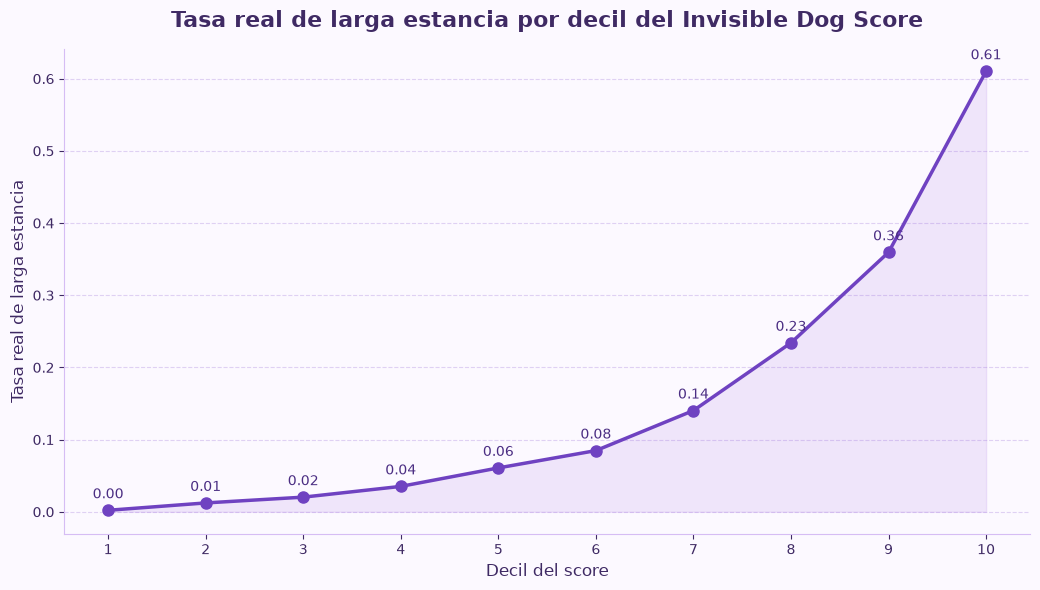

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\tasa_real_larga_estancia_por_decil_score_test.png


In [23]:
# Gráfico de tasa real de larga estancia por decil de score
# con el mismo estilo visual del resto del notebook

datos_plot = resumen_deciles_score.sort_values("decil_score").copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

# Fondo
fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

# Línea principal
ax.plot(
    datos_plot["decil_score"],
    datos_plot["tasa_real_larga_estancia"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#6F42C1"
)

# Área suave bajo la curva
ax.fill_between(
    datos_plot["decil_score"],
    datos_plot["tasa_real_larga_estancia"],
    alpha=0.18,
    color="#B68BE8"
)

# Etiquetas de valores
for x, y in zip(datos_plot["decil_score"], datos_plot["tasa_real_larga_estancia"]):
    ax.text(
        x,
        y + 0.012,
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#4B2E83"
    )

# Título y ejes
ax.set_title(
    "Tasa real de larga estancia por decil del Invisible Dog Score",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Decil del score", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa real de larga estancia", fontsize=12, color="#3F2A64")

# Ticks
ax.set_xticks(datos_plot["decil_score"])
ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

# Rejilla
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

# Bordes
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "tasa_real_larga_estancia_por_decil_score_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [24]:
# Guardado del análisis por deciles

deciles_score_path = interpretability_path / "deciles_invisible_dog_score_test.csv"

resumen_deciles_score.to_csv(
    deciles_score_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de deciles guardada en:")
print(deciles_score_path)

Tabla de deciles guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\deciles_invisible_dog_score_test.csv


### 2.3.1. Calibración por deciles del score

Además de ordenar correctamente a los perros por nivel de riesgo, resulta útil comprobar si las probabilidades medias estimadas por el modelo son coherentes con la tasa real observada en cada decil.

La calibración por deciles compara, para cada grupo de riesgo, la probabilidad media predicha con la proporción real de perros que tuvieron larga estancia.


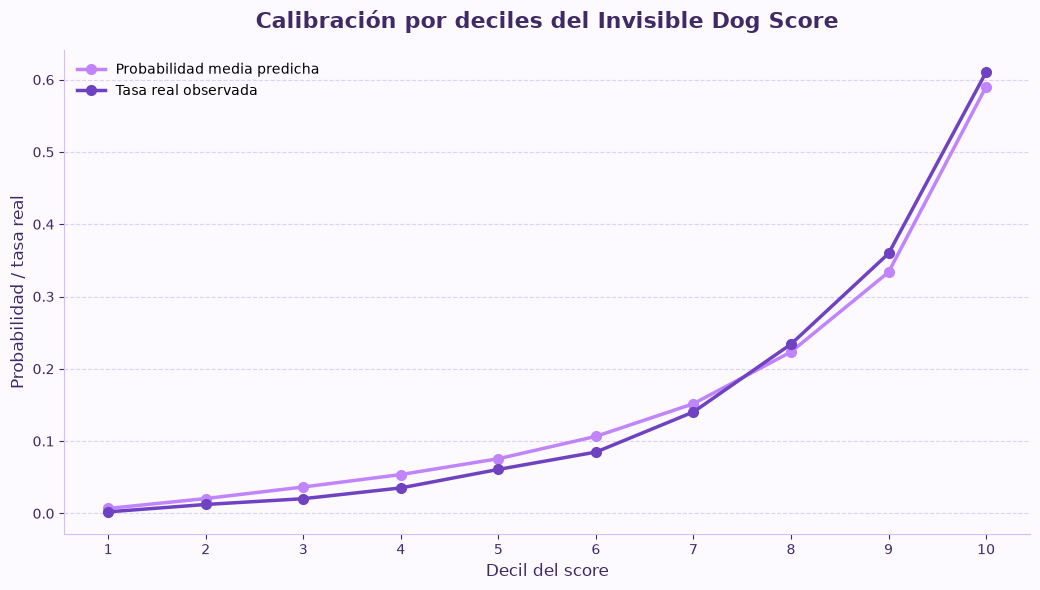

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\calibracion_deciles_invisible_dog_score_test.png


In [25]:
# Calibración por deciles: probabilidad media predicha vs tasa real observada

datos_plot = resumen_deciles_score.sort_values("decil_score").copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.plot(
    datos_plot["decil_score"],
    datos_plot["probabilidad_media"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#C084FC",
    label="Probabilidad media predicha"
)

ax.plot(
    datos_plot["decil_score"],
    datos_plot["tasa_real_larga_estancia"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#6F42C1",
    label="Tasa real observada"
)

ax.set_title(
    "Calibración por deciles del Invisible Dog Score",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Decil del score", fontsize=12, color="#3F2A64")
ax.set_ylabel("Probabilidad / tasa real", fontsize=12, color="#3F2A64")
ax.set_xticks(datos_plot["decil_score"])

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "calibracion_deciles_invisible_dog_score_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)


In [26]:
# Guardado de la tabla de calibración por deciles

calibracion_deciles_score = resumen_deciles_score[
    [
        "decil_score",
        "n_perros",
        "probabilidad_media",
        "tasa_real_larga_estancia",
        "casos_larga_estancia"
    ]
].copy()

calibracion_deciles_score["diferencia_observado_predicho"] = (
    calibracion_deciles_score["tasa_real_larga_estancia"]
    - calibracion_deciles_score["probabilidad_media"]
)

calibracion_deciles_score[
    [
        "probabilidad_media",
        "tasa_real_larga_estancia",
        "diferencia_observado_predicho"
    ]
] = calibracion_deciles_score[
    [
        "probabilidad_media",
        "tasa_real_larga_estancia",
        "diferencia_observado_predicho"
    ]
].round(4)

calibracion_deciles_path = interpretability_path / "calibracion_deciles_invisible_dog_score_test.csv"

calibracion_deciles_score.to_csv(
    calibracion_deciles_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de calibración por deciles guardada en:")
print(calibracion_deciles_path)

display(calibracion_deciles_score.sort_values("decil_score", ascending=False))


Tabla de calibración por deciles guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\calibracion_deciles_invisible_dog_score_test.csv


,decil_score,n_perros,probabilidad_media,tasa_real_larga_estancia,casos_larga_estancia,diferencia_observado_predicho
9,10,1876,0.5901,0.6103,1145,0.0202
8,9,1875,0.3337,0.3595,674,0.0258
7,8,1875,0.2234,0.2341,439,0.0107
6,7,1875,0.1517,0.1403,263,-0.0114
5,6,1875,0.1065,0.0848,159,-0.0217
4,5,1875,0.0756,0.0608,114,-0.0148
3,4,1875,0.0537,0.0352,66,-0.0185
2,3,1875,0.0365,0.0203,38,-0.0162
1,2,1875,0.0205,0.0123,23,-0.0082
0,1,1876,0.0068,0.0021,4,-0.0047


La comparación entre la probabilidad media predicha y la tasa real observada por decil permite evaluar la calibración del score. Aunque el objetivo principal del modelo es priorizar correctamente los casos de mayor riesgo, esta comparación ayuda a comprobar si las probabilidades estimadas son razonablemente coherentes con la frecuencia real de larga estancia observada en cada grupo.


### 2.4. Evaluación operativa mediante segmentos Top-K

Además del análisis por deciles, se evalúa el Invisible Dog Score como herramienta de priorización mediante segmentos Top-K.

Este enfoque permite responder a una pregunta operativa: si el refugio solo pudiera revisar un porcentaje limitado de perros, ¿cuántos casos reales de larga estancia detectaría al seleccionar aquellos con mayor score?

Se analizan los segmentos Top 1 %, Top 5 %, Top 10 %, Top 20 % y Top 30 %, calculando:

- Precision@Top-K: proporción de perros priorizados que realmente fueron de larga estancia.
- Recall@Top-K: proporción de todos los perros de larga estancia detectados dentro del segmento priorizado.
- Lift@Top-K: mejora respecto a una selección aleatoria.

In [27]:
# Evaluación operativa Top-K sobre el conjunto de test

dogs_score_test_ordenado = (
    dogs_score_test
    .sort_values("probabilidad_larga_estancia", ascending=False)
    .reset_index(drop=True)
)

segmentos_topk = [0.01, 0.05, 0.10, 0.20, 0.30]

total_perros_test = len(dogs_score_test_ordenado)
total_larga_estancia_test = dogs_score_test_ordenado["target_long_stay"].sum()
tasa_base_test = dogs_score_test_ordenado["target_long_stay"].mean()

resultados_topk = []

for porcentaje in segmentos_topk:
    n_priorizados = int(np.ceil(total_perros_test * porcentaje))
    topk = dogs_score_test_ordenado.head(n_priorizados)
    
    casos_detectados = topk["target_long_stay"].sum()
    precision_topk = casos_detectados / n_priorizados
    recall_topk = casos_detectados / total_larga_estancia_test
    lift_topk = precision_topk / tasa_base_test
    
    resultados_topk.append({
        "segmento_priorizado": f"Top {int(porcentaje * 100)}%",
        "porcentaje_priorizado": porcentaje,
        "n_perros_priorizados": n_priorizados,
        "casos_larga_estancia_detectados": int(casos_detectados),
        "precision_topk": precision_topk,
        "recall_topk": recall_topk,
        "lift_topk": lift_topk,
        "tasa_base_larga_estancia": tasa_base_test
    })

metricas_topk_score = pd.DataFrame(resultados_topk)

columnas_redondear_topk = [
    "porcentaje_priorizado",
    "precision_topk",
    "recall_topk",
    "lift_topk",
    "tasa_base_larga_estancia"
]

metricas_topk_score[columnas_redondear_topk] = (
    metricas_topk_score[columnas_redondear_topk].round(4)
)

print("Evaluación operativa Top-K del Invisible Dog Score sobre test:")
display(metricas_topk_score)

Evaluación operativa Top-K del Invisible Dog Score sobre test:


,segmento_priorizado,porcentaje_priorizado,n_perros_priorizados,casos_larga_estancia_detectados,precision_topk,recall_topk,lift_topk,tasa_base_larga_estancia
0,Top 1%,0.01,188,186,0.9894,0.0636,6.3427,0.156
1,Top 5%,0.05,938,674,0.7186,0.2304,4.6066,0.156
2,Top 10%,0.10,1876,1145,0.6103,0.3915,3.9129,0.156
3,Top 20%,0.20,3751,1819,0.4849,0.6219,3.1089,0.156
4,Top 30%,0.30,5626,2258,0.4014,0.7720,2.5730,0.156


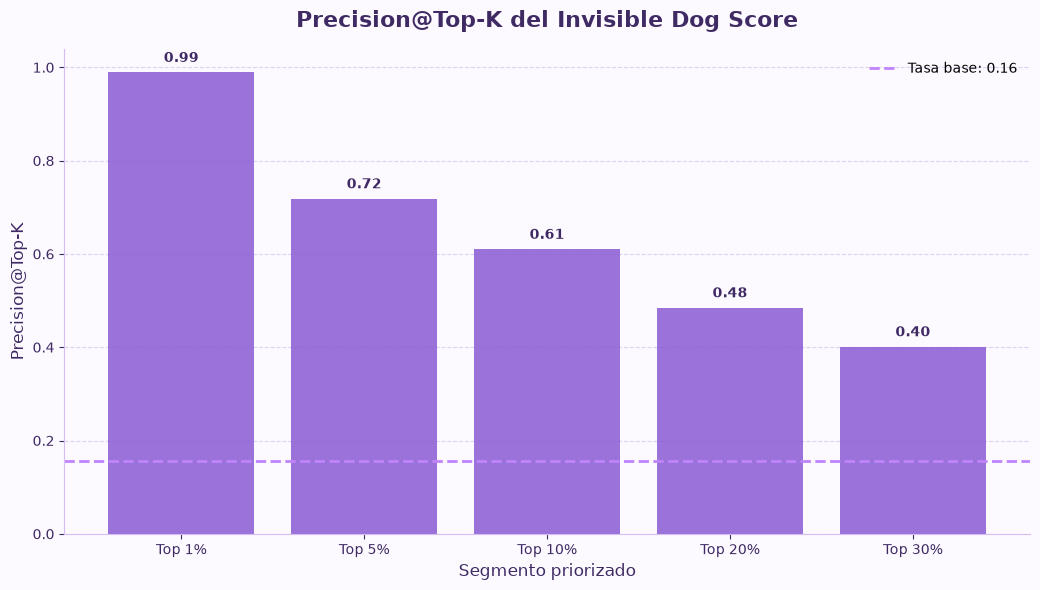

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\precision_topk_invisible_dog_score_test.png


In [28]:
# Gráfico Precision@Top-K del Invisible Dog Score

datos_plot = metricas_topk_score.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["segmento_priorizado"],
    datos_plot["precision_topk"],
    color="#8A5BD3",
    alpha=0.85
)

ax.axhline(
    tasa_base_test,
    linestyle="--",
    linewidth=2,
    color="#C084FC",
    label=f"Tasa base: {tasa_base_test:.2f}"
)

for i, valor in enumerate(datos_plot["precision_topk"]):
    ax.text(
        i,
        valor + 0.015,
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Precision@Top-K del Invisible Dog Score",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Segmento priorizado", fontsize=12, color="#3F2A64")
ax.set_ylabel("Precision@Top-K", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "precision_topk_invisible_dog_score_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

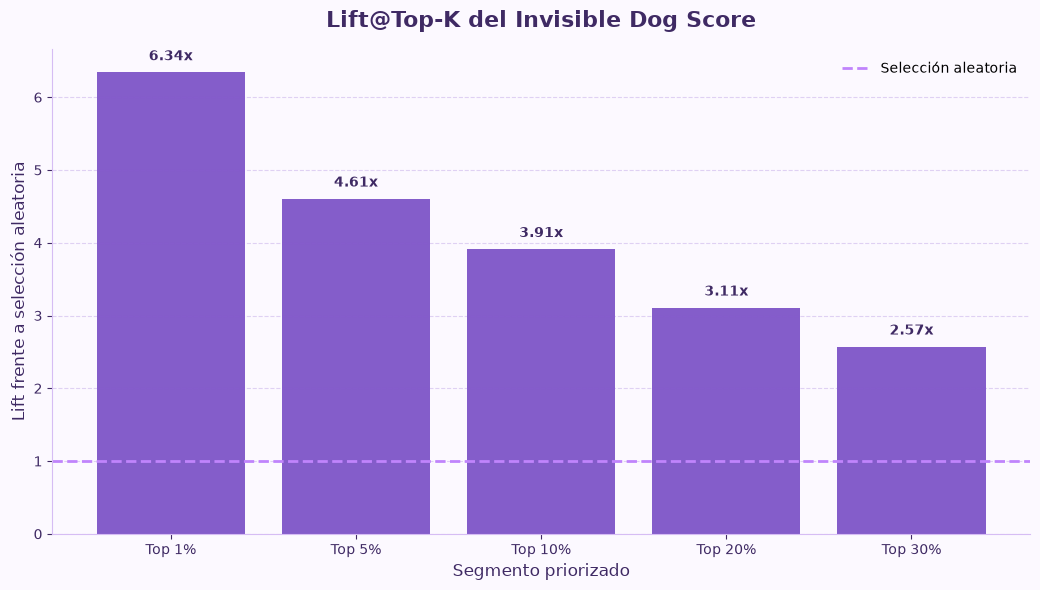

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\lift_topk_invisible_dog_score_test.png


In [29]:
# Gráfico Lift@Top-K del Invisible Dog Score

datos_plot = metricas_topk_score.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["segmento_priorizado"],
    datos_plot["lift_topk"],
    color="#6F42C1",
    alpha=0.85
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=2,
    color="#C084FC",
    label="Selección aleatoria"
)

for i, valor in enumerate(datos_plot["lift_topk"]):
    ax.text(
        i,
        valor + 0.12,
        f"{valor:.2f}x",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Lift@Top-K del Invisible Dog Score",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Segmento priorizado", fontsize=12, color="#3F2A64")
ax.set_ylabel("Lift frente a selección aleatoria", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "lift_topk_invisible_dog_score_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [30]:
# Guardado del análisis Top-K

topk_score_path = interpretability_path / "metricas_topk_invisible_dog_score_test.csv"

metricas_topk_score.to_csv(
    topk_score_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla Top-K guardada en:")
print(topk_score_path)

Tabla Top-K guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\metricas_topk_invisible_dog_score_test.csv


### 2.5. Curva de ganancia acumulada

La curva de ganancia acumulada permite analizar qué proporción de los casos reales de larga estancia se detecta al revisar progresivamente los perros con mayor Invisible Dog Score.

Este análisis complementa la evaluación Top-K, ya que muestra la cobertura acumulada del modelo a medida que aumenta el porcentaje de perros priorizados.


In [31]:
# Curva de ganancia acumulada del Invisible Dog Score sobre test

dogs_score_test_ordenado = (
    dogs_score_test
    .sort_values("probabilidad_larga_estancia", ascending=False)
    .reset_index(drop=True)
)

dogs_score_test_ordenado["ranking"] = np.arange(1, len(dogs_score_test_ordenado) + 1)

dogs_score_test_ordenado["porcentaje_poblacion_acumulado"] = (
    dogs_score_test_ordenado["ranking"] / len(dogs_score_test_ordenado)
)

dogs_score_test_ordenado["casos_larga_estancia_acumulados"] = (
    dogs_score_test_ordenado["target_long_stay"].cumsum()
)

total_casos_larga_estancia_test = dogs_score_test_ordenado["target_long_stay"].sum()

dogs_score_test_ordenado["porcentaje_casos_detectados_acumulado"] = (
    dogs_score_test_ordenado["casos_larga_estancia_acumulados"]
    / total_casos_larga_estancia_test
)

puntos_ganancia = np.arange(0.05, 1.01, 0.05)

resultados_ganancia = []

for punto in puntos_ganancia:
    n_priorizados = int(np.ceil(len(dogs_score_test_ordenado) * punto))
    fila = dogs_score_test_ordenado.iloc[n_priorizados - 1]
    
    resultados_ganancia.append({
        "porcentaje_perros_revisados": punto,
        "n_perros_revisados": n_priorizados,
        "casos_larga_estancia_detectados": int(fila["casos_larga_estancia_acumulados"]),
        "porcentaje_casos_detectados": fila["porcentaje_casos_detectados_acumulado"],
        "ganancia_aleatoria_esperada": punto
    })

ganancia_acumulada_score = pd.DataFrame(resultados_ganancia)

ganancia_acumulada_score[
    [
        "porcentaje_perros_revisados",
        "porcentaje_casos_detectados",
        "ganancia_aleatoria_esperada"
    ]
] = ganancia_acumulada_score[
    [
        "porcentaje_perros_revisados",
        "porcentaje_casos_detectados",
        "ganancia_aleatoria_esperada"
    ]
].round(4)

print("Ganancia acumulada del Invisible Dog Score sobre test:")
display(ganancia_acumulada_score)

Ganancia acumulada del Invisible Dog Score sobre test:


,porcentaje_perros_revisados,n_perros_revisados,casos_larga_estancia_detectados,porcentaje_casos_detectados,ganancia_aleatoria_esperada
0,0.05,938,674,0.2304,0.05
1,0.10,1876,1145,0.3915,0.10
2,0.15,2813,1508,0.5156,0.15
3,0.20,3751,1819,0.6219,0.20
4,0.25,4688,2062,0.7050,0.25
5,0.30,5626,2258,0.7720,0.30
6,0.35,6564,2396,0.8191,0.35
7,0.40,7501,2521,0.8619,0.40
8,0.45,8439,2611,0.8926,0.45
9,0.50,9376,2680,0.9162,0.50


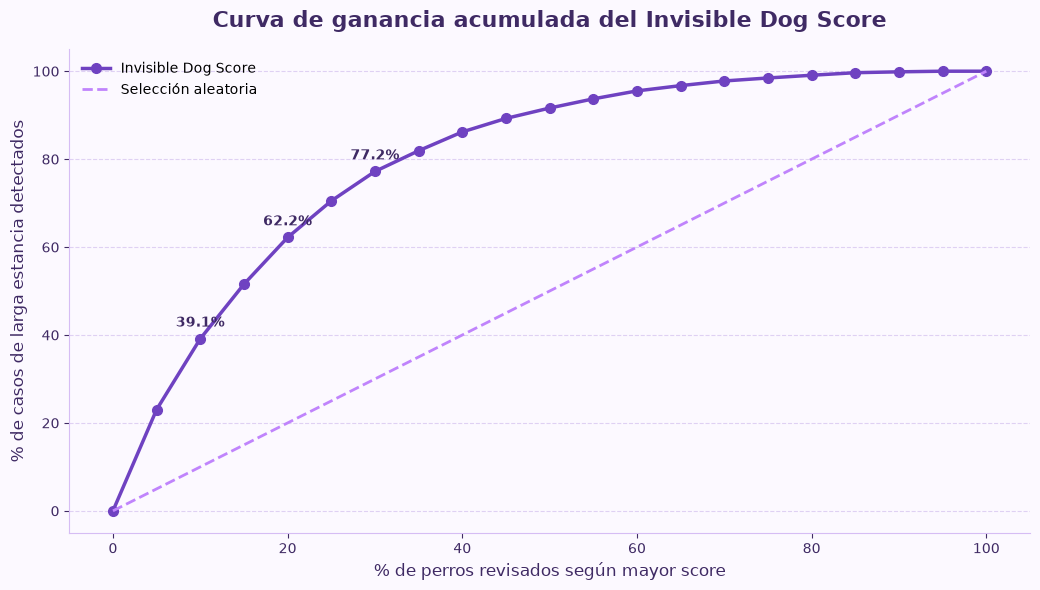

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\curva_ganancia_acumulada_invisible_dog_score_test.png


In [32]:
# Gráfico de curva de ganancia acumulada

datos_plot = ganancia_acumulada_score.copy()

# Se añade el punto inicial 0%-0% para que la curva empiece en el origen
punto_inicial = pd.DataFrame([{
    "porcentaje_perros_revisados": 0.0,
    "n_perros_revisados": 0,
    "casos_larga_estancia_detectados": 0,
    "porcentaje_casos_detectados": 0.0,
    "ganancia_aleatoria_esperada": 0.0
}])

datos_plot_grafico = pd.concat(
    [punto_inicial, datos_plot],
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.plot(
    datos_plot_grafico["porcentaje_perros_revisados"] * 100,
    datos_plot_grafico["porcentaje_casos_detectados"] * 100,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#6F42C1",
    label="Invisible Dog Score"
)

ax.plot(
    datos_plot_grafico["porcentaje_perros_revisados"] * 100,
    datos_plot_grafico["ganancia_aleatoria_esperada"] * 100,
    linestyle="--",
    linewidth=2,
    color="#C084FC",
    label="Selección aleatoria"
)

for _, fila in datos_plot[
    datos_plot["porcentaje_perros_revisados"].isin([0.10, 0.20, 0.30])
].iterrows():
    ax.text(
        fila["porcentaje_perros_revisados"] * 100,
        fila["porcentaje_casos_detectados"] * 100 + 2,
        f"{fila['porcentaje_casos_detectados'] * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Curva de ganancia acumulada del Invisible Dog Score",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("% de perros revisados según mayor score", fontsize=12, color="#3F2A64")
ax.set_ylabel("% de casos de larga estancia detectados", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "curva_ganancia_acumulada_invisible_dog_score_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

La curva de ganancia acumulada muestra que el Invisible Dog Score concentra una proporción elevada de los casos reales de larga estancia en los primeros segmentos del ranking.

En concreto, al revisar el 10 % de perros con mayor score se detecta el 39,15 % de todos los casos reales de larga estancia. Al ampliar la revisión al 20 %, se detecta el 62,19 %, y al 30 %, el 77,20 %.

Estos resultados muestran que el score tiene una utilidad operativa clara, ya que permite priorizar la revisión de un subconjunto reducido de perros y capturar una proporción elevada de los casos que finalmente presentan larga estancia.

In [33]:
# Guardado de la curva de ganancia acumulada

ganancia_acumulada_path = interpretability_path / "ganancia_acumulada_invisible_dog_score_test.csv"

ganancia_acumulada_score.to_csv(
    ganancia_acumulada_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de ganancia acumulada guardada en:")
print(ganancia_acumulada_path)

Tabla de ganancia acumulada guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\ganancia_acumulada_invisible_dog_score_test.csv


### 2.6. Distribución visual del Invisible Dog Score y bandas de riesgo

Una vez definido el Invisible Dog Score, se analiza su distribución sobre el conjunto de prueba. Este análisis permite comprobar cómo se reparte el riesgo estimado entre los perros y si las bandas definidas son coherentes con la tasa real de larga estancia.

Se incluyen tres análisis visuales:

- distribución general del score;
- número de perros por banda de riesgo;
- tasa real de larga estancia por banda de riesgo.

Estos gráficos ayudan a interpretar el score de forma más intuitiva y permiten comprobar si las bandas propuestas separan adecuadamente los distintos niveles de riesgo.

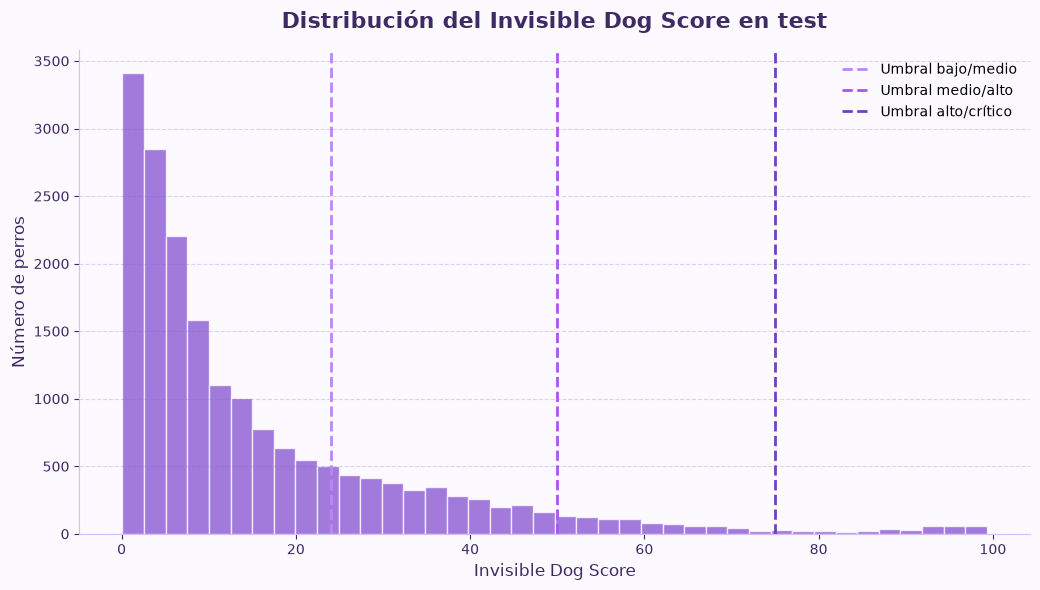

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\distribucion_invisible_dog_score_test.png


In [34]:
# Distribución del Invisible Dog Score sobre el conjunto de test

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.hist(
    dogs_score_test["invisible_dog_score"],
    bins=40,
    color="#8A5BD3",
    alpha=0.80,
    edgecolor="#FCF9FF"
)

ax.axvline(
    24,
    linestyle="--",
    linewidth=2,
    color="#C084FC",
    label="Umbral bajo/medio"
)

ax.axvline(
    50,
    linestyle="--",
    linewidth=2,
    color="#A855F7",
    label="Umbral medio/alto"
)

ax.axvline(
    75,
    linestyle="--",
    linewidth=2,
    color="#6F42C1",
    label="Umbral alto/crítico"
)

ax.set_title(
    "Distribución del Invisible Dog Score en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Invisible Dog Score", fontsize=12, color="#3F2A64")
ax.set_ylabel("Número de perros", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "distribucion_invisible_dog_score_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

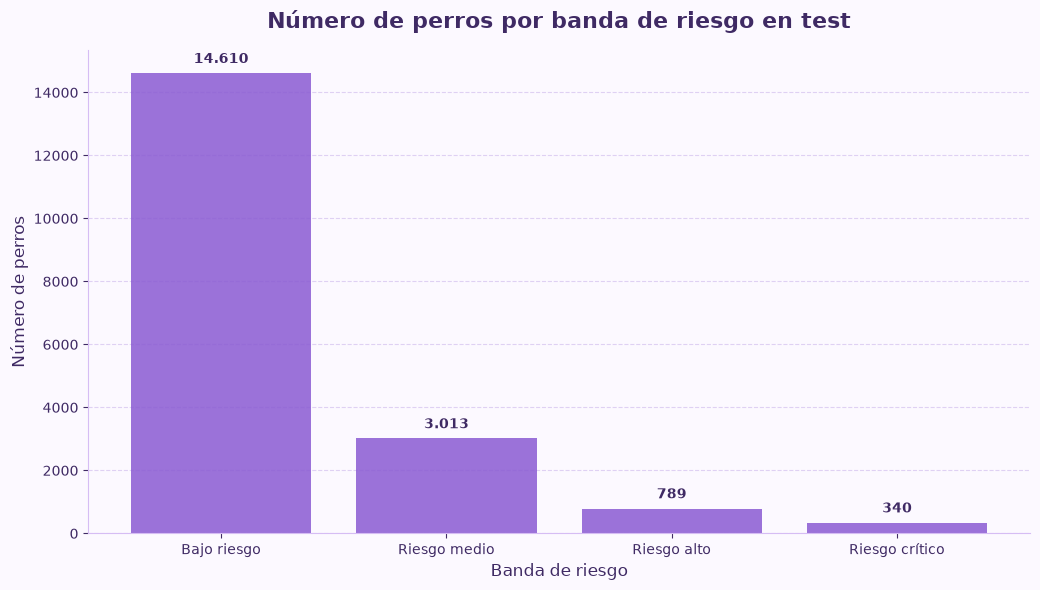

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\numero_perros_por_banda_riesgo_test.png


In [35]:
# Número de perros por banda de riesgo en test

datos_plot = resumen_bandas_riesgo_test.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["banda_riesgo"].astype(str),
    datos_plot["n_perros"],
    color="#8A5BD3",
    alpha=0.85
)

for i, fila in datos_plot.iterrows():
    ax.text(
        i,
        fila["n_perros"] + max(datos_plot["n_perros"]) * 0.015,
        f"{int(fila['n_perros']):,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Número de perros por banda de riesgo en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Banda de riesgo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Número de perros", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64", rotation=0)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "numero_perros_por_banda_riesgo_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

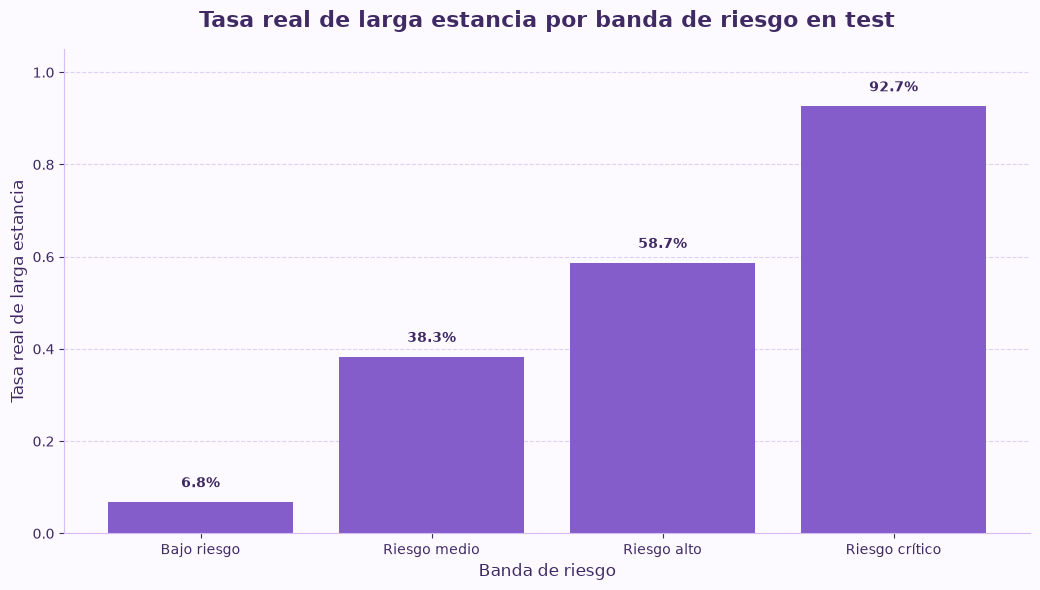

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\tasa_real_larga_estancia_por_banda_riesgo_test.png


In [36]:
# Tasa real de larga estancia por banda de riesgo en test

datos_plot = resumen_bandas_riesgo_test.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["banda_riesgo"].astype(str),
    datos_plot["tasa_real_larga_estancia"],
    color="#6F42C1",
    alpha=0.85
)

for i, fila in datos_plot.iterrows():
    valor = fila["tasa_real_larga_estancia"]
    ax.text(
        i,
        valor + 0.025,
        f"{valor * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Tasa real de larga estancia por banda de riesgo en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Banda de riesgo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Tasa real de larga estancia", fontsize=12, color="#3F2A64")

ax.set_ylim(0, 1.05)

ax.tick_params(axis="x", colors="#3F2A64", rotation=0)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "tasa_real_larga_estancia_por_banda_riesgo_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

La distribución del Invisible Dog Score muestra que la mayoría de los perros se concentra en valores bajos de riesgo, mientras que un subconjunto más reducido alcanza puntuaciones elevadas.

El análisis por bandas confirma que las categorías propuestas separan adecuadamente los niveles de riesgo. En el conjunto de prueba, la tasa real de larga estancia aumenta de forma progresiva desde la banda de bajo riesgo hasta la banda de riesgo crítico.

En concreto, la banda de bajo riesgo presenta una tasa real de larga estancia reducida, mientras que la banda de riesgo crítico concentra una proporción muy elevada de perros que finalmente tuvieron larga estancia. Esto refuerza la utilidad del score como herramienta de priorización operativa.

### 2.7. Comparación del score según el resultado real

Para completar la evaluación del Invisible Dog Score, se compara la distribución del score entre los perros que realmente tuvieron larga estancia y aquellos que no.

Este análisis permite comprobar si el modelo asigna, en promedio, puntuaciones más elevadas a los perros que finalmente permanecieron más de 30 días en el refugio.

In [37]:
# Resumen del Invisible Dog Score según resultado real en test

resumen_score_por_resultado = (
    dogs_score_test
    .groupby("resultado_real")
    .agg(
        n_perros=("animal_id", "count"),
        score_medio=("invisible_dog_score", "mean"),
        score_mediano=("invisible_dog_score", "median"),
        score_minimo=("invisible_dog_score", "min"),
        score_maximo=("invisible_dog_score", "max"),
        percentil_25=("invisible_dog_score", lambda x: np.percentile(x, 25)),
        percentil_75=("invisible_dog_score", lambda x: np.percentile(x, 75))
    )
    .reset_index()
)

columnas_redondear = [
    "score_medio",
    "score_mediano",
    "score_minimo",
    "score_maximo",
    "percentil_25",
    "percentil_75"
]

resumen_score_por_resultado[columnas_redondear] = (
    resumen_score_por_resultado[columnas_redondear].round(2)
)

print("Resumen del Invisible Dog Score según resultado real:")
display(resumen_score_por_resultado)

Resumen del Invisible Dog Score según resultado real:


,resultado_real,n_perros,score_medio,score_mediano,score_minimo,score_maximo,percentil_25,percentil_75
0,Larga estancia,2925,38.43,34.2,0.8,99.3,19.5,51.8
1,No larga estancia,15827,11.84,7.0,0.1,97.1,3.0,15.7


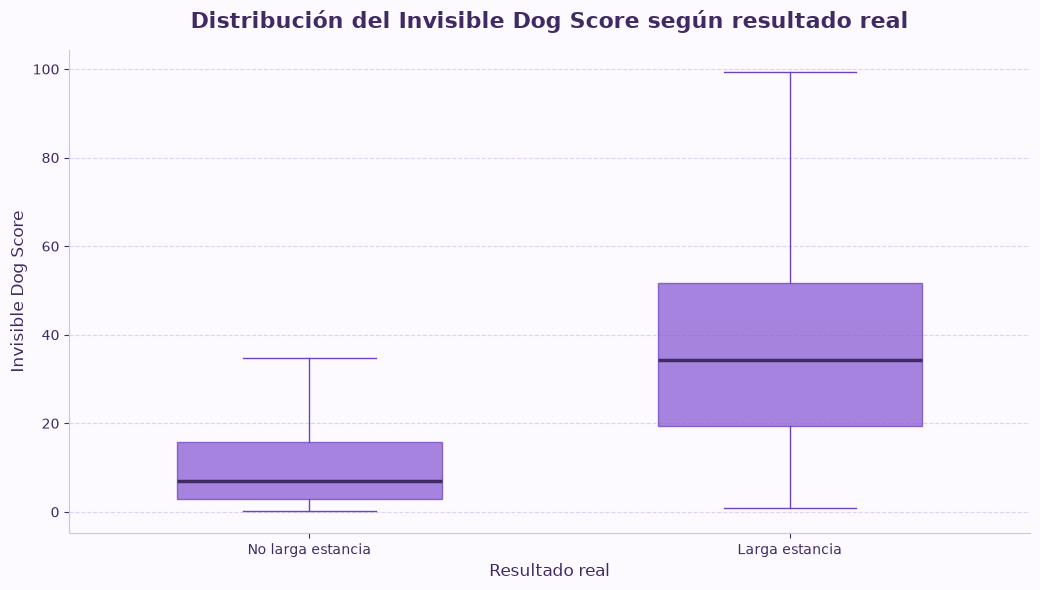

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\score_por_resultado_real_test.png


In [38]:
# Boxplot del Invisible Dog Score según resultado real

datos_no_larga = dogs_score_test.loc[
    dogs_score_test["target_long_stay"] == 0,
    "invisible_dog_score"
]

datos_larga = dogs_score_test.loc[
    dogs_score_test["target_long_stay"] == 1,
    "invisible_dog_score"
]

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

box = ax.boxplot(
    [datos_no_larga, datos_larga],
    tick_labels=["No larga estancia", "Larga estancia"],
    patch_artist=True,
    widths=0.55,
    showfliers=False
)

for patch in box["boxes"]:
    patch.set_facecolor("#8A5BD3")
    patch.set_alpha(0.75)
    patch.set_edgecolor("#6F42C1")

for median in box["medians"]:
    median.set_color("#3F2A64")
    median.set_linewidth(2.5)

for whisker in box["whiskers"]:
    whisker.set_color("#6F42C1")

for cap in box["caps"]:
    cap.set_color("#6F42C1")

ax.set_title(
    "Distribución del Invisible Dog Score según resultado real",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Resultado real", fontsize=12, color="#3F2A64")
ax.set_ylabel("Invisible Dog Score", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "score_por_resultado_real_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

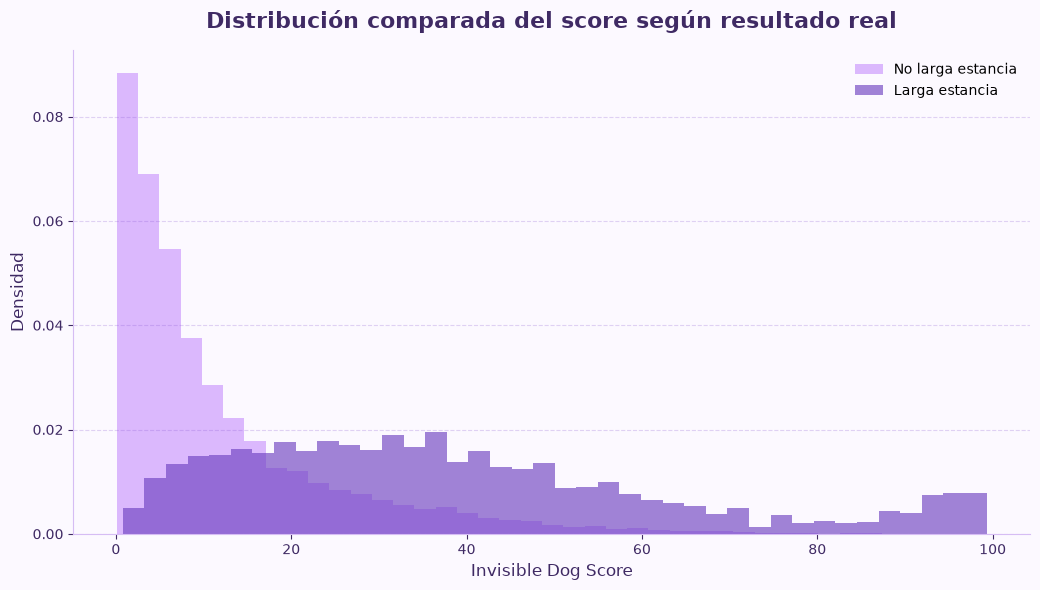

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\distribucion_score_por_resultado_real_test.png


In [39]:
# Distribución comparada del Invisible Dog Score por resultado real

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.hist(
    datos_no_larga,
    bins=40,
    alpha=0.55,
    color="#C084FC",
    label="No larga estancia",
    density=True
)

ax.hist(
    datos_larga,
    bins=40,
    alpha=0.65,
    color="#6F42C1",
    label="Larga estancia",
    density=True
)

ax.set_title(
    "Distribución comparada del score según resultado real",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Invisible Dog Score", fontsize=12, color="#3F2A64")
ax.set_ylabel("Densidad", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

ax.legend(frameon=False)

fig.tight_layout()

fig_path = figures_path / "distribucion_score_por_resultado_real_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

El análisis comparativo muestra que los perros que realmente tuvieron larga estancia presentan, en general, valores superiores del Invisible Dog Score frente a los perros que no superaron el umbral de 30 días.

Esta separación visual refuerza la capacidad discriminativa del score y complementa los resultados obtenidos mediante métricas como ROC-AUC, Average Precision, deciles y Top-K.

Aunque existe cierto solapamiento entre ambos grupos, algo esperable en un problema real y desbalanceado, el desplazamiento de la distribución de los perros de larga estancia hacia valores más altos confirma que el score captura información relevante para la priorización.

### 2.8. Análisis de aciertos y errores del modelo

Una vez calculado el Invisible Dog Score y aplicada la regla de decisión, se analiza el tipo de resultado obtenido por el modelo en el conjunto de prueba.

Se distinguen cuatro grupos:

- **Verdaderos negativos**: perros que no fueron priorizados y realmente no tuvieron larga estancia.
- **Verdaderos positivos**: perros priorizados por el modelo que realmente tuvieron larga estancia.
- **Falsos positivos**: perros priorizados por el modelo que finalmente no tuvieron larga estancia.
- **Falsos negativos**: perros que no fueron priorizados por el modelo pero que realmente tuvieron larga estancia.

Este análisis permite entender no solo cuántos casos acierta el modelo, sino también qué tipo de errores comete.

In [40]:
# Clasificación de aciertos y errores del modelo en test

dogs_score_test = dogs_score_test.copy()

condiciones_resultado = [
    (dogs_score_test["target_long_stay"] == 0) & (dogs_score_test["prediccion_larga_estancia"] == 0),
    (dogs_score_test["target_long_stay"] == 0) & (dogs_score_test["prediccion_larga_estancia"] == 1),
    (dogs_score_test["target_long_stay"] == 1) & (dogs_score_test["prediccion_larga_estancia"] == 0),
    (dogs_score_test["target_long_stay"] == 1) & (dogs_score_test["prediccion_larga_estancia"] == 1)
]

etiquetas_resultado = [
    "Verdadero negativo",
    "Falso positivo",
    "Falso negativo",
    "Verdadero positivo"
]

dogs_score_test["tipo_resultado_modelo"] = np.select(
    condiciones_resultado,
    etiquetas_resultado,
    default="Sin clasificar"
)

orden_tipos_resultado = [
    "Verdadero negativo",
    "Falso positivo",
    "Falso negativo",
    "Verdadero positivo"
]

dogs_score_test["tipo_resultado_modelo"] = pd.Categorical(
    dogs_score_test["tipo_resultado_modelo"],
    categories=orden_tipos_resultado,
    ordered=True
)

print("Variable tipo_resultado_modelo creada correctamente.")

display(
    dogs_score_test[
        [
            "animal_id",
            "target_long_stay",
            "prediccion_larga_estancia",
            "invisible_dog_score",
            "banda_riesgo",
            "tipo_resultado_modelo"
        ]
    ].head(10)
)

Variable tipo_resultado_modelo creada correctamente.


,animal_id,target_long_stay,prediccion_larga_estancia,invisible_dog_score,banda_riesgo,tipo_resultado_modelo
37,A271790,0,0,4.9,Bajo riesgo,Verdadero negativo
41,A280390,0,0,2.9,Bajo riesgo,Verdadero negativo
80,A329257,0,0,2.1,Bajo riesgo,Verdadero negativo
94,A337187,0,0,14.2,Bajo riesgo,Verdadero negativo
103,A339103,0,0,12.8,Bajo riesgo,Verdadero negativo
106,A342473,0,0,5.0,Bajo riesgo,Verdadero negativo
116,A348272,0,0,13.2,Bajo riesgo,Verdadero negativo
119,A349480,0,0,5.4,Bajo riesgo,Verdadero negativo
120,A349733,0,0,4.7,Bajo riesgo,Verdadero negativo
124,A354725,0,0,10.3,Bajo riesgo,Verdadero negativo


In [41]:
# Resumen de aciertos y errores

resumen_aciertos_errores = (
    dogs_score_test
    .groupby("tipo_resultado_modelo", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        porcentaje_test=("animal_id", lambda x: len(x) / len(dogs_score_test) * 100),
        score_medio=("invisible_dog_score", "mean"),
        score_mediano=("invisible_dog_score", "median"),
        estancia_media_dias=("stay_days_rounded", "mean"),
        estancia_mediana_dias=("stay_days_rounded", "median")
    )
    .reset_index()
)

resumen_aciertos_errores[
    [
        "porcentaje_test",
        "score_medio",
        "score_mediano",
        "estancia_media_dias",
        "estancia_mediana_dias"
    ]
] = resumen_aciertos_errores[
    [
        "porcentaje_test",
        "score_medio",
        "score_mediano",
        "estancia_media_dias",
        "estancia_mediana_dias"
    ]
].round(2)

print("Resumen de aciertos y errores del modelo:")
display(resumen_aciertos_errores)

Resumen de aciertos y errores del modelo:


,tipo_resultado_modelo,n_perros,porcentaje_test,score_medio,score_mediano,estancia_media_dias,estancia_mediana_dias
0,Verdadero negativo,13479,71.88,7.33,5.60,6.64,5.0
1,Falso positivo,2348,12.52,37.74,34.80,10.60,9.0
2,Falso negativo,949,5.06,13.84,14.00,91.40,54.0
3,Verdadero positivo,1976,10.54,50.24,44.15,103.91,66.0


In [42]:
# Matriz de confusión del modelo final en test

matriz_confusion = confusion_matrix(
    dogs_score_test["target_long_stay"],
    dogs_score_test["prediccion_larga_estancia"]
)

tn, fp, fn, tp = matriz_confusion.ravel()

matriz_confusion_df = pd.DataFrame(
    matriz_confusion,
    index=["Real: no larga estancia", "Real: larga estancia"],
    columns=["Predicción: no riesgo", "Predicción: riesgo"]
)

print("Matriz de confusión:")
display(matriz_confusion_df)

print("Detalle:")
print("Verdaderos negativos:", tn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", tp)

Matriz de confusión:


,Predicción: no riesgo,Predicción: riesgo
Real: no larga estancia,13479,2348
Real: larga estancia,949,1976


Detalle:
Verdaderos negativos: 13479
Falsos positivos: 2348
Falsos negativos: 949
Verdaderos positivos: 1976


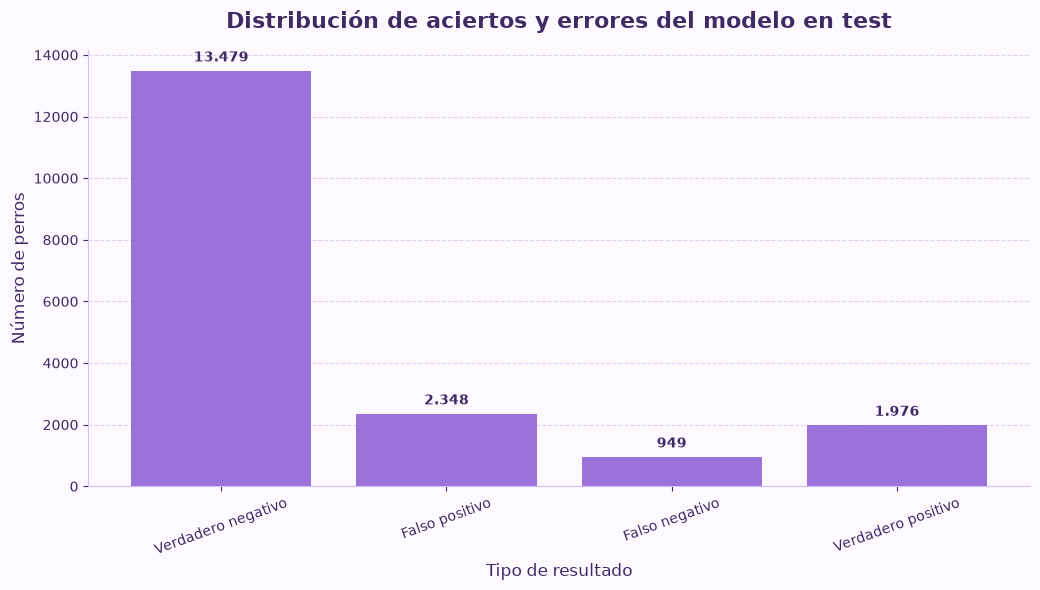

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\distribucion_aciertos_errores_modelo_test.png


In [43]:
# Gráfico de distribución de aciertos y errores

datos_plot = resumen_aciertos_errores.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["tipo_resultado_modelo"].astype(str),
    datos_plot["n_perros"],
    color="#8A5BD3",
    alpha=0.85
)

for i, fila in datos_plot.iterrows():
    ax.text(
        i,
        fila["n_perros"] + max(datos_plot["n_perros"]) * 0.015,
        f"{int(fila['n_perros']):,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Distribución de aciertos y errores del modelo en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Tipo de resultado", fontsize=12, color="#3F2A64")
ax.set_ylabel("Número de perros", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64", rotation=20)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "distribucion_aciertos_errores_modelo_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

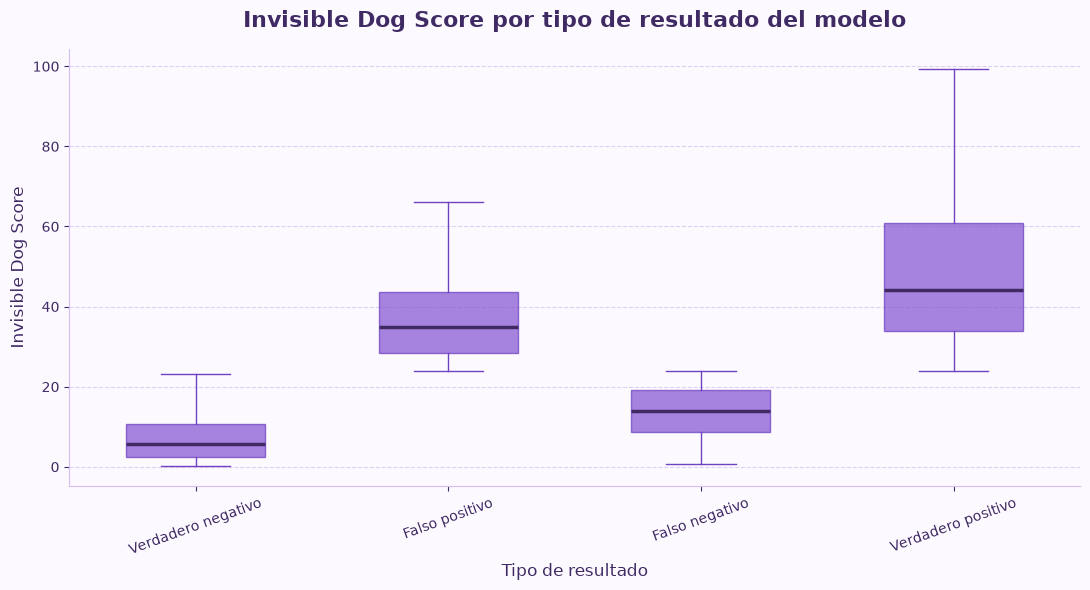

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\score_por_tipo_resultado_modelo_test.png


In [44]:
# Boxplot del Invisible Dog Score por tipo de resultado del modelo

datos_boxplot = [
    dogs_score_test.loc[
        dogs_score_test["tipo_resultado_modelo"] == tipo,
        "invisible_dog_score"
    ]
    for tipo in orden_tipos_resultado
]

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

box = ax.boxplot(
    datos_boxplot,
    tick_labels=orden_tipos_resultado,
    patch_artist=True,
    widths=0.55,
    showfliers=False
)

for patch in box["boxes"]:
    patch.set_facecolor("#8A5BD3")
    patch.set_alpha(0.75)
    patch.set_edgecolor("#6F42C1")

for median in box["medians"]:
    median.set_color("#3F2A64")
    median.set_linewidth(2.5)

for whisker in box["whiskers"]:
    whisker.set_color("#6F42C1")

for cap in box["caps"]:
    cap.set_color("#6F42C1")

ax.set_title(
    "Invisible Dog Score por tipo de resultado del modelo",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Tipo de resultado", fontsize=12, color="#3F2A64")
ax.set_ylabel("Invisible Dog Score", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64", rotation=20)
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "score_por_tipo_resultado_modelo_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [45]:
# Guardado del análisis de aciertos y errores

aciertos_errores_path = interpretability_path / "analisis_aciertos_errores_test.csv"
dogs_score_test_actualizado_path = interpretability_path / "invisible_dogs_scores_test.csv"

resumen_aciertos_errores.to_csv(
    aciertos_errores_path,
    index=False,
    encoding="utf-8-sig"
)

dogs_score_test.to_csv(
    dogs_score_test_actualizado_path,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de aciertos y errores guardado en:")
print(aciertos_errores_path)

print("\nScores de test actualizados guardados en:")
print(dogs_score_test_actualizado_path)

Resumen de aciertos y errores guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\analisis_aciertos_errores_test.csv

Scores de test actualizados guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\invisible_dogs_scores_test.csv


El análisis de aciertos y errores permite interpretar el comportamiento del modelo más allá de las métricas agregadas.

Los verdaderos positivos representan perros que fueron priorizados por el modelo y que efectivamente tuvieron larga estancia. Estos casos reflejan la utilidad directa del Invisible Dog Score como herramienta de detección temprana.

Los falsos positivos corresponden a perros que el modelo priorizó pero que finalmente no tuvieron larga estancia. En este caso de uso, este tipo de error puede ser relativamente asumible, ya que una mayor visibilidad o seguimiento adicional no supone necesariamente una consecuencia negativa para el animal.

Los falsos negativos son especialmente relevantes, ya que representan perros que sí tuvieron larga estancia pero no fueron priorizados inicialmente. Su análisis posterior puede ayudar a identificar perfiles difíciles de detectar o casos en los que la información disponible en el momento de entrada no era suficiente para anticipar la estancia prolongada.

### 2.9. Análisis específico de falsos positivos y falsos negativos

El análisis de falsos positivos y falsos negativos permite profundizar en los principales tipos de error del modelo.

Los **falsos positivos** son perros que el modelo priorizó como riesgo de larga estancia, pero que finalmente no superaron los 30 días. En este caso de uso, este error puede ser asumible, ya que una mayor visibilidad o seguimiento no supone necesariamente una consecuencia negativa.

Los **falsos negativos**, en cambio, son especialmente relevantes: corresponden a perros que realmente tuvieron larga estancia, pero que no fueron priorizados por el modelo. Estos casos permiten identificar perfiles difíciles de anticipar con la información disponible en el momento de entrada.

In [46]:
# Subconjuntos de falsos positivos y falsos negativos

falsos_positivos = dogs_score_test.loc[
    dogs_score_test["tipo_resultado_modelo"] == "Falso positivo"
].copy()

falsos_negativos = dogs_score_test.loc[
    dogs_score_test["tipo_resultado_modelo"] == "Falso negativo"
].copy()

verdaderos_positivos = dogs_score_test.loc[
    dogs_score_test["tipo_resultado_modelo"] == "Verdadero positivo"
].copy()

verdaderos_negativos = dogs_score_test.loc[
    dogs_score_test["tipo_resultado_modelo"] == "Verdadero negativo"
].copy()

print("Falsos positivos:", len(falsos_positivos))
print("Falsos negativos:", len(falsos_negativos))
print("Verdaderos positivos:", len(verdaderos_positivos))
print("Verdaderos negativos:", len(verdaderos_negativos))

Falsos positivos: 2348
Falsos negativos: 949
Verdaderos positivos: 1976
Verdaderos negativos: 13479


In [47]:
# Resumen comparativo por tipo de resultado del modelo

variables_resumen_error = [
    "invisible_dog_score",
    "stay_days_rounded",
    "age_months_intake",
    "previous_intake_count",
    "previous_stay_days",
    "previous_long_stay_count",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

variables_resumen_error = [
    col for col in variables_resumen_error
    if col in dogs_score_test.columns
]

resumen_comparativo_errores = (
    dogs_score_test
    .groupby("tipo_resultado_modelo", observed=False)[variables_resumen_error]
    .agg(["mean", "median"])
)

resumen_comparativo_errores = resumen_comparativo_errores.round(2)

print("Resumen comparativo de variables numéricas por tipo de resultado:")
display(resumen_comparativo_errores)

Resumen comparativo de variables numéricas por tipo de resultado:


invisible_dog_score        stay_days_rounded        age_months_intake        previous_intake_count        previous_stay_days         \
                                     mean median              mean median              mean median                  mean median               mean median   
tipo_resultado_modelo                                                                                                                                       
Verdadero negativo                   7.33   5.60              6.64    5.0             29.42   12.0                  0.19    0.0               8.51    5.0   
Falso positivo                      37.74  34.80             10.60    9.0             33.00   24.0                  0.29    0.0              43.79   20.0   
Falso negativo                      13.84  14.00             91.40   54.0             34.51   24.0                  0.26    0.0              13.89    7.0   
Verdadero positivo                  50.24  44.15            103.91   66.0             27.91   24.0                  0.26    0.0              53.95   29.0   

                      previous_long_stay_count        estimated_active_dogs_at_intake        ratio_intakes_outcomes_30d         
                                          mean median                            mean median                       mean median  
tipo_resultado_modelo                                                                                                           
Verdadero negativo                        0.01    0.0                          468.68  463.0                       1.02   1.00  
Falso positivo                            0.10    0.0                          484.40  482.0                       1.02   1.01  
Falso negativo                            0.03    0.0                          475.68  470.0                       1.01   1.00  
Verdadero positivo                        0.11    0.0                          489.26  485.0                       1.02   1.01

In [48]:
# Falsos negativos más relevantes: larga estancia real no priorizada

columnas_casos_error = [
    "animal_id",
    "invisible_dog_score",
    "probabilidad_larga_estancia",
    "banda_riesgo",
    "stay_days_rounded",
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_months_intake",
    "age_group",
    "breed_intake",
    "color_intake",
    "found_location",
    "previous_intake_count",
    "previous_stay_days",
    "previous_long_stay_count",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

columnas_casos_error = [
    col for col in columnas_casos_error
    if col in dogs_score_test.columns
]

falsos_negativos_relevantes = (
    falsos_negativos[columnas_casos_error]
    .sort_values(
        ["stay_days_rounded", "invisible_dog_score"],
        ascending=[False, False]
    )
    .head(20)
)

print("Falsos negativos más relevantes:")
display(falsos_negativos_relevantes)

Falsos negativos más relevantes:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
20684,A701365,14.9,0.149450,Bajo riesgo,1010,Stray,Normal,Hembra,No esterilizado,120.0,Senior,Labrador Retriever,Tan,501 Bastrop Hwy in Austin (TX),0,NaN,0.0,503.0,1.031100
5851,A667878,18.9,0.188923,Bajo riesgo,807,Owner Surrender,Normal,Hembra,No esterilizado,9.0,Joven,American Bulldog Mix,Black/White,Austin (TX),0,NaN,0.0,323.0,1.070866
54044,A782837,14.4,0.144151,Bajo riesgo,646,Stray,Normal,Hembra,No esterilizado,7.0,Joven,German Shepherd,Black/Tan,2100 Barton Spring Road in Austin (TX),0,NaN,0.0,578.0,1.114970
54290,A783420,3.3,0.033217,Bajo riesgo,637,Stray,Normal,Hembra,No esterilizado,60.0,Adulto,Chihuahua Shorthair Mix,Brown,2027 Anchor Lane in Austin (TX),0,NaN,0.0,569.0,1.075117
54326,A783499,10.8,0.107757,Bajo riesgo,636,Owner Surrender,Normal,Hembra,No esterilizado,48.0,Adulto,Yorkshire Terrier Mix,Gold,Austin (TX),0,NaN,0.0,586.0,1.103695
46760,A765229,17.0,0.170100,Bajo riesgo,556,Stray,Normal,Macho,No esterilizado,12.0,Joven,Pointer Mix,White/Red,1313 Montpolis Drive in Austin (TX),0,NaN,0.0,429.0,0.997301
48440,A768706,22.2,0.222424,Bajo riesgo,536,Stray,Normal,Hembra,No esterilizado,12.0,Joven,Staffordshire Mix,Brown/White,14611 Burnet Road in Austin (TX),0,NaN,0.0,477.0,1.050697
25068,A713196,17.3,0.173019,Bajo riesgo,524,Owner Surrender,Normal,Hembra,Esterilizado,108.0,Senior,Australian Cattle Dog/Australian Cattle Dog,Black/White,Austin (TX),2,7.0,1.0,340.0,0.915202
35293,A737340,18.2,0.182148,Bajo riesgo,512,Owner Surrender,Normal,Macho,Esterilizado,12.0,Joven,Anatol Shepherd Mix,Tan/Black,Austin (TX),1,83.0,1.0,432.0,0.994969
79040,A856438,23.4,0.234334,Bajo riesgo,507,Stray,Normal,Macho,No esterilizado,12.0,Joven,Chinese Sharpei Mix,Chocolate/White,Austin (TX),0,NaN,0.0,447.0,0.984720


In [49]:
# Falsos positivos más relevantes: priorizados por el modelo sin larga estancia real

falsos_positivos_relevantes = (
    falsos_positivos[columnas_casos_error]
    .sort_values(
        ["invisible_dog_score", "stay_days_rounded"],
        ascending=[False, False]
    )
    .head(20)
)

print("Falsos positivos más relevantes:")
display(falsos_positivos_relevantes)

Falsos positivos más relevantes:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
28095,A719806,97.1,0.970888,Riesgo crítico,30,Stray,Normal,Macho,No esterilizado,0.690449,Cachorro,Queensland Heeler Mix,Black/Tan,11819 Edward St in Travis (TX),0,NaN,0.0,416.0,0.975816
16973,A693787,92.2,0.921860,Riesgo crítico,1,Stray,Normal,Macho,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Brown,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407
72546,A834807,90.2,0.902139,Riesgo crítico,30,Stray,Normal,Hembra,No esterilizado,0.920598,Cachorro,Australian Shepherd Mix,Black/White,South Pleasant Valley And Quicksilver in Austi...,0,NaN,0.0,334.0,0.876740
37594,A742456,87.7,0.877409,Riesgo crítico,24,Stray,Normal,Hembra,No esterilizado,0.920598,Cachorro,Pit Bull Mix,Brown/Black,9100 Fm 812 Road in Travis (TX),0,NaN,0.0,422.0,0.974716
87476,A893955,87.2,0.871711,Riesgo crítico,20,Stray,Normal,Macho,No esterilizado,11.000000,Joven,Pit Bull Mix,Black/White,Rockwood Ln And Foster Ln in Austin (TX),0,NaN,0.0,525.0,0.937984
75773,A845837,85.4,0.854285,Riesgo crítico,10,Owner Surrender,Normal,Macho,Esterilizado,24.000000,Joven,Pit Bull Mix,Brown Brindle/White,Austin (TX),1,141.0,1.0,574.0,1.029851
33432,A732750,85.0,0.850308,Riesgo crítico,7,Stray,Nursing,Macho,No esterilizado,0.000000,Cachorro,Labrador Retriever Mix,Sable/White,Austin (TX),0,NaN,0.0,511.0,0.949109
78544,A854601,84.9,0.849290,Riesgo crítico,14,Owner Surrender,Normal,Macho,Esterilizado,24.000000,Joven,American Bulldog Mix,White/Black,2108 Tillery St in Austin (TX),1,502.0,1.0,472.0,0.853659
67172,A814101,84.7,0.846855,Riesgo crítico,24,Stray,Normal,Macho,No esterilizado,0.920598,Cachorro,Golden Retriever Mix,Tan,Point North Drive And Johnny Morris Road in Au...,0,NaN,0.0,509.0,1.002557
32892,A731452,84.6,0.845545,Riesgo crítico,3,Owner Surrender,Normal,Macho,Esterilizado,72.000000,Adulto,Labrador Retriever Mix,Tan,Travis (TX),2,306.0,1.0,439.0,1.138783


In [50]:
# Guardado de falsos positivos y falsos negativos relevantes

falsos_negativos_path = interpretability_path / "falsos_negativos_relevantes_test.csv"
falsos_positivos_path = interpretability_path / "falsos_positivos_relevantes_test.csv"
resumen_comparativo_errores_path = interpretability_path / "resumen_comparativo_errores_test.csv"

falsos_negativos_relevantes.to_csv(
    falsos_negativos_path,
    index=False,
    encoding="utf-8-sig"
)

falsos_positivos_relevantes.to_csv(
    falsos_positivos_path,
    index=False,
    encoding="utf-8-sig"
)

resumen_comparativo_errores.to_csv(
    resumen_comparativo_errores_path,
    encoding="utf-8-sig"
)

print("Falsos negativos relevantes guardados en:")
print(falsos_negativos_path)

print("\nFalsos positivos relevantes guardados en:")
print(falsos_positivos_path)

print("\nResumen comparativo de errores guardado en:")
print(resumen_comparativo_errores_path)

Falsos negativos relevantes guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\falsos_negativos_relevantes_test.csv

Falsos positivos relevantes guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\falsos_positivos_relevantes_test.csv

Resumen comparativo de errores guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\resumen_comparativo_errores_test.csv


El análisis específico de falsos negativos y falsos positivos permite matizar el uso operativo del modelo.

Los falsos negativos constituyen el grupo de mayor interés desde el punto de vista de mejora futura, ya que representan perros que finalmente tuvieron una larga estancia pero que no fueron priorizados por el modelo. Estos casos pueden deberse a perfiles menos frecuentes, información limitada en el momento de entrada o factores no disponibles en el dataset, como comportamiento, fotografías, difusión externa o cambios posteriores en el estado del animal.

Los falsos positivos, por su parte, reflejan perros que el modelo consideró de riesgo, aunque finalmente no superaron los 30 días. En un contexto de refugio, este tipo de error puede ser menos crítico que el falso negativo, dado que una priorización adicional puede traducirse en mayor visibilidad o seguimiento sin perjudicar al animal.

Por tanto, el Invisible Dog Score debe interpretarse como una herramienta de apoyo a la priorización, no como una decisión automática cerrada.

## 3. Interpretabilidad global del modelo final

Una vez evaluado el Invisible Dog Score como herramienta de priorización, se analiza qué variables utiliza el modelo para estimar el riesgo de larga estancia.

En esta sección se estudia la importancia global de las variables del modelo final. Dado que el modelo seleccionado es un ensemble formado por CatBoost y LightGBM, se analizan por separado las importancias de cada algoritmo y, posteriormente, se construye una visión agregada orientativa.

Este análisis permite identificar qué factores tienen mayor peso en la predicción del riesgo y facilita la interpretación del modelo desde una perspectiva global.

In [51]:
# Importancia global de variables en CatBoost

importancias_catboost = modelo_catboost.get_feature_importance()

importancia_catboost_df = pd.DataFrame({
    "variable": variables_catboost,
    "importancia_catboost": importancias_catboost
})

importancia_catboost_df["importancia_catboost_normalizada"] = (
    importancia_catboost_df["importancia_catboost"]
    / importancia_catboost_df["importancia_catboost"].sum()
)

importancia_catboost_df = (
    importancia_catboost_df
    .sort_values("importancia_catboost", ascending=False)
    .reset_index(drop=True)
)

importancia_catboost_df[
    ["importancia_catboost", "importancia_catboost_normalizada"]
] = importancia_catboost_df[
    ["importancia_catboost", "importancia_catboost_normalizada"]
].round(6)

print("Top 20 variables más importantes en CatBoost:")
display(importancia_catboost_df.head(20))

Top 20 variables más importantes en CatBoost:


,variable,importancia_catboost,importancia_catboost_normalizada
0,has_name_intake,16.101116,0.161011
1,age_months_intake,14.562682,0.145627
2,breed_intake,9.621292,0.096213
3,found_location,6.067931,0.060679
4,breed_age_group,5.389622,0.053896
5,estimated_active_dogs_at_intake,4.980739,0.049807
6,n_intakes_dogs_last_30d,3.174819,0.031748
7,condition_intake_type,2.907591,0.029076
8,n_outcomes_dogs_last_7d,2.579367,0.025794
9,ratio_intakes_outcomes_30d,2.451363,0.024514


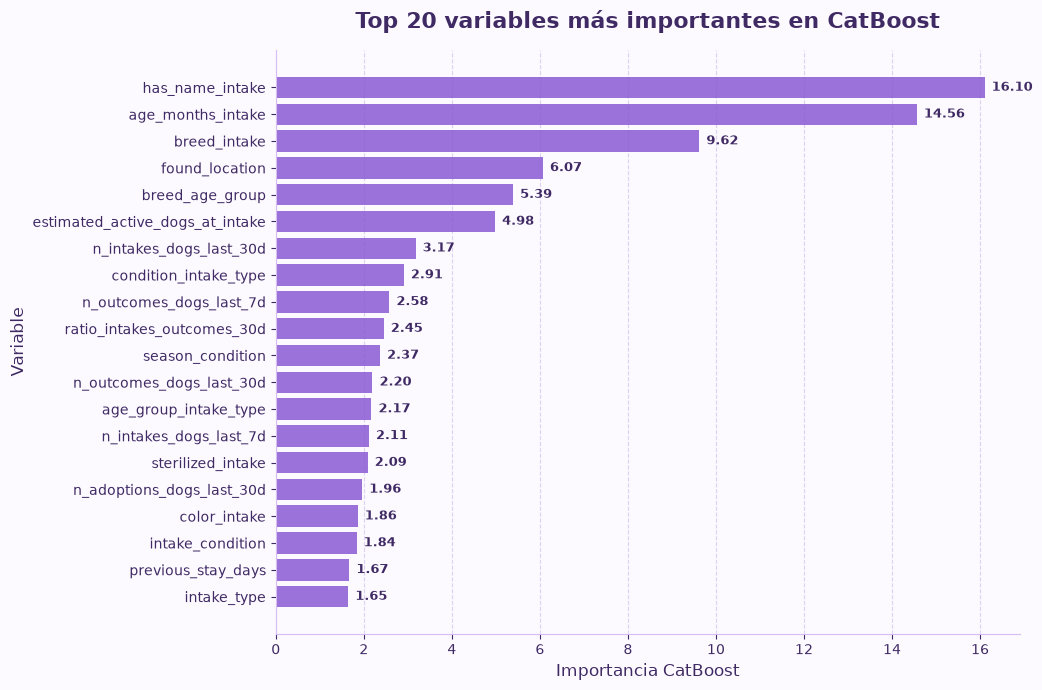

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\importancia_variables_catboost.png


In [52]:
# Gráfico de importancia global de CatBoost

top_n = 20

datos_plot = (
    importancia_catboost_df
    .head(top_n)
    .sort_values("importancia_catboost", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_plot["variable"],
    datos_plot["importancia_catboost"],
    color="#8A5BD3",
    alpha=0.85
)

for i, valor in enumerate(datos_plot["importancia_catboost"]):
    ax.text(
        valor + datos_plot["importancia_catboost"].max() * 0.01,
        i,
        f"{valor:.2f}",
        va="center",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Top 20 variables más importantes en CatBoost",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Importancia CatBoost", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "importancia_variables_catboost.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [53]:
# Guardado de importancia de variables CatBoost

importancia_catboost_path = interpretability_path / "importancia_variables_catboost.csv"

importancia_catboost_df.to_csv(
    importancia_catboost_path,
    index=False,
    encoding="utf-8-sig"
)

print("Importancia de variables CatBoost guardada en:")
print(importancia_catboost_path)

Importancia de variables CatBoost guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\importancia_variables_catboost.csv


### 3.1. Importancia global de variables en LightGBM

Además de CatBoost, el modelo final incorpora LightGBM como segundo componente del ensemble. Para interpretar su contribución, se analiza la importancia de variables del modelo LightGBM.

Dado que LightGBM trabaja con variables transformadas, especialmente tras la codificación de variables categóricas, se agrupan las importancias a nivel de variable original. De este modo, la interpretación resulta comparable con el análisis realizado para CatBoost.

In [54]:
# Importancia global de variables en LightGBM agrupada por variable original

def obtener_estimador_con_importancia(modelo):
    """
    Localiza el estimador final con atributo feature_importances_.
    Funciona tanto si el modelo es un estimador directo como si es un Pipeline.
    """
    if hasattr(modelo, "feature_importances_"):
        return modelo
    
    if hasattr(modelo, "named_steps"):
        for nombre_paso, paso in modelo.named_steps.items():
            if hasattr(paso, "feature_importances_"):
                return paso
    
    raise ValueError("No se ha encontrado un estimador con feature_importances_.")


def obtener_nombres_variables_transformadas(modelo, variables_originales):
    """
    Obtiene los nombres de las variables tras el preprocesado si están disponibles.
    Si no es posible, devuelve nombres genéricos.
    """
    if hasattr(modelo, "named_steps"):
        for nombre_paso, paso in modelo.named_steps.items():
            if hasattr(paso, "get_feature_names_out"):
                try:
                    return list(paso.get_feature_names_out())
                except Exception:
                    pass
    
    return list(variables_originales)


def extraer_variable_original(nombre_transformado, variables_originales):
    """
    Recupera la variable original a partir de un nombre transformado por sklearn.
    Por ejemplo:
    cat__intake_type_Stray -> intake_type
    num__age_months_intake -> age_months_intake
    """
    nombre = str(nombre_transformado)
    
    if "__" in nombre:
        nombre = nombre.split("__", 1)[1]
    
    if nombre in variables_originales:
        return nombre
    
    candidatas = [
        variable for variable in variables_originales
        if nombre == variable or nombre.startswith(variable + "_")
    ]
    
    if candidatas:
        return max(candidatas, key=len)
    
    return nombre


estimador_lgbm = obtener_estimador_con_importancia(modelo_lgbm)
importancias_lgbm = estimador_lgbm.feature_importances_

nombres_transformados_lgbm = obtener_nombres_variables_transformadas(
    modelo_lgbm,
    variables_lgbm
)

if len(nombres_transformados_lgbm) != len(importancias_lgbm):
    nombres_transformados_lgbm = [
        f"feature_{i}" for i in range(len(importancias_lgbm))
    ]

importancia_lgbm_detalle_df = pd.DataFrame({
    "variable_transformada": nombres_transformados_lgbm,
    "importancia_lgbm": importancias_lgbm
})

importancia_lgbm_detalle_df["variable"] = importancia_lgbm_detalle_df[
    "variable_transformada"
].apply(
    lambda x: extraer_variable_original(x, variables_lgbm)
)

importancia_lgbm_df = (
    importancia_lgbm_detalle_df
    .groupby("variable", as_index=False)
    .agg(importancia_lgbm=("importancia_lgbm", "sum"))
)

importancia_lgbm_df["importancia_lgbm_normalizada"] = (
    importancia_lgbm_df["importancia_lgbm"]
    / importancia_lgbm_df["importancia_lgbm"].sum()
)

importancia_lgbm_df = (
    importancia_lgbm_df
    .sort_values("importancia_lgbm", ascending=False)
    .reset_index(drop=True)
)

importancia_lgbm_df[
    ["importancia_lgbm", "importancia_lgbm_normalizada"]
] = importancia_lgbm_df[
    ["importancia_lgbm", "importancia_lgbm_normalizada"]
].round(6)

print("Top 20 variables más importantes en LightGBM agrupadas por variable original:")
display(importancia_lgbm_df.head(20))

Top 20 variables más importantes en LightGBM agrupadas por variable original:


,variable,importancia_lgbm,importancia_lgbm_normalizada
0,estimated_active_dogs_at_intake,1854,0.088286
1,ratio_intakes_outcomes_30d,1718,0.081810
2,n_intakes_dogs_last_7d,1621,0.077190
3,n_outcomes_dogs_last_7d,1566,0.074571
4,age_months_intake,1541,0.073381
5,n_adoptions_dogs_last_30d,1520,0.072381
6,n_intakes_dogs_last_30d,1387,0.066048
7,n_outcomes_dogs_last_30d,1263,0.060143
8,intake_hour,1045,0.049762
9,main_breed_grouped,1002,0.047714


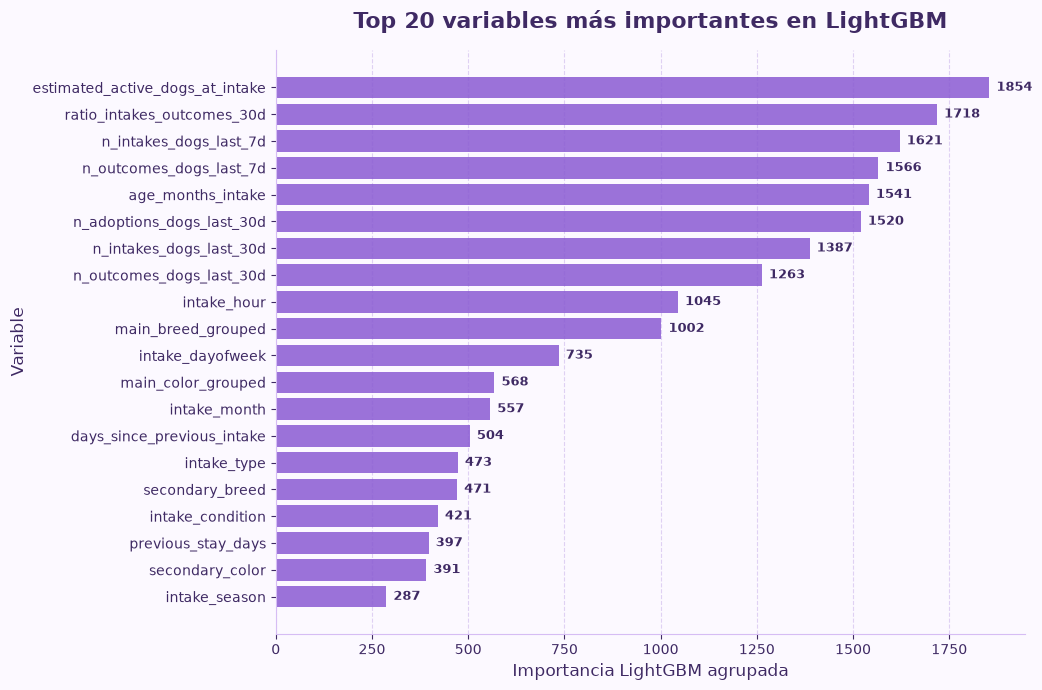

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\importancia_variables_lgbm.png


In [55]:
# Gráfico de importancia global de LightGBM

top_n = 20

datos_plot = (
    importancia_lgbm_df
    .head(top_n)
    .sort_values("importancia_lgbm", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_plot["variable"],
    datos_plot["importancia_lgbm"],
    color="#8A5BD3",
    alpha=0.85
)

for i, valor in enumerate(datos_plot["importancia_lgbm"]):
    ax.text(
        valor + datos_plot["importancia_lgbm"].max() * 0.01,
        i,
        f"{valor:.0f}",
        va="center",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Top 20 variables más importantes en LightGBM",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Importancia LightGBM agrupada", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "importancia_variables_lgbm.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [56]:
# Guardado de importancia de variables LightGBM

importancia_lgbm_path = interpretability_path / "importancia_variables_lgbm.csv"
importancia_lgbm_detalle_path = interpretability_path / "importancia_variables_lgbm_detalle_transformadas.csv"

importancia_lgbm_df.to_csv(
    importancia_lgbm_path,
    index=False,
    encoding="utf-8-sig"
)

importancia_lgbm_detalle_df.to_csv(
    importancia_lgbm_detalle_path,
    index=False,
    encoding="utf-8-sig"
)

print("Importancia de variables LightGBM guardada en:")
print(importancia_lgbm_path)

print("\nDetalle de variables transformadas LightGBM guardado en:")
print(importancia_lgbm_detalle_path)

Importancia de variables LightGBM guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\importancia_variables_lgbm.csv

Detalle de variables transformadas LightGBM guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\importancia_variables_lgbm_detalle_transformadas.csv


### 3.2. Importancia combinada del ensemble

Tras analizar por separado las importancias de CatBoost y LightGBM, se construye una importancia combinada ponderada utilizando los pesos del ensemble final.

Esta aproximación permite obtener una visión global orientativa de qué variables tienen mayor peso conjunto en el modelo final. No obstante, debe interpretarse con cautela, ya que las importancias internas de CatBoost y LightGBM no son estrictamente equivalentes. Por ello, la importancia combinada se utiliza como una herramienta descriptiva para resumir el comportamiento global del ensemble.

In [57]:
# Importancia combinada del ensemble CatBoost + LightGBM

importancia_catboost_combinada = importancia_catboost_df[
    [
        "variable",
        "importancia_catboost_normalizada"
    ]
].copy()

importancia_lgbm_combinada = importancia_lgbm_df[
    [
        "variable",
        "importancia_lgbm_normalizada"
    ]
].copy()

importancia_ensemble_df = importancia_catboost_combinada.merge(
    importancia_lgbm_combinada,
    on="variable",
    how="outer"
)

importancia_ensemble_df["importancia_catboost_normalizada"] = (
    importancia_ensemble_df["importancia_catboost_normalizada"].fillna(0)
)

importancia_ensemble_df["importancia_lgbm_normalizada"] = (
    importancia_ensemble_df["importancia_lgbm_normalizada"].fillna(0)
)

importancia_ensemble_df["peso_catboost"] = peso_catboost
importancia_ensemble_df["peso_lgbm"] = peso_lgbm

importancia_ensemble_df["importancia_ensemble"] = (
    peso_catboost * importancia_ensemble_df["importancia_catboost_normalizada"]
    + peso_lgbm * importancia_ensemble_df["importancia_lgbm_normalizada"]
)

importancia_ensemble_df = (
    importancia_ensemble_df
    .sort_values("importancia_ensemble", ascending=False)
    .reset_index(drop=True)
)

importancia_ensemble_df[
    [
        "importancia_catboost_normalizada",
        "importancia_lgbm_normalizada",
        "importancia_ensemble"
    ]
] = importancia_ensemble_df[
    [
        "importancia_catboost_normalizada",
        "importancia_lgbm_normalizada",
        "importancia_ensemble"
    ]
].round(6)

print("Top 25 variables por importancia combinada del ensemble:")
display(importancia_ensemble_df.head(25))

Top 25 variables por importancia combinada del ensemble:


,variable,importancia_catboost_normalizada,importancia_lgbm_normalizada,peso_catboost,peso_lgbm,importancia_ensemble
0,age_months_intake,0.145627,0.073381,0.725,0.275,0.125759
1,has_name_intake,0.161011,0.005000,0.725,0.275,0.118108
2,breed_intake,0.096213,0.000000,0.725,0.275,0.069754
3,estimated_active_dogs_at_intake,0.049807,0.088286,0.725,0.275,0.060389
4,found_location,0.060679,0.000000,0.725,0.275,0.043992
5,n_intakes_dogs_last_30d,0.031748,0.066048,0.725,0.275,0.041180
6,ratio_intakes_outcomes_30d,0.024514,0.081810,0.725,0.275,0.040270
7,n_outcomes_dogs_last_7d,0.025794,0.074571,0.725,0.275,0.039208
8,breed_age_group,0.053896,0.000000,0.725,0.275,0.039075
9,n_intakes_dogs_last_7d,0.021143,0.077190,0.725,0.275,0.036556


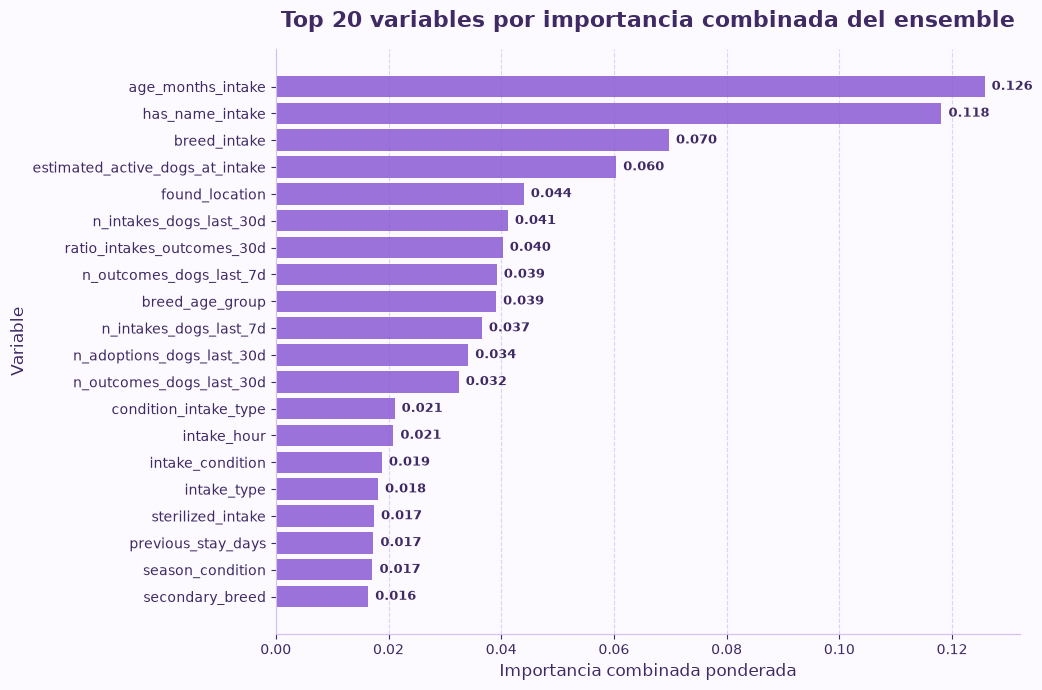

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\importancia_variables_ensemble_combinada.png


In [58]:
# Gráfico de importancia combinada del ensemble

top_n = 20

datos_plot = (
    importancia_ensemble_df
    .head(top_n)
    .sort_values("importancia_ensemble", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_plot["variable"],
    datos_plot["importancia_ensemble"],
    color="#8A5BD3",
    alpha=0.85
)

for i, valor in enumerate(datos_plot["importancia_ensemble"]):
    ax.text(
        valor + datos_plot["importancia_ensemble"].max() * 0.01,
        i,
        f"{valor:.3f}",
        va="center",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Top 20 variables por importancia combinada del ensemble",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Importancia combinada ponderada", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "importancia_variables_ensemble_combinada.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [59]:
# Guardado de importancia combinada del ensemble

importancia_ensemble_path = interpretability_path / "importancia_variables_ensemble_combinada.csv"

importancia_ensemble_df.to_csv(
    importancia_ensemble_path,
    index=False,
    encoding="utf-8-sig"
)

print("Importancia combinada del ensemble guardada en:")
print(importancia_ensemble_path)

Importancia combinada del ensemble guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\importancia_variables_ensemble_combinada.csv


### 3.3. Interpretabilidad global mediante SHAP en CatBoost

Para complementar las importancias internas del modelo, se utiliza SHAP sobre el componente CatBoost del ensemble.

SHAP permite estimar la contribución de cada variable a la predicción del modelo para cada perro. En este análisis se calcula la importancia media absoluta de los valores SHAP, lo que permite identificar qué variables tienen mayor impacto global en las predicciones.

Este análisis se centra en CatBoost porque es el componente con mayor peso dentro del ensemble final y porque gestiona directamente variables categóricas de alta cardinalidad como la raza, el color y la localización.

In [60]:
# Cálculo de valores SHAP para CatBoost sobre una muestra del conjunto de test

from catboost import Pool

n_muestra_shap = min(3000, len(dogs_score_test))

indices_muestra_shap = (
    dogs_score_test
    .sample(n=n_muestra_shap, random_state=RANDOM_STATE)
    .index
)

X_catboost_shap = X_catboost.loc[indices_muestra_shap, variables_catboost].copy()

variables_categoricas_catboost_presentes = [
    col for col in variables_categoricas_catboost
    if col in X_catboost_shap.columns
]

for col in variables_categoricas_catboost_presentes:
    X_catboost_shap[col] = (
        X_catboost_shap[col]
        .fillna("Sin información")
        .astype(str)
    )

pool_shap_catboost = Pool(
    X_catboost_shap,
    cat_features=variables_categoricas_catboost_presentes
)

shap_values_catboost_raw = modelo_catboost.get_feature_importance(
    pool_shap_catboost,
    type="ShapValues"
)

# La última columna corresponde al valor base del modelo
shap_values_catboost = shap_values_catboost_raw[:, :-1]
shap_base_value_catboost = shap_values_catboost_raw[:, -1]

print("Valores SHAP de CatBoost calculados correctamente.")
print("Muestra utilizada:", X_catboost_shap.shape)
print("Matriz SHAP:", shap_values_catboost.shape)
print("Valor base medio:", round(float(np.mean(shap_base_value_catboost)), 4))

Valores SHAP de CatBoost calculados correctamente.
Muestra utilizada: (3000, 41)
Matriz SHAP: (3000, 41)
Valor base medio: -2.2563


In [61]:
# Ranking global de variables según SHAP medio absoluto

shap_importance_catboost_df = pd.DataFrame({
    "variable": variables_catboost,
    "mean_abs_shap": np.abs(shap_values_catboost).mean(axis=0),
    "mean_shap": shap_values_catboost.mean(axis=0)
})

shap_importance_catboost_df["mean_abs_shap_normalizado"] = (
    shap_importance_catboost_df["mean_abs_shap"]
    / shap_importance_catboost_df["mean_abs_shap"].sum()
)

shap_importance_catboost_df = (
    shap_importance_catboost_df
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance_catboost_df[
    ["mean_abs_shap", "mean_shap", "mean_abs_shap_normalizado"]
] = shap_importance_catboost_df[
    ["mean_abs_shap", "mean_shap", "mean_abs_shap_normalizado"]
].round(6)

print("Top 20 variables según SHAP medio absoluto en CatBoost:")
display(shap_importance_catboost_df.head(20))

Top 20 variables según SHAP medio absoluto en CatBoost:


,variable,mean_abs_shap,mean_shap,mean_abs_shap_normalizado
0,has_name_intake,0.464914,0.005745,0.162851
1,breed_intake,0.342076,-0.011214,0.119823
2,age_months_intake,0.238459,0.004341,0.083528
3,found_location,0.160819,-0.018224,0.056332
4,sterilized_intake,0.154580,0.013889,0.054146
5,breed_age_group,0.154284,-0.001332,0.054043
6,estimated_active_dogs_at_intake,0.153415,-0.005997,0.053738
7,condition_intake_type,0.125172,-0.001173,0.043845
8,is_mixed_breed,0.077955,0.002128,0.027306
9,age_group_intake_type,0.075485,0.010573,0.026441


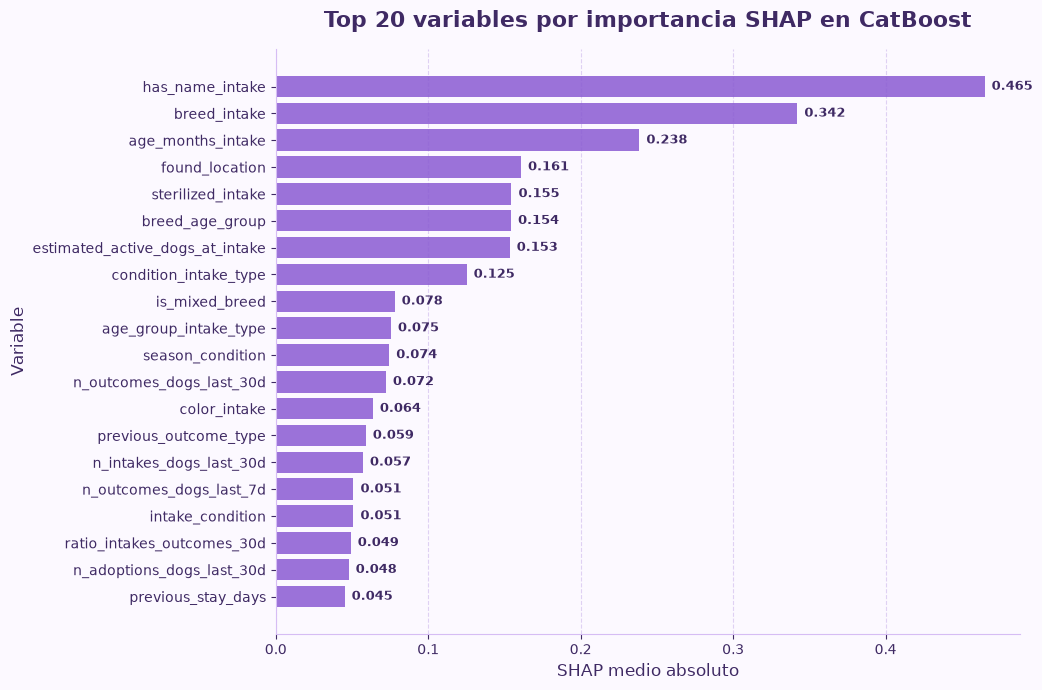

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\shap_importance_catboost_global.png


In [62]:
# Gráfico de importancia SHAP global de CatBoost

top_n = 20

datos_plot = (
    shap_importance_catboost_df
    .head(top_n)
    .sort_values("mean_abs_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_plot["variable"],
    datos_plot["mean_abs_shap"],
    color="#8A5BD3",
    alpha=0.85
)

for i, valor in enumerate(datos_plot["mean_abs_shap"]):
    ax.text(
        valor + datos_plot["mean_abs_shap"].max() * 0.01,
        i,
        f"{valor:.3f}",
        va="center",
        fontsize=9,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Top 20 variables por importancia SHAP en CatBoost",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("SHAP medio absoluto", fontsize=12, color="#3F2A64")
ax.set_ylabel("Variable", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "shap_importance_catboost_global.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [63]:
# Guardado del ranking global SHAP de CatBoost

shap_importance_catboost_path = interpretability_path / "shap_importance_catboost_global.csv"

shap_importance_catboost_df.to_csv(
    shap_importance_catboost_path,
    index=False,
    encoding="utf-8-sig"
)

print("Importancia SHAP global de CatBoost guardada en:")
print(shap_importance_catboost_path)

Importancia SHAP global de CatBoost guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\shap_importance_catboost_global.csv


El análisis SHAP global confirma qué variables tienen mayor impacto en las predicciones del componente CatBoost.

A diferencia de las importancias internas del modelo, SHAP permite aproximar la contribución media de cada variable sobre las predicciones individuales. Por ello, este análisis refuerza la interpretabilidad del modelo y permite identificar los factores que más influyen en la estimación del riesgo de larga estancia.

Los resultados deben interpretarse como señales predictivas y no como relaciones causales. Es decir, una variable puede estar asociada a un mayor o menor riesgo estimado sin que necesariamente sea la causa directa de la larga estancia.

### 3.4. Importancia por familias de variables

Además del ranking individual de variables, se agrupan las variables más relevantes en familias interpretativas. Esta agrupación permite analizar qué tipo de información utiliza el modelo para estimar el riesgo de larga estancia.

Las familias consideradas son:

- características individuales del perro;
- raza, color y composición;
- información de entrada al refugio;
- historial previo;
- contexto operativo del refugio;
- temporalidad;
- variables de interacción.

Este análisis facilita una interpretación más agregada del modelo y permite comprobar si el riesgo estimado depende únicamente de las características del animal o también del contexto del refugio.

In [64]:
# Agrupación de variables por familias interpretativas

def asignar_familia_variable(variable):
    if variable in [
        "age_months_intake",
        "age_group",
        "sex",
        "sterilized_intake",
        "has_name_intake"
    ]:
        return "Características individuales"

    elif variable in [
        "breed_intake",
        "main_breed",
        "main_breed_grouped",
        "is_mixed_breed",
        "has_secondary_breed",
        "secondary_breed",
        "breed_num_terms",
        "color_intake",
        "main_color",
        "main_color_grouped",
        "has_secondary_color",
        "secondary_color",
        "color_num_terms"
    ]:
        return "Raza, color y composición"

    elif variable in [
        "intake_type",
        "intake_condition",
        "found_location",
        "found_location_grouped"
    ]:
        return "Entrada al refugio"

    elif variable in [
        "previous_intake_count",
        "is_repeat_intake",
        "days_since_previous_intake",
        "previous_outcome_type",
        "previous_stay_days",
        "previous_long_stay_count",
        "previous_owner_surrender_count",
        "previous_stray_count"
    ]:
        return "Historial previo"

    elif variable in [
        "n_intakes_dogs_last_7d",
        "n_intakes_dogs_last_30d",
        "n_outcomes_dogs_last_7d",
        "n_outcomes_dogs_last_30d",
        "n_adoptions_dogs_last_30d",
        "estimated_active_dogs_at_intake",
        "ratio_intakes_outcomes_30d"
    ]:
        return "Contexto operativo del refugio"

    elif variable in [
        "intake_month",
        "intake_dayofweek",
        "intake_hour",
        "intake_is_weekend",
        "intake_season"
    ]:
        return "Temporalidad"

    elif variable in [
        "age_group_intake_type",
        "condition_intake_type",
        "breed_age_group",
        "season_condition"
    ]:
        return "Interacciones"

    else:
        return "Otras variables"


importancia_ensemble_familias = importancia_ensemble_df.copy()
importancia_ensemble_familias["familia_variable"] = importancia_ensemble_familias["variable"].apply(
    asignar_familia_variable
)

resumen_importancia_familias = (
    importancia_ensemble_familias
    .groupby("familia_variable", as_index=False)
    .agg(
        importancia_total=("importancia_ensemble", "sum"),
        n_variables=("variable", "count")
    )
)

resumen_importancia_familias["porcentaje_importancia"] = (
    resumen_importancia_familias["importancia_total"]
    / resumen_importancia_familias["importancia_total"].sum()
    * 100
)

resumen_importancia_familias = (
    resumen_importancia_familias
    .sort_values("importancia_total", ascending=False)
    .reset_index(drop=True)
)

resumen_importancia_familias[
    ["importancia_total", "porcentaje_importancia"]
] = resumen_importancia_familias[
    ["importancia_total", "porcentaje_importancia"]
].round(4)

print("Importancia combinada del ensemble por familia de variables:")
display(resumen_importancia_familias)

Importancia combinada del ensemble por familia de variables:


,familia_variable,importancia_total,n_variables,porcentaje_importancia
0,Características individuales,0.2858,5,28.5795
1,Contexto operativo del refugio,0.2842,7,28.4199
2,"Raza, color y composición",0.1439,11,14.3888
3,Interacciones,0.0931,4,9.3058
4,Entrada al refugio,0.0845,4,8.4498
5,Historial previo,0.0549,8,5.4895
6,Temporalidad,0.0537,5,5.3667


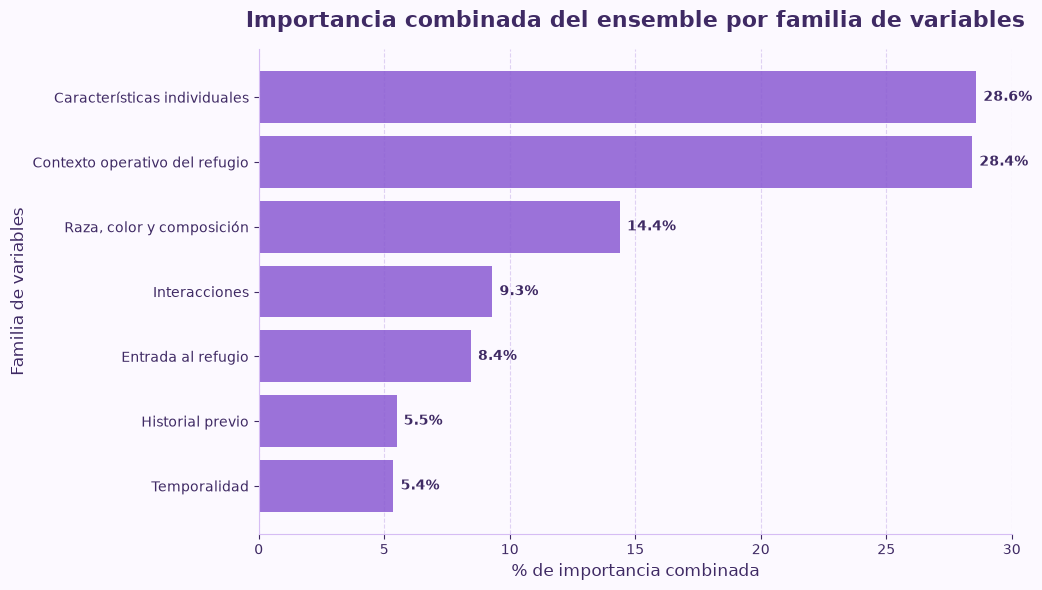

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\importancia_ensemble_por_familias.png


In [65]:
# Gráfico de importancia combinada por familias de variables

datos_plot = (
    resumen_importancia_familias
    .sort_values("importancia_total", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    datos_plot["familia_variable"],
    datos_plot["porcentaje_importancia"],
    color="#8A5BD3",
    alpha=0.85
)

for i, valor in enumerate(datos_plot["porcentaje_importancia"]):
    ax.text(
        valor + datos_plot["porcentaje_importancia"].max() * 0.01,
        i,
        f"{valor:.1f}%",
        va="center",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Importancia combinada del ensemble por familia de variables",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("% de importancia combinada", fontsize=12, color="#3F2A64")
ax.set_ylabel("Familia de variables", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "importancia_ensemble_por_familias.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [66]:
# Guardado de importancia por familias

importancia_familias_path = interpretability_path / "importancia_ensemble_por_familias.csv"

resumen_importancia_familias.to_csv(
    importancia_familias_path,
    index=False,
    encoding="utf-8-sig"
)

print("Importancia por familias guardada en:")
print(importancia_familias_path)

Importancia por familias guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\importancia_ensemble_por_familias.csv


## 4. Perfiles de riesgo asociados al Invisible Dog Score

Tras analizar las variables más importantes del modelo, se estudian los perfiles asociados a cada banda del Invisible Dog Score.

El objetivo de esta sección es traducir las predicciones del modelo a una lectura más comprensible desde el punto de vista operativo. Para ello, se comparan las características de los perros clasificados en las bandas de bajo riesgo, riesgo medio, riesgo alto y riesgo crítico.

Este análisis permite identificar patrones generales en cada grupo y ayuda a interpretar qué tipo de perros tienden a concentrarse en los niveles más altos de riesgo estimado.

In [67]:
# Perfil numérico por banda de riesgo en test

variables_numericas_perfil = [
    "invisible_dog_score",
    "stay_days_rounded",
    "age_months_intake",
    "previous_intake_count",
    "previous_stay_days",
    "previous_long_stay_count",
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

variables_numericas_perfil = [
    col for col in variables_numericas_perfil
    if col in dogs_score_test.columns
]

perfil_numerico_bandas = (
    dogs_score_test
    .groupby("banda_riesgo", observed=False)[variables_numericas_perfil]
    .agg(["mean", "median"])
)

perfil_numerico_bandas = perfil_numerico_bandas.round(2)

print("Perfil numérico por banda de riesgo:")
display(perfil_numerico_bandas)

Perfil numérico por banda de riesgo:


invisible_dog_score        stay_days_rounded        age_months_intake        previous_intake_count        previous_stay_days        previous_long_stay_count  \
                              mean median              mean median              mean median                  mean median               mean median                     mean   
banda_riesgo                                                                                                                                                                  
Bajo riesgo                   7.97    6.1             12.50    5.0             29.81  12.00                  0.19    0.0               9.25    5.0                     0.01   
Riesgo medio                 35.27   34.5             46.97   18.0             32.85  24.00                  0.26    0.0              30.32   17.0                     0.08   
Riesgo alto                  59.19   58.0             75.93   38.0             31.63  24.00                  0.38    0.0              78.88   49.5                     0.22   
Riesgo crítico               89.58   91.9             65.91   56.0              7.09   0.23                  0.14    0.0             207.48  184.0                     0.10   

                      estimated_active_dogs_at_intake        ratio_intakes_outcomes_30d         
               median                            mean median                       mean median  
banda_riesgo                                                                                    
Bajo riesgo       0.0                          469.21  464.0                       1.02   1.00  
Riesgo medio      0.0                          480.84  476.0                       1.02   1.01  
Riesgo alto       0.0                          509.21  511.0                       1.02   1.01  
Riesgo crítico    0.0                          491.97  485.0                       1.02   1.01

In [68]:
# Resumen compacto de perfiles por banda de riesgo

perfil_compacto_bandas = (
    dogs_score_test
    .groupby("banda_riesgo", observed=False)
    .agg(
        n_perros=("animal_id", "count"),
        tasa_real_larga_estancia=("target_long_stay", "mean"),
        score_medio=("invisible_dog_score", "mean"),
        estancia_media_dias=("stay_days_rounded", "mean"),
        edad_media_meses=("age_months_intake", "mean"),
        entradas_previas_medias=("previous_intake_count", "mean"),
        estancias_previas_medias=("previous_stay_days", "mean"),
        largas_estancias_previas_medias=("previous_long_stay_count", "mean"),
        perros_activos_estimados_media=("estimated_active_dogs_at_intake", "mean"),
        ratio_entradas_salidas_30d_medio=("ratio_intakes_outcomes_30d", "mean")
    )
    .reset_index()
)

perfil_compacto_bandas[
    [
        "tasa_real_larga_estancia",
        "score_medio",
        "estancia_media_dias",
        "edad_media_meses",
        "entradas_previas_medias",
        "estancias_previas_medias",
        "largas_estancias_previas_medias",
        "perros_activos_estimados_media",
        "ratio_entradas_salidas_30d_medio"
    ]
] = perfil_compacto_bandas[
    [
        "tasa_real_larga_estancia",
        "score_medio",
        "estancia_media_dias",
        "edad_media_meses",
        "entradas_previas_medias",
        "estancias_previas_medias",
        "largas_estancias_previas_medias",
        "perros_activos_estimados_media",
        "ratio_entradas_salidas_30d_medio"
    ]
].round(3)

print("Resumen compacto de perfiles por banda de riesgo:")
display(perfil_compacto_bandas)

Resumen compacto de perfiles por banda de riesgo:


,banda_riesgo,n_perros,tasa_real_larga_estancia,score_medio,estancia_media_dias,edad_media_meses,entradas_previas_medias,estancias_previas_medias,largas_estancias_previas_medias,perros_activos_estimados_media,ratio_entradas_salidas_30d_medio
0,Bajo riesgo,14610,0.068,7.966,12.497,29.811,0.194,9.247,0.010,469.208,1.019
1,Riesgo medio,3013,0.383,35.270,46.973,32.854,0.264,30.325,0.078,480.844,1.019
2,Riesgo alto,789,0.587,59.192,75.928,31.628,0.381,78.883,0.217,509.212,1.023
3,Riesgo crítico,340,0.926,89.575,65.909,7.090,0.141,207.484,0.103,491.974,1.020


In [69]:
# Perfil categórico por banda de riesgo

variables_categoricas_perfil = [
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_group",
    "breed_intake",
    "color_intake",
    "found_location"
]

variables_categoricas_perfil = [
    col for col in variables_categoricas_perfil
    if col in dogs_score_test.columns
]

def categoria_mas_frecuente(serie):
    serie = serie.dropna()
    if len(serie) == 0:
        return "Sin información"
    return serie.value_counts().index[0]

def porcentaje_categoria_mas_frecuente(serie):
    serie = serie.dropna()
    if len(serie) == 0:
        return np.nan
    return serie.value_counts(normalize=True).iloc[0] * 100

resultados_perfil_categorico = []

for banda in orden_bandas:
    datos_banda = dogs_score_test.loc[
        dogs_score_test["banda_riesgo"] == banda
    ]
    
    fila = {
        "banda_riesgo": banda,
        "n_perros": len(datos_banda)
    }
    
    for variable in variables_categoricas_perfil:
        fila[f"{variable}_mas_frecuente"] = categoria_mas_frecuente(datos_banda[variable])
        fila[f"{variable}_porcentaje"] = porcentaje_categoria_mas_frecuente(datos_banda[variable])
    
    resultados_perfil_categorico.append(fila)

perfil_categorico_bandas = pd.DataFrame(resultados_perfil_categorico)

columnas_porcentaje = [
    col for col in perfil_categorico_bandas.columns
    if col.endswith("_porcentaje")
]

perfil_categorico_bandas[columnas_porcentaje] = (
    perfil_categorico_bandas[columnas_porcentaje].round(2)
)

print("Perfil categórico por banda de riesgo:")
display(perfil_categorico_bandas)

Perfil categórico por banda de riesgo:


,banda_riesgo,n_perros,intake_type_mas_frecuente,intake_type_porcentaje,intake_condition_mas_frecuente,intake_condition_porcentaje,sex_mas_frecuente,sex_porcentaje,sterilized_intake_mas_frecuente,sterilized_intake_porcentaje,age_group_mas_frecuente,age_group_porcentaje,breed_intake_mas_frecuente,breed_intake_porcentaje,color_intake_mas_frecuente,color_intake_porcentaje,found_location_mas_frecuente,found_location_porcentaje
0,Bajo riesgo,14610,Stray,69.74,Normal,91.16,Macho,52.23,No esterilizado,64.59,Joven,41.75,Chihuahua Shorthair Mix,8.99,Black/White,11.03,Austin (TX),17.99
1,Riesgo medio,3013,Stray,58.78,Normal,82.48,Macho,54.33,No esterilizado,68.10,Joven,55.53,Pit Bull Mix,27.18,Black/White,12.51,Austin (TX),25.06
2,Riesgo alto,789,Stray,55.13,Normal,76.30,Macho,55.89,No esterilizado,69.07,Joven,53.74,Pit Bull Mix,27.50,Black/White,16.86,Austin (TX),25.22
3,Riesgo crítico,340,Stray,73.24,Normal,68.24,Macho,55.29,No esterilizado,89.12,Cachorro,84.71,Labrador Retriever Mix,13.82,Black/White,16.76,Austin (TX),26.47


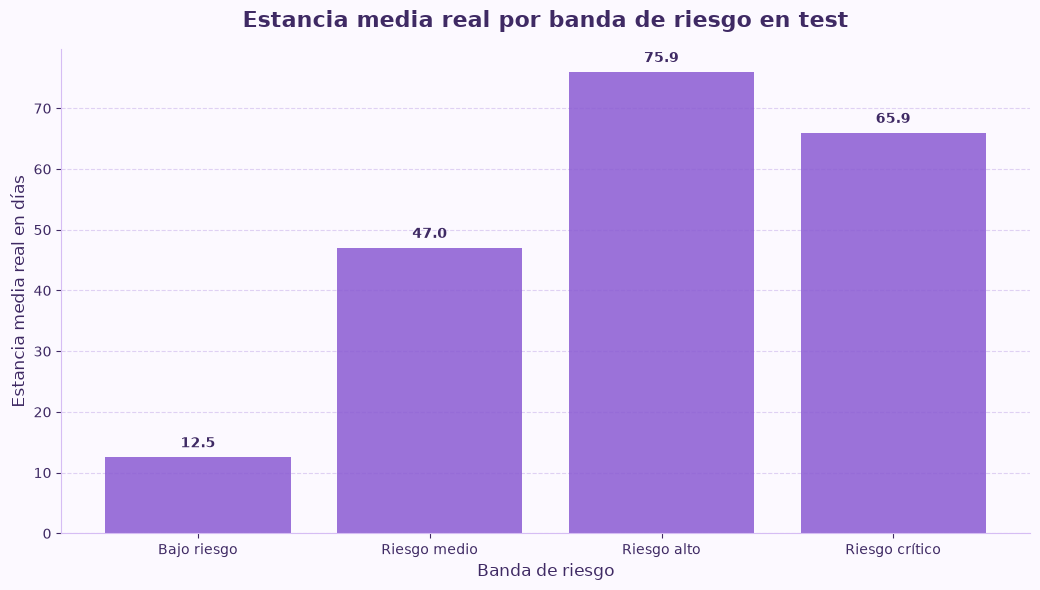

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\estancia_media_por_banda_riesgo_test.png


In [70]:
# Gráfico de estancia media por banda de riesgo

datos_plot = perfil_compacto_bandas.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["banda_riesgo"].astype(str),
    datos_plot["estancia_media_dias"],
    color="#8A5BD3",
    alpha=0.85
)

for i, fila in datos_plot.iterrows():
    valor = fila["estancia_media_dias"]
    ax.text(
        i,
        valor + max(datos_plot["estancia_media_dias"]) * 0.015,
        f"{valor:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Estancia media real por banda de riesgo en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Banda de riesgo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Estancia media real en días", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "estancia_media_por_banda_riesgo_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

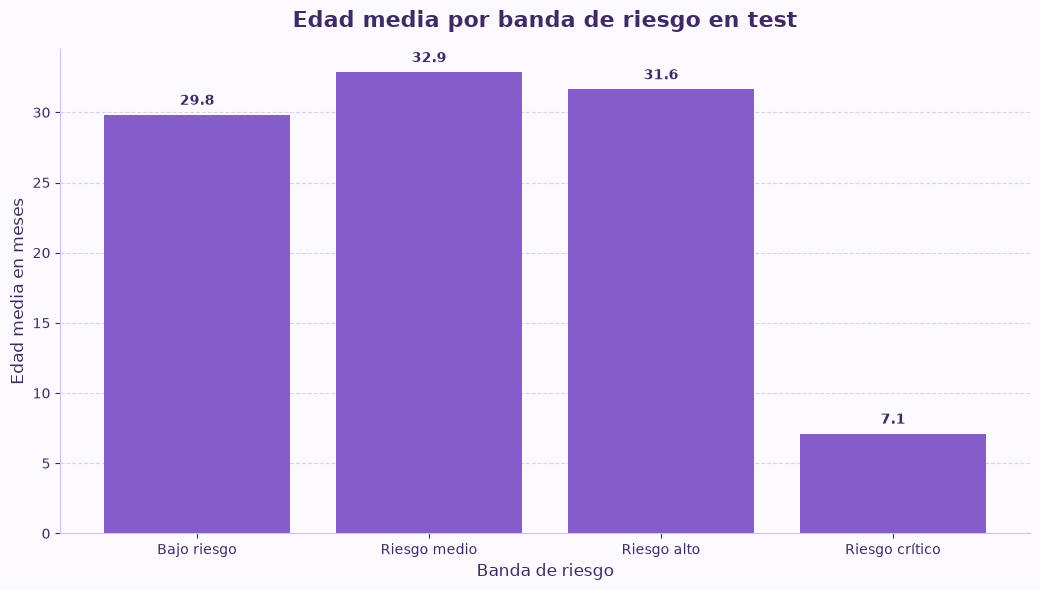

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\edad_media_por_banda_riesgo_test.png


In [71]:
# Gráfico de edad media por banda de riesgo

datos_plot = perfil_compacto_bandas.copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    datos_plot["banda_riesgo"].astype(str),
    datos_plot["edad_media_meses"],
    color="#6F42C1",
    alpha=0.85
)

for i, fila in datos_plot.iterrows():
    valor = fila["edad_media_meses"]
    ax.text(
        i,
        valor + max(datos_plot["edad_media_meses"]) * 0.015,
        f"{valor:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3F2A64",
        fontweight="bold"
    )

ax.set_title(
    "Edad media por banda de riesgo en test",
    fontsize=16,
    fontweight="bold",
    color="#3F2A64",
    pad=16
)

ax.set_xlabel("Banda de riesgo", fontsize=12, color="#3F2A64")
ax.set_ylabel("Edad media en meses", fontsize=12, color="#3F2A64")

ax.tick_params(axis="x", colors="#3F2A64")
ax.tick_params(axis="y", colors="#3F2A64")

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#8A5BD3")
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#D6BDF4")
ax.spines["bottom"].set_color("#D6BDF4")

fig.tight_layout()

fig_path = figures_path / "edad_media_por_banda_riesgo_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:")
print(fig_path)

In [72]:
# Guardado de perfiles por banda de riesgo

perfil_numerico_path = interpretability_path / "perfil_numerico_bandas_riesgo_test.csv"
perfil_compacto_path = interpretability_path / "perfil_compacto_bandas_riesgo_test.csv"
perfil_categorico_path = interpretability_path / "perfil_categorico_bandas_riesgo_test.csv"

perfil_numerico_bandas.to_csv(
    perfil_numerico_path,
    encoding="utf-8-sig"
)

perfil_compacto_bandas.to_csv(
    perfil_compacto_path,
    index=False,
    encoding="utf-8-sig"
)

perfil_categorico_bandas.to_csv(
    perfil_categorico_path,
    index=False,
    encoding="utf-8-sig"
)

print("Perfil numérico por bandas guardado en:")
print(perfil_numerico_path)

print("\nPerfil compacto por bandas guardado en:")
print(perfil_compacto_path)

print("\nPerfil categórico por bandas guardado en:")
print(perfil_categorico_path)

Perfil numérico por bandas guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\perfil_numerico_bandas_riesgo_test.csv

Perfil compacto por bandas guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\perfil_compacto_bandas_riesgo_test.csv

Perfil categórico por bandas guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\perfil_categorico_bandas_riesgo_test.csv


El análisis de perfiles por banda muestra que el Invisible Dog Score separa de forma clara los niveles de riesgo. En el conjunto de prueba, la tasa real de larga estancia aumenta desde el 6,8 % en la banda de bajo riesgo hasta el 92,6 % en la banda de riesgo crítico.

La estancia media real también aumenta de forma notable entre bajo riesgo, riesgo medio y riesgo alto. Sin embargo, en la banda de riesgo crítico, aunque la tasa real de larga estancia es la más elevada, la estancia media no supera a la banda de riesgo alto. Esto indica que el score no debe interpretarse únicamente como una estimación directa del número de días de estancia, sino como una herramienta de priorización del riesgo de superar el umbral de larga estancia.

La gráfica de edad media por banda aporta además una explicación relevante: la banda de riesgo crítico presenta una edad media claramente inferior al resto de grupos, situándose en torno a 7 meses frente a valores cercanos a 30 meses en las demás bandas. Esto sugiere que el modelo identifica en dicha banda un perfil específico de perros muy jóvenes con una probabilidad especialmente alta de larga estancia, probablemente por la combinación de múltiples características individuales y contextuales.

En conjunto, los resultados confirman que el Invisible Dog Score es útil para segmentar perros en niveles de riesgo operativamente interpretables, incluso cuando la relación entre score y estancia media no es completamente lineal en todos los grupos.

## 5. Ejemplos de perros priorizados por el Invisible Dog Score

Tras analizar el comportamiento global del score, se seleccionan ejemplos concretos de perros del conjunto de prueba.

El objetivo de esta sección es mostrar cómo el Invisible Dog Score puede utilizarse de forma operativa para priorizar la revisión de determinados casos. Para ello, se analizan diferentes grupos de perros:

- perros con mayor score estimado;
- perros correctamente priorizados que realmente tuvieron larga estancia;
- perros de bajo riesgo correctamente identificados;
- falsos positivos;
- falsos negativos.

Estos ejemplos permiten interpretar el modelo desde una perspectiva más cercana al uso real del score.

In [73]:
# Selección de ejemplos representativos para interpretación operativa

columnas_ejemplos = [
    "animal_id",
    "invisible_dog_score",
    "probabilidad_larga_estancia",
    "banda_riesgo",
    "target_long_stay",
    "prediccion_larga_estancia",
    "resultado_real",
    "prediccion_modelo",
    "tipo_resultado_modelo",
    "stay_days_rounded",
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_months_intake",
    "age_group",
    "breed_intake",
    "color_intake",
    "found_location",
    "previous_intake_count",
    "previous_stay_days",
    "previous_long_stay_count",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

columnas_ejemplos = [
    col for col in columnas_ejemplos
    if col in dogs_score_test.columns
]

ejemplos_top_score = (
    dogs_score_test[columnas_ejemplos]
    .sort_values("invisible_dog_score", ascending=False)
    .head(10)
)

ejemplos_verdaderos_positivos = (
    dogs_score_test.loc[
        dogs_score_test["tipo_resultado_modelo"] == "Verdadero positivo",
        columnas_ejemplos
    ]
    .sort_values(["invisible_dog_score", "stay_days_rounded"], ascending=[False, False])
    .head(10)
)

ejemplos_bajo_riesgo_correctos = (
    dogs_score_test.loc[
        dogs_score_test["tipo_resultado_modelo"] == "Verdadero negativo",
        columnas_ejemplos
    ]
    .sort_values("invisible_dog_score", ascending=True)
    .head(10)
)

ejemplos_falsos_positivos = (
    dogs_score_test.loc[
        dogs_score_test["tipo_resultado_modelo"] == "Falso positivo",
        columnas_ejemplos
    ]
    .sort_values(["invisible_dog_score", "stay_days_rounded"], ascending=[False, False])
    .head(10)
)

ejemplos_falsos_negativos = (
    dogs_score_test.loc[
        dogs_score_test["tipo_resultado_modelo"] == "Falso negativo",
        columnas_ejemplos
    ]
    .sort_values(["stay_days_rounded", "invisible_dog_score"], ascending=[False, False])
    .head(10)
)

print("Ejemplos con mayor Invisible Dog Score:")
display(ejemplos_top_score)

print("\nEjemplos de verdaderos positivos:")
display(ejemplos_verdaderos_positivos)

print("\nEjemplos de bajo riesgo correctamente identificados:")
display(ejemplos_bajo_riesgo_correctos)

print("\nEjemplos de falsos positivos:")
display(ejemplos_falsos_positivos)

print("\nEjemplos de falsos negativos:")
display(ejemplos_falsos_negativos)

Ejemplos con mayor Invisible Dog Score:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,target_long_stay,prediccion_larga_estancia,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
56083,A787251,99.3,0.992941,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,62,Stray,Normal,Macho,No esterilizado,0.098555,Cachorro,Black Mouth Cur Mix,White/Black,2000 Man O War in Travis (TX),0,NaN,0.0,671.0,0.818841
56078,A787246,99.2,0.991749,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,75,Stray,Normal,Macho,No esterilizado,0.098555,Cachorro,Black Mouth Cur Mix,Brown/White,2000 Man O War in Travis (TX),0,NaN,0.0,671.0,0.818841
16978,A693792,99.0,0.989790,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Hembra,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Cream/White,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407
16983,A693796,99.0,0.989790,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Hembra,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Cream/White,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407
65854,A811286,99.0,0.989515,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,57,Stray,Nursing,Macho,No esterilizado,0.065703,Cachorro,Labrador Retriever/Border Collie,White/Brown,6911 Wentworth Drive in Austin (TX),0,NaN,0.0,504.0,0.915194
65856,A811288,99.0,0.990406,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,59,Stray,Nursing,Macho,No esterilizado,0.065703,Cachorro,Labrador Retriever/Border Collie,Brown/White,6911 Wentworth Drive in Austin (TX),0,NaN,0.0,504.0,0.915194
65857,A811289,98.9,0.989147,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,63,Stray,Nursing,Hembra,No esterilizado,0.065703,Cachorro,Labrador Retriever/Border Collie,Tricolor,6911 Wentworth Drive in Austin (TX),0,NaN,0.0,504.0,0.915194
24365,A711264,98.9,0.988850,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,51,Stray,Nursing,Macho,No esterilizado,0.230150,Cachorro,Flat Coat Retriever/Papillon,Black/White,17902 Austin Blvd in Lago Vista (TX),0,NaN,0.0,437.0,0.980892
37185,A741608,98.5,0.984764,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,54,Stray,Normal,Macho,No esterilizado,0.131406,Cachorro,Siberian Husky Mix,Tan,3100 Barksdale in Travis (TX),0,NaN,0.0,449.0,0.973072
63492,A805615,98.5,0.984613,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,72,Owner Surrender,Normal,Macho,No esterilizado,0.032852,Cachorro,Labrador Retriever/Dachshund,Tricolor,5804 Burleson Road in Austin (TX),0,NaN,0.0,546.0,1.049052



Ejemplos de verdaderos positivos:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,target_long_stay,prediccion_larga_estancia,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
56083,A787251,99.3,0.992941,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,62,Stray,Normal,Macho,No esterilizado,0.098555,Cachorro,Black Mouth Cur Mix,White/Black,2000 Man O War in Travis (TX),0,NaN,0.0,671.0,0.818841
56078,A787246,99.2,0.991749,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,75,Stray,Normal,Macho,No esterilizado,0.098555,Cachorro,Black Mouth Cur Mix,Brown/White,2000 Man O War in Travis (TX),0,NaN,0.0,671.0,0.818841
65856,A811288,99.0,0.990406,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,59,Stray,Nursing,Macho,No esterilizado,0.065703,Cachorro,Labrador Retriever/Border Collie,Brown/White,6911 Wentworth Drive in Austin (TX),0,NaN,0.0,504.0,0.915194
65854,A811286,99.0,0.989515,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,57,Stray,Nursing,Macho,No esterilizado,0.065703,Cachorro,Labrador Retriever/Border Collie,White/Brown,6911 Wentworth Drive in Austin (TX),0,NaN,0.0,504.0,0.915194
16978,A693792,99.0,0.989790,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Hembra,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Cream/White,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407
16983,A693796,99.0,0.989790,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Hembra,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Cream/White,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407
65857,A811289,98.9,0.989147,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,63,Stray,Nursing,Hembra,No esterilizado,0.065703,Cachorro,Labrador Retriever/Border Collie,Tricolor,6911 Wentworth Drive in Austin (TX),0,NaN,0.0,504.0,0.915194
24365,A711264,98.9,0.988850,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,51,Stray,Nursing,Macho,No esterilizado,0.230150,Cachorro,Flat Coat Retriever/Papillon,Black/White,17902 Austin Blvd in Lago Vista (TX),0,NaN,0.0,437.0,0.980892
63492,A805615,98.5,0.984613,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,72,Owner Surrender,Normal,Macho,No esterilizado,0.032852,Cachorro,Labrador Retriever/Dachshund,Tricolor,5804 Burleson Road in Austin (TX),0,NaN,0.0,546.0,1.049052
16985,A693798,98.5,0.985221,Riesgo crítico,1,1,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Macho,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Brown/White,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407



Ejemplos de bajo riesgo correctamente identificados:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,target_long_stay,prediccion_larga_estancia,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
93706,A928297,0.1,0.000694,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,1,Stray,Sick,Macho,No esterilizado,24.000000,Joven,French Bulldog,Black/Black,Chevron in Austin (TX),0,NaN,0.0,169.0,0.705596
93746,A928689,0.1,0.000942,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,1,Abandoned,Neonatal,Desconocido,Desconocido,0.230150,Cachorro,Unknown,White/Brown,8128 N Ih35 Service Rd in Austin (TX),0,NaN,0.0,148.0,0.684615
19764,A699266,0.1,0.001481,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,1,Stray,Normal,Desconocido,Desconocido,0.065703,Cachorro,Lhasa Apso Mix,Brown,1161 Harvey Ln in Austin (TX),0,NaN,0.0,479.0,1.110818
20932,A701977,0.1,0.001105,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,1,Owner Surrender,Sick,Desconocido,Desconocido,2.000000,Cachorro,German Shepherd Mix,Tan/Black,Austin (TX),0,NaN,0.0,455.0,1.010298
72942,A836507,0.1,0.000594,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,18,Stray,Nursing,Desconocido,Desconocido,0.000000,Cachorro,German Shepherd Mix,Blue,6405 Lynch Lane in Austin (TX),0,NaN,0.0,387.0,1.138702
72943,A836508,0.1,0.000594,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,18,Stray,Nursing,Desconocido,Desconocido,0.000000,Cachorro,German Shepherd Mix,Blue,6405 Lynch Lane in Austin (TX),0,NaN,0.0,387.0,1.138702
31943,A729171,0.1,0.001185,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,8,Owner Surrender,Nursing,Desconocido,Desconocido,0.230150,Cachorro,Pit Bull Mix,White/Black,3200 Northeast Dr in Austin (TX),0,NaN,0.0,542.0,0.993691
80537,A862186,0.1,0.001275,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,1,Owner Surrender,Other,Desconocido,Desconocido,0.000000,Cachorro,Yorkshire Terrier,Black,4018 E 12Th St in Austin (TX),0,NaN,0.0,562.0,1.077187
93192,A925031,0.1,0.000789,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,1,Public Assist,Neonatal,Desconocido,Desconocido,0.131406,Cachorro,Labrador Retriever Mix,Black,2728 Capital Of Texas in Austin (TX),0,NaN,0.0,325.0,0.927195
78565,A854728,0.1,0.001364,Bajo riesgo,0,0,No larga estancia,Sin riesgo estimado,Verdadero negativo,12,Stray,Neonatal,Desconocido,Desconocido,0.032852,Cachorro,Australian Cattle Dog Mix,Tricolor,4509 St Elmo in Austin (TX),0,NaN,0.0,444.0,0.943119



Ejemplos de falsos positivos:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,target_long_stay,prediccion_larga_estancia,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
28095,A719806,97.1,0.970888,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,30,Stray,Normal,Macho,No esterilizado,0.690449,Cachorro,Queensland Heeler Mix,Black/Tan,11819 Edward St in Travis (TX),0,NaN,0.0,416.0,0.975816
16973,A693787,92.2,0.921860,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,1,Stray,Normal,Macho,No esterilizado,0.032852,Cachorro,Labrador Retriever Mix,Brown,13808 Maha Rd in Austin (TX),0,NaN,0.0,396.0,0.907407
72546,A834807,90.2,0.902139,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,30,Stray,Normal,Hembra,No esterilizado,0.920598,Cachorro,Australian Shepherd Mix,Black/White,South Pleasant Valley And Quicksilver in Austi...,0,NaN,0.0,334.0,0.876740
37594,A742456,87.7,0.877409,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,24,Stray,Normal,Hembra,No esterilizado,0.920598,Cachorro,Pit Bull Mix,Brown/Black,9100 Fm 812 Road in Travis (TX),0,NaN,0.0,422.0,0.974716
87476,A893955,87.2,0.871711,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,20,Stray,Normal,Macho,No esterilizado,11.000000,Joven,Pit Bull Mix,Black/White,Rockwood Ln And Foster Ln in Austin (TX),0,NaN,0.0,525.0,0.937984
75773,A845837,85.4,0.854285,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,10,Owner Surrender,Normal,Macho,Esterilizado,24.000000,Joven,Pit Bull Mix,Brown Brindle/White,Austin (TX),1,141.0,1.0,574.0,1.029851
33432,A732750,85.0,0.850308,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,7,Stray,Nursing,Macho,No esterilizado,0.000000,Cachorro,Labrador Retriever Mix,Sable/White,Austin (TX),0,NaN,0.0,511.0,0.949109
78544,A854601,84.9,0.849290,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,14,Owner Surrender,Normal,Macho,Esterilizado,24.000000,Joven,American Bulldog Mix,White/Black,2108 Tillery St in Austin (TX),1,502.0,1.0,472.0,0.853659
67172,A814101,84.7,0.846855,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,24,Stray,Normal,Macho,No esterilizado,0.920598,Cachorro,Golden Retriever Mix,Tan,Point North Drive And Johnny Morris Road in Au...,0,NaN,0.0,509.0,1.002557
32892,A731452,84.6,0.845545,Riesgo crítico,0,1,No larga estancia,Riesgo de larga estancia,Falso positivo,3,Owner Surrender,Normal,Macho,Esterilizado,72.000000,Adulto,Labrador Retriever Mix,Tan,Travis (TX),2,306.0,1.0,439.0,1.138783



Ejemplos de falsos negativos:


,animal_id,invisible_dog_score,probabilidad_larga_estancia,banda_riesgo,target_long_stay,prediccion_larga_estancia,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,breed_intake,color_intake,found_location,previous_intake_count,previous_stay_days,previous_long_stay_count,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d
20684,A701365,14.9,0.149450,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,1010,Stray,Normal,Hembra,No esterilizado,120.0,Senior,Labrador Retriever,Tan,501 Bastrop Hwy in Austin (TX),0,NaN,0.0,503.0,1.031100
5851,A667878,18.9,0.188923,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,807,Owner Surrender,Normal,Hembra,No esterilizado,9.0,Joven,American Bulldog Mix,Black/White,Austin (TX),0,NaN,0.0,323.0,1.070866
54044,A782837,14.4,0.144151,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,646,Stray,Normal,Hembra,No esterilizado,7.0,Joven,German Shepherd,Black/Tan,2100 Barton Spring Road in Austin (TX),0,NaN,0.0,578.0,1.114970
54290,A783420,3.3,0.033217,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,637,Stray,Normal,Hembra,No esterilizado,60.0,Adulto,Chihuahua Shorthair Mix,Brown,2027 Anchor Lane in Austin (TX),0,NaN,0.0,569.0,1.075117
54326,A783499,10.8,0.107757,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,636,Owner Surrender,Normal,Hembra,No esterilizado,48.0,Adulto,Yorkshire Terrier Mix,Gold,Austin (TX),0,NaN,0.0,586.0,1.103695
46760,A765229,17.0,0.170100,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,556,Stray,Normal,Macho,No esterilizado,12.0,Joven,Pointer Mix,White/Red,1313 Montpolis Drive in Austin (TX),0,NaN,0.0,429.0,0.997301
48440,A768706,22.2,0.222424,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,536,Stray,Normal,Hembra,No esterilizado,12.0,Joven,Staffordshire Mix,Brown/White,14611 Burnet Road in Austin (TX),0,NaN,0.0,477.0,1.050697
25068,A713196,17.3,0.173019,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,524,Owner Surrender,Normal,Hembra,Esterilizado,108.0,Senior,Australian Cattle Dog/Australian Cattle Dog,Black/White,Austin (TX),2,7.0,1.0,340.0,0.915202
35293,A737340,18.2,0.182148,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,512,Owner Surrender,Normal,Macho,Esterilizado,12.0,Joven,Anatol Shepherd Mix,Tan/Black,Austin (TX),1,83.0,1.0,432.0,0.994969
79040,A856438,23.4,0.234334,Bajo riesgo,1,0,Larga estancia,Sin riesgo estimado,Falso negativo,507,Stray,Normal,Macho,No esterilizado,12.0,Joven,Chinese Sharpei Mix,Chocolate/White,Austin (TX),0,NaN,0.0,447.0,0.984720


In [74]:
# Tabla resumen compacta de ejemplos interpretables sin duplicar perros
# Se conserva el índice original para poder calcular explicaciones locales con SHAP

columnas_resumen_ejemplos = [
    "animal_id",
    "invisible_dog_score",
    "banda_riesgo",
    "resultado_real",
    "prediccion_modelo",
    "tipo_resultado_modelo",
    "stay_days_rounded",
    "intake_type",
    "intake_condition",
    "age_group",
    "breed_intake"
]

columnas_resumen_ejemplos = [
    col for col in columnas_resumen_ejemplos
    if col in dogs_score_test.columns
]

animal_ids_usados = set()

def preparar_ejemplos_sin_duplicar(df, etiqueta_grupo, n=5):
    salida = df.loc[
        ~df["animal_id"].isin(animal_ids_usados),
        columnas_resumen_ejemplos
    ].copy().head(n)
    
    salida.insert(0, "indice_original", salida.index)
    salida.insert(0, "grupo_ejemplo", etiqueta_grupo)
    
    animal_ids_usados.update(salida["animal_id"].tolist())
    
    return salida

tabla_ejemplos_interpretables = pd.concat(
    [
        preparar_ejemplos_sin_duplicar(
            ejemplos_top_score,
            "Mayor score",
            n=5
        ),
        preparar_ejemplos_sin_duplicar(
            ejemplos_verdaderos_positivos,
            "Verdadero positivo adicional",
            n=5
        ),
        preparar_ejemplos_sin_duplicar(
            ejemplos_bajo_riesgo_correctos,
            "Bajo riesgo correcto",
            n=5
        ),
        preparar_ejemplos_sin_duplicar(
            ejemplos_falsos_positivos,
            "Falso positivo",
            n=5
        ),
        preparar_ejemplos_sin_duplicar(
            ejemplos_falsos_negativos,
            "Falso negativo",
            n=5
        )
    ],
    ignore_index=True
)

print("Tabla resumen de ejemplos interpretables sin duplicados:")
display(tabla_ejemplos_interpretables)

Tabla resumen de ejemplos interpretables sin duplicados:


,grupo_ejemplo,indice_original,animal_id,invisible_dog_score,banda_riesgo,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,intake_type,intake_condition,age_group,breed_intake
0,Mayor score,56083,A787251,99.3,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,62,Stray,Normal,Cachorro,Black Mouth Cur Mix
1,Mayor score,56078,A787246,99.2,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,75,Stray,Normal,Cachorro,Black Mouth Cur Mix
2,Mayor score,16978,A693792,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Cachorro,Labrador Retriever Mix
3,Mayor score,16983,A693796,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Cachorro,Labrador Retriever Mix
4,Mayor score,65854,A811286,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,57,Stray,Nursing,Cachorro,Labrador Retriever/Border Collie
5,Verdadero positivo adicional,65856,A811288,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,59,Stray,Nursing,Cachorro,Labrador Retriever/Border Collie
6,Verdadero positivo adicional,65857,A811289,98.9,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,63,Stray,Nursing,Cachorro,Labrador Retriever/Border Collie
7,Verdadero positivo adicional,24365,A711264,98.9,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,51,Stray,Nursing,Cachorro,Flat Coat Retriever/Papillon
8,Verdadero positivo adicional,63492,A805615,98.5,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,72,Owner Surrender,Normal,Cachorro,Labrador Retriever/Dachshund
9,Verdadero positivo adicional,16985,A693798,98.5,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Stray,Normal,Cachorro,Labrador Retriever Mix


In [75]:
# Guardado de ejemplos interpretables

ejemplos_interpretables_path = interpretability_path / "ejemplos_interpretables_invisible_dog_score_test.csv"
ejemplos_top_score_path = interpretability_path / "ejemplos_top_score_test.csv"
ejemplos_falsos_negativos_path = interpretability_path / "ejemplos_falsos_negativos_test.csv"
ejemplos_falsos_positivos_path = interpretability_path / "ejemplos_falsos_positivos_test.csv"

tabla_ejemplos_interpretables.to_csv(
    ejemplos_interpretables_path,
    index=False,
    encoding="utf-8-sig"
)

ejemplos_top_score.to_csv(
    ejemplos_top_score_path,
    index=False,
    encoding="utf-8-sig"
)

ejemplos_falsos_negativos.to_csv(
    ejemplos_falsos_negativos_path,
    index=False,
    encoding="utf-8-sig"
)

ejemplos_falsos_positivos.to_csv(
    ejemplos_falsos_positivos_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de ejemplos interpretables guardada en:")
print(ejemplos_interpretables_path)

print("\nEjemplos Top Score guardados en:")
print(ejemplos_top_score_path)

print("\nEjemplos falsos negativos guardados en:")
print(ejemplos_falsos_negativos_path)

print("\nEjemplos falsos positivos guardados en:")
print(ejemplos_falsos_positivos_path)

Tabla de ejemplos interpretables guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\ejemplos_interpretables_invisible_dog_score_test.csv

Ejemplos Top Score guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\ejemplos_top_score_test.csv

Ejemplos falsos negativos guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\ejemplos_falsos_negativos_test.csv

Ejemplos falsos positivos guardados en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\ejemplos_falsos_positivos_test.csv


Los ejemplos seleccionados permiten interpretar el Invisible Dog Score de forma más concreta.

Los perros con mayor score representan los casos que el modelo priorizaría en primer lugar. En los ejemplos mostrados, estos casos corresponden mayoritariamente a verdaderos positivos, lo que confirma la utilidad del score como ranking operativo de priorización.

Los falsos positivos muestran perros con señales de riesgo elevadas que finalmente no superaron el umbral de larga estancia. Algunos de estos casos presentan estancias cercanas a los 30 días, por lo que pueden considerarse casos frontera desde el punto de vista operativo.

Los falsos negativos son especialmente relevantes para la mejora futura del modelo, ya que corresponden a perros que finalmente tuvieron una estancia prolongada pero no fueron priorizados inicialmente. Estos casos pueden estar asociados a perfiles menos frecuentes, trayectorias atípicas o factores no recogidos en el dataset, como comportamiento, fotografías, difusión externa o cambios posteriores en el estado del animal.

En conjunto, el análisis de ejemplos concretos refuerza que el Invisible Dog Score debe entenderse como una herramienta de apoyo a la priorización, no como una decisión automática cerrada.

## 6. Explicaciones locales mediante SHAP

Tras analizar el comportamiento global del modelo, se calculan explicaciones locales para los ejemplos seleccionados.

Las explicaciones locales permiten identificar qué variables han contribuido más a aumentar o reducir el riesgo estimado de larga estancia en cada perro concreto.

En este análisis se utilizan valores SHAP del componente CatBoost, que es el modelo con mayor peso dentro del ensemble final. Los valores SHAP positivos desplazan la predicción hacia un mayor riesgo estimado, mientras que los valores SHAP negativos desplazan la predicción hacia un menor riesgo estimado.

Estas explicaciones no deben interpretarse como relaciones causales, sino como contribuciones del modelo a la predicción individual.

In [76]:
# Cálculo de explicaciones locales SHAP para los ejemplos seleccionados

from catboost import Pool

indices_ejemplos_locales = (
    tabla_ejemplos_interpretables["indice_original"]
    .dropna()
    .astype(int)
    .tolist()
)

X_catboost_local = dogs_model_ready.loc[
    indices_ejemplos_locales,
    variables_catboost
].copy()

variables_categoricas_catboost_locales = [
    col for col in variables_categoricas_catboost
    if col in X_catboost_local.columns
]

for col in variables_categoricas_catboost_locales:
    X_catboost_local[col] = (
        X_catboost_local[col]
        .fillna("Sin información")
        .astype(str)
    )

pool_local_catboost = Pool(
    X_catboost_local,
    cat_features=variables_categoricas_catboost_locales
)

shap_values_local_raw = modelo_catboost.get_feature_importance(
    pool_local_catboost,
    type="ShapValues"
)

shap_values_local = shap_values_local_raw[:, :-1]
shap_base_value_local = shap_values_local_raw[:, -1]

print("SHAP local calculado correctamente.")
print("Número de ejemplos explicados:", len(indices_ejemplos_locales))
print("Matriz SHAP local:", shap_values_local.shape)
print("Valor base medio:", round(float(np.mean(shap_base_value_local)), 4))

SHAP local calculado correctamente.
Número de ejemplos explicados: 25
Matriz SHAP local: (25, 41)
Valor base medio: -2.2563


In [77]:
# Construcción de explicaciones locales resumidas

def formatear_valor_variable(valor, max_caracteres=45):
    if pd.isna(valor):
        return "Sin información"
    
    valor_texto = str(valor)
    
    if len(valor_texto) > max_caracteres:
        valor_texto = valor_texto[:max_caracteres - 3] + "..."
    
    return valor_texto


def construir_texto_factores(df_factores):
    textos = []
    
    for _, fila in df_factores.iterrows():
        valor = formatear_valor_variable(fila["valor_variable"])
        textos.append(
            f"{fila['variable']}={valor} ({fila['shap_value']:+.3f})"
        )
    
    return " | ".join(textos)


explicaciones_locales = []

for posicion, indice_original in enumerate(indices_ejemplos_locales):
    fila_ejemplo = tabla_ejemplos_interpretables.loc[
        tabla_ejemplos_interpretables["indice_original"] == indice_original
    ].iloc[0]
    
    valores_shap = shap_values_local[posicion]
    valores_variables = X_catboost_local.iloc[posicion]
    
    factores_df = pd.DataFrame({
        "variable": variables_catboost,
        "valor_variable": valores_variables.values,
        "shap_value": valores_shap
    })
    
    factores_aumentan = (
        factores_df
        .sort_values("shap_value", ascending=False)
        .head(5)
    )
    
    factores_reducen = (
        factores_df
        .sort_values("shap_value", ascending=True)
        .head(5)
    )
    
    explicaciones_locales.append({
        "grupo_ejemplo": fila_ejemplo["grupo_ejemplo"],
        "animal_id": fila_ejemplo["animal_id"],
        "invisible_dog_score": fila_ejemplo["invisible_dog_score"],
        "banda_riesgo": fila_ejemplo["banda_riesgo"],
        "resultado_real": fila_ejemplo["resultado_real"],
        "prediccion_modelo": fila_ejemplo["prediccion_modelo"],
        "tipo_resultado_modelo": fila_ejemplo["tipo_resultado_modelo"],
        "stay_days_rounded": fila_ejemplo["stay_days_rounded"],
        "factores_aumentan_riesgo": construir_texto_factores(factores_aumentan),
        "factores_reducen_riesgo": construir_texto_factores(factores_reducen)
    })

explicaciones_locales_shap = pd.DataFrame(explicaciones_locales)

print("Explicaciones locales SHAP generadas:")
display(explicaciones_locales_shap)

Explicaciones locales SHAP generadas:


,grupo_ejemplo,animal_id,invisible_dog_score,banda_riesgo,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,factores_aumentan_riesgo,factores_reducen_riesgo
0,Mayor score,A787251,99.3,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,62,age_months_intake=0.0985545335085413 (+2.622) ...,n_outcomes_dogs_last_30d=965.0 (-0.092) | n_ad...
1,Mayor score,A787246,99.2,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,75,age_months_intake=0.0985545335085413 (+2.628) ...,n_outcomes_dogs_last_30d=965.0 (-0.098) | n_ad...
2,Mayor score,A693792,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,age_months_intake=0.0328515111695138 (+2.682) ...,estimated_active_dogs_at_intake=396.0 (-0.122)...
3,Mayor score,A693796,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,age_months_intake=0.0328515111695138 (+2.682) ...,estimated_active_dogs_at_intake=396.0 (-0.122)...
4,Mayor score,A811286,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,57,age_months_intake=0.0657030223390276 (+1.920) ...,ratio_intakes_outcomes_30d=0.91519433 (-0.058)...
5,Verdadero positivo adicional,A811288,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,59,age_months_intake=0.0657030223390276 (+1.920) ...,ratio_intakes_outcomes_30d=0.91519433 (-0.052)...
6,Verdadero positivo adicional,A811289,98.9,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,63,age_months_intake=0.0657030223390276 (+1.924) ...,ratio_intakes_outcomes_30d=0.91519433 (-0.037)...
7,Verdadero positivo adicional,A711264,98.9,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,51,found_location=17902 Austin Blvd in Lago Vista...,secondary_color=White (-0.031) | estimated_act...
8,Verdadero positivo adicional,A805615,98.5,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,72,age_months_intake=0.0328515111695138 (+2.531) ...,n_intakes_dogs_last_30d=941.0 (-0.142) | secon...
9,Verdadero positivo adicional,A693798,98.5,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,age_months_intake=0.0328515111695138 (+2.680) ...,estimated_active_dogs_at_intake=396.0 (-0.118)...


In [78]:
# Guardado de explicaciones locales SHAP

explicaciones_locales_path = interpretability_path / "explicaciones_locales_shap_ejemplos_test.csv"

explicaciones_locales_shap.to_csv(
    explicaciones_locales_path,
    index=False,
    encoding="utf-8-sig"
)

print("Explicaciones locales SHAP guardadas en:")
print(explicaciones_locales_path)

Explicaciones locales SHAP guardadas en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\explicaciones_locales_shap_ejemplos_test.csv


In [79]:
# Tabla compacta de explicaciones locales SHAP

# Diccionario de nombres legibles para mejorar la interpretación de variables técnicas
diccionario_variables_es = {
    "has_name_intake": "Nombre registrado en la entrada",
    "age_months_intake": "Edad en meses",
    "breed_intake": "Raza completa",
    "found_location": "Localización de procedencia",
    "sterilized_intake": "Estado de esterilización",
    "breed_age_group": "Combinación raza-edad",
    "estimated_active_dogs_at_intake": "Perros activos estimados",
    "condition_intake_type": "Condición y tipo de entrada",
    "is_mixed_breed": "Raza mixta",
    "age_group_intake_type": "Grupo de edad y tipo de entrada",
    "season_condition": "Estación y condición",
    "n_outcomes_dogs_last_30d": "Salidas de perros últimos 30 días",
    "n_outcomes_dogs_last_7d": "Salidas de perros últimos 7 días",
    "n_intakes_dogs_last_30d": "Entradas de perros últimos 30 días",
    "n_intakes_dogs_last_7d": "Entradas de perros últimos 7 días",
    "n_adoptions_dogs_last_30d": "Adopciones últimos 30 días",
    "color_intake": "Color completo",
    "previous_outcome_type": "Resultado previo",
    "previous_stay_days": "Días de estancia previa",
    "previous_intake_count": "Entradas previas",
    "previous_long_stay_count": "Largas estancias previas",
    "ratio_intakes_outcomes_30d": "Ratio entradas/salidas últimos 30 días",
    "intake_condition": "Condición de entrada",
    "intake_type": "Tipo de entrada",
    "intake_hour": "Hora de entrada",
    "intake_dayofweek": "Día de la semana",
    "intake_month": "Mes de entrada",
    "intake_season": "Estación de entrada",
    "secondary_breed": "Raza secundaria",
    "secondary_color": "Color secundario",
    "main_breed_grouped": "Raza principal agrupada",
    "main_color_grouped": "Color principal agrupado",
    "age_group": "Grupo de edad",
    "sex": "Sexo"
}


def nombre_variable_legible(variable):
    return diccionario_variables_es.get(variable, variable)


def formatear_factor_compacto(variable, valor, shap_value):
    variable_legible = nombre_variable_legible(variable)
    valor_texto = formatear_valor_variable(valor, max_caracteres=35)
    return f"{variable_legible}: {valor_texto} ({shap_value:+.3f})"


explicaciones_locales_compactas = []

for posicion, indice_original in enumerate(indices_ejemplos_locales):
    fila_ejemplo = tabla_ejemplos_interpretables.loc[
        tabla_ejemplos_interpretables["indice_original"] == indice_original
    ].iloc[0]
    
    valores_shap = shap_values_local[posicion]
    valores_variables = X_catboost_local.iloc[posicion]
    
    factores_df = pd.DataFrame({
        "variable": variables_catboost,
        "valor_variable": valores_variables.values,
        "shap_value": valores_shap
    })
    
    factores_aumentan = (
        factores_df
        .sort_values("shap_value", ascending=False)
        .head(3)
        .reset_index(drop=True)
    )
    
    factores_reducen = (
        factores_df
        .sort_values("shap_value", ascending=True)
        .head(3)
        .reset_index(drop=True)
    )
    
    fila_salida = {
        "grupo_ejemplo": fila_ejemplo["grupo_ejemplo"],
        "animal_id": fila_ejemplo["animal_id"],
        "invisible_dog_score": fila_ejemplo["invisible_dog_score"],
        "banda_riesgo": fila_ejemplo["banda_riesgo"],
        "resultado_real": fila_ejemplo["resultado_real"],
        "prediccion_modelo": fila_ejemplo["prediccion_modelo"],
        "tipo_resultado_modelo": fila_ejemplo["tipo_resultado_modelo"],
        "stay_days_rounded": fila_ejemplo["stay_days_rounded"]
    }
    
    for i in range(3):
        fila_salida[f"factor_{i+1}_aumenta_riesgo"] = formatear_factor_compacto(
            factores_aumentan.loc[i, "variable"],
            factores_aumentan.loc[i, "valor_variable"],
            factores_aumentan.loc[i, "shap_value"]
        )
        
        fila_salida[f"factor_{i+1}_reduce_riesgo"] = formatear_factor_compacto(
            factores_reducen.loc[i, "variable"],
            factores_reducen.loc[i, "valor_variable"],
            factores_reducen.loc[i, "shap_value"]
        )
    
    explicaciones_locales_compactas.append(fila_salida)

explicaciones_locales_compactas_df = pd.DataFrame(explicaciones_locales_compactas)

print("Tabla compacta de explicaciones locales SHAP:")
display(explicaciones_locales_compactas_df)


Tabla compacta de explicaciones locales SHAP:


,grupo_ejemplo,animal_id,invisible_dog_score,banda_riesgo,resultado_real,prediccion_modelo,tipo_resultado_modelo,stay_days_rounded,factor_1_aumenta_riesgo,factor_1_reduce_riesgo,factor_2_aumenta_riesgo,factor_2_reduce_riesgo,factor_3_aumenta_riesgo,factor_3_reduce_riesgo
0,Mayor score,A787251,99.3,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,62,Edad en meses: 0.0985545335085413 (+2.622),Salidas de perros últimos 30 días: 965.0 (-0.092),Localización de procedencia: 2000 Man O War in...,Adopciones últimos 30 días: 541.0 (-0.043),Raza completa: Black Mouth Cur Mix (+0.721),Raza secundaria: Sin información (-0.024)
1,Mayor score,A787246,99.2,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,75,Edad en meses: 0.0985545335085413 (+2.628),Salidas de perros últimos 30 días: 965.0 (-0.098),Localización de procedencia: 2000 Man O War in...,Adopciones últimos 30 días: 541.0 (-0.049),Raza completa: Black Mouth Cur Mix (+0.763),Entradas de perros últimos 30 días: 791.0 (-0....
2,Mayor score,A693792,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Edad en meses: 0.0328515111695138 (+2.682),Perros activos estimados: 396.0 (-0.122),Localización de procedencia: 13808 Maha Rd in...,Ratio entradas/salidas últimos 30 días: 0.9074...,Raza completa: Labrador Retriever Mix (+0.622),Adopciones últimos 30 días: 405.0 (-0.031)
3,Mayor score,A693796,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Edad en meses: 0.0328515111695138 (+2.682),Perros activos estimados: 396.0 (-0.122),Localización de procedencia: 13808 Maha Rd in...,Ratio entradas/salidas últimos 30 días: 0.9074...,Raza completa: Labrador Retriever Mix (+0.622),Adopciones últimos 30 días: 405.0 (-0.031)
4,Mayor score,A811286,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,57,Edad en meses: 0.0657030223390276 (+1.920),Ratio entradas/salidas últimos 30 días: 0.9151...,Localización de procedencia: 6911 Wentworth Dr...,Entradas de perros últimos 30 días: 777.0 (-0....,Raza completa: Labrador Retriever/Border Colli...,Color secundario: Brown (-0.008)
5,Verdadero positivo adicional,A811288,99.0,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,59,Edad en meses: 0.0657030223390276 (+1.920),Ratio entradas/salidas últimos 30 días: 0.9151...,Localización de procedencia: 6911 Wentworth Dr...,Entradas de perros últimos 30 días: 777.0 (-0....,Raza completa: Labrador Retriever/Border Colli...,previous_owner_surrender_count: 0.0 (-0.011)
6,Verdadero positivo adicional,A811289,98.9,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,63,Edad en meses: 0.0657030223390276 (+1.924),Ratio entradas/salidas últimos 30 días: 0.9151...,Localización de procedencia: 6911 Wentworth Dr...,Entradas de perros últimos 30 días: 777.0 (-0....,Raza completa: Labrador Retriever/Border Colli...,days_since_previous_intake: Sin información (-...
7,Verdadero positivo adicional,A711264,98.9,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,51,Localización de procedencia: 17902 Austin Blvd...,Color secundario: White (-0.031),Edad en meses: 0.2301495972382048 (+1.873),Perros activos estimados: 437.0 (-0.026),Raza completa: Flat Coat Retriever/Papillon (+...,Ratio entradas/salidas últimos 30 días: 0.9808...
8,Verdadero positivo adicional,A805615,98.5,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,72,Edad en meses: 0.0328515111695138 (+2.531),Entradas de perros últimos 30 días: 941.0 (-0....,Localización de procedencia: 5804 Burleson Roa...,Raza secundaria: Dachshund (-0.090),Raza completa: Labrador Retriever/Dachshund (+...,Tipo de entrada: Owner Surrender (-0.051)
9,Verdadero positivo adicional,A693798,98.5,Riesgo crítico,Larga estancia,Riesgo de larga estancia,Verdadero positivo,56,Edad en meses: 0.0328515111695138 (+2.680),Perros activos estimados: 396.0 (-0.118),Localización de procedenci

In [80]:
# Guardado de tabla compacta de explicaciones locales SHAP

explicaciones_locales_compactas_path = (
    interpretability_path / "explicaciones_locales_shap_compactas_test.csv"
)

explicaciones_locales_compactas_df.to_csv(
    explicaciones_locales_compactas_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla compacta de explicaciones locales SHAP guardada en:")
print(explicaciones_locales_compactas_path)


Tabla compacta de explicaciones locales SHAP guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\explicaciones_locales_shap_compactas_test.csv


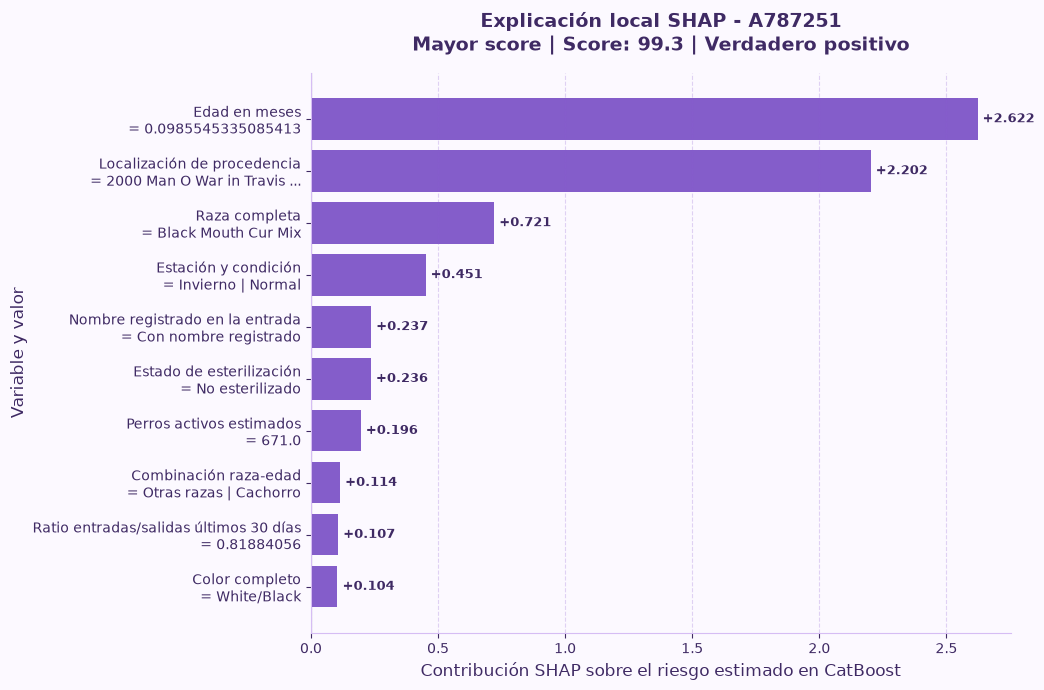

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\shap_local_A787251.png


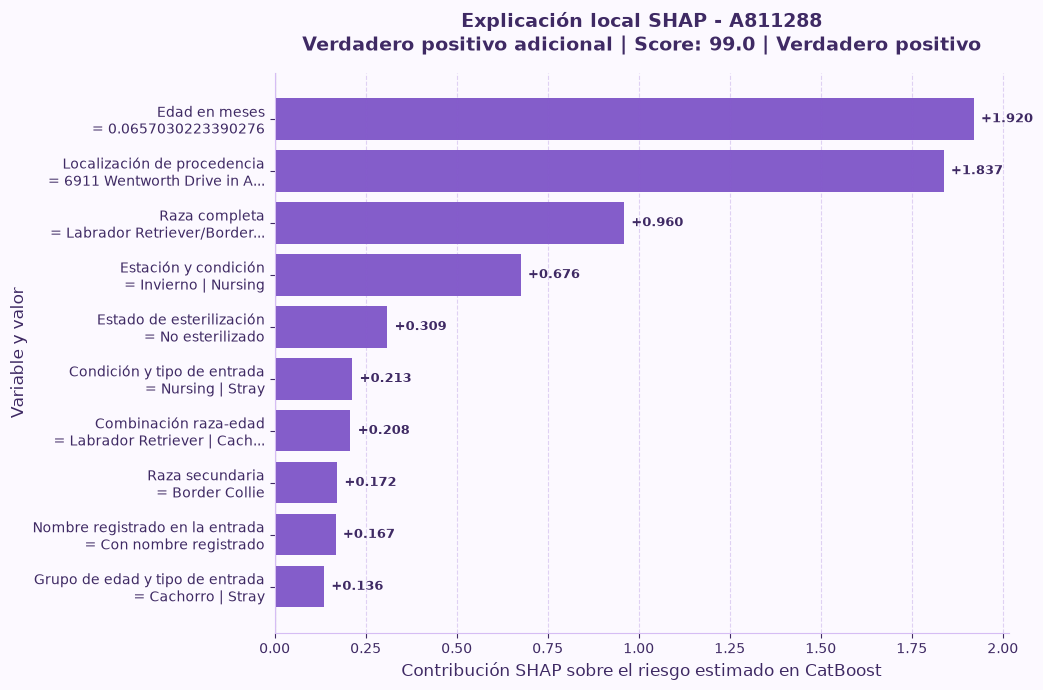

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\shap_local_A811288.png


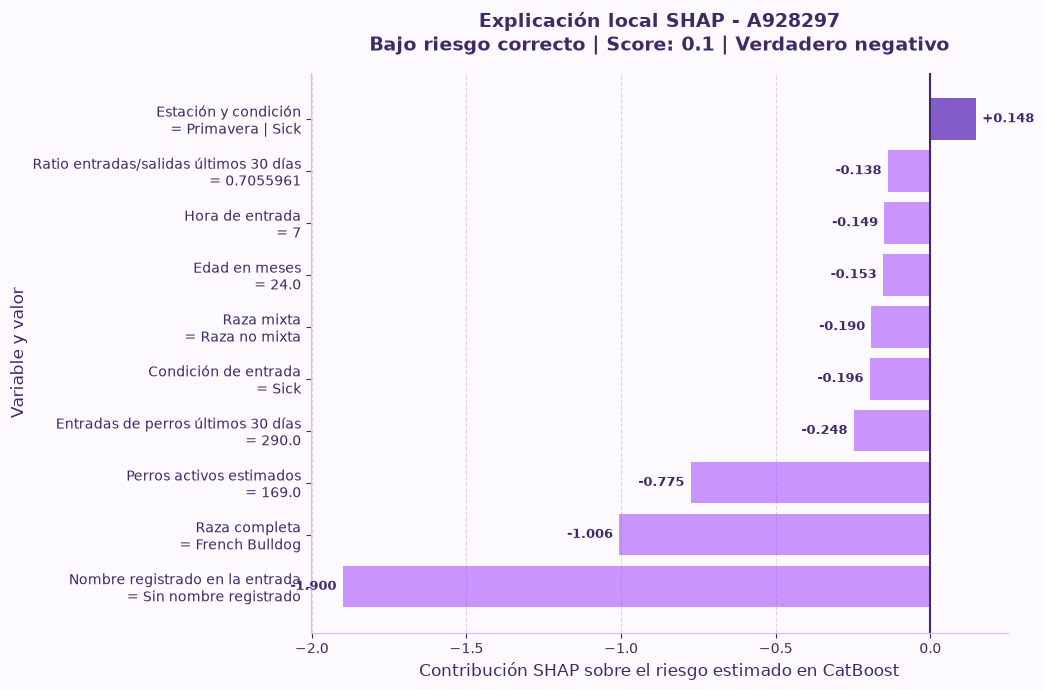

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\shap_local_A928297.png


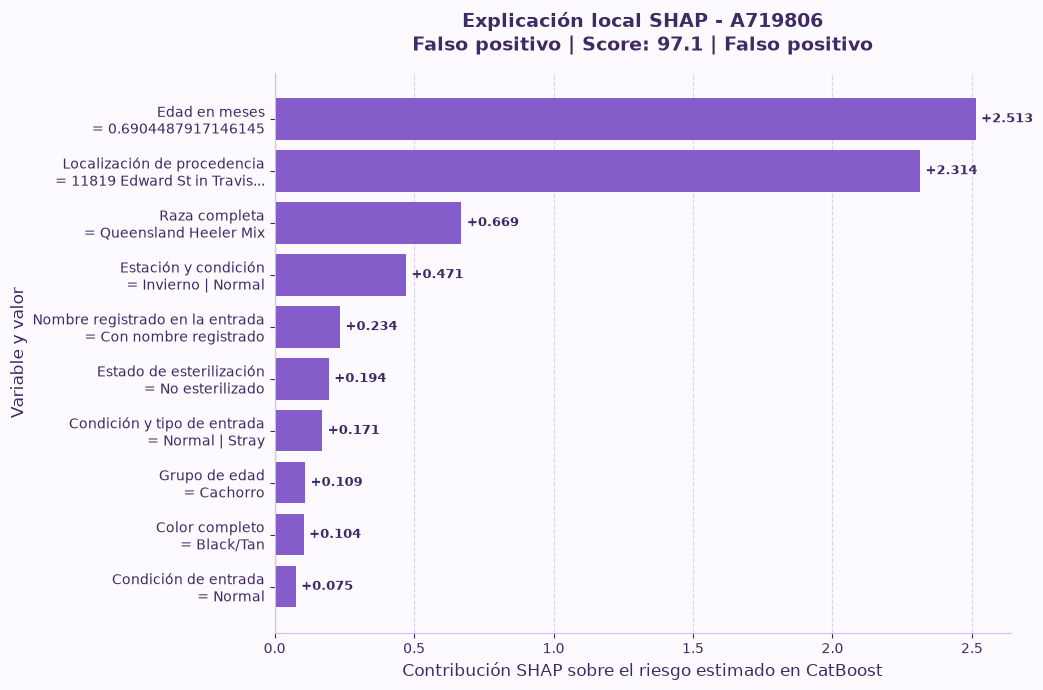

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\shap_local_A719806.png


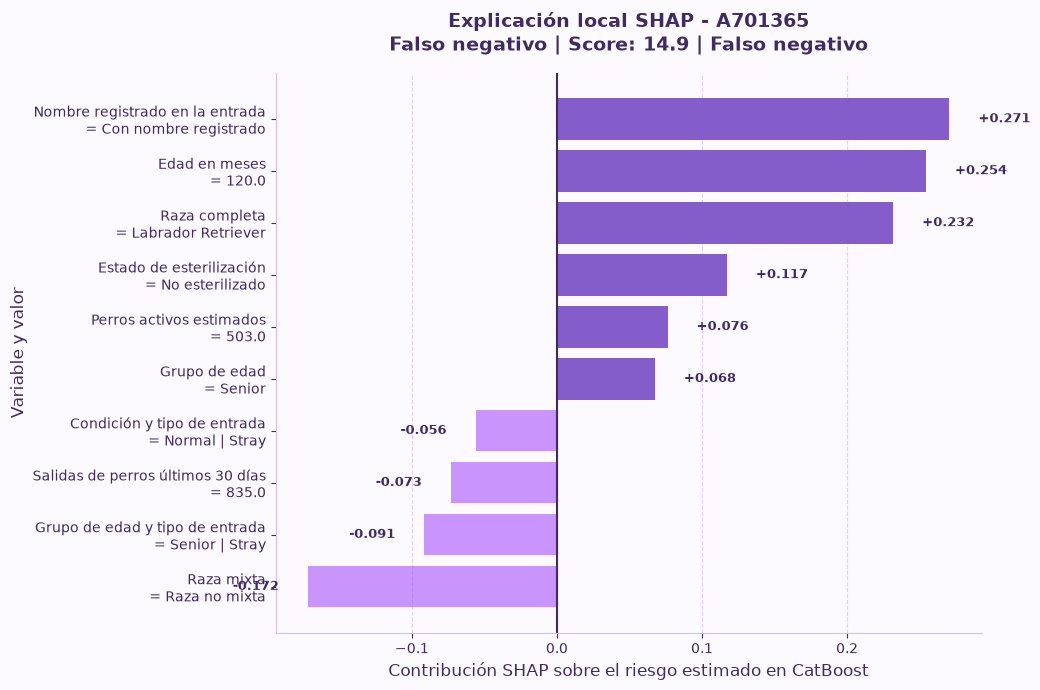

Gráfico guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\figures\shap_local_A701365.png


In [81]:
# Gráficos SHAP locales para ejemplos representativos

def graficar_shap_local(indice_original, nombre_archivo=None, top_n=10):
    posicion = indices_ejemplos_locales.index(indice_original)
    
    fila_ejemplo = tabla_ejemplos_interpretables.loc[
        tabla_ejemplos_interpretables["indice_original"] == indice_original
    ].iloc[0]
    
    valores_shap = shap_values_local[posicion]
    valores_variables = X_catboost_local.iloc[posicion]
    
    factores_df = pd.DataFrame({
        "variable": variables_catboost,
        "variable_legible": [nombre_variable_legible(v) for v in variables_catboost],
        "valor_variable": valores_variables.values,
        "shap_value": valores_shap,
        "abs_shap": np.abs(valores_shap)
    })
    
    factores_top = (
        factores_df
        .sort_values("abs_shap", ascending=False)
        .head(top_n)
        .sort_values("shap_value", ascending=True)
    )
    
    etiquetas = [
        f"{fila['variable_legible']}\n= {formatear_valor_variable(fila['valor_variable'], 28)}"
        for _, fila in factores_top.iterrows()
    ]
    
    colores = [
        "#6F42C1" if valor > 0 else "#C084FC"
        for valor in factores_top["shap_value"]
    ]
    
    fig, ax = plt.subplots(figsize=(10.5, 7))
    
    fig.patch.set_facecolor("#FCF9FF")
    ax.set_facecolor("#FCF9FF")
    
    ax.barh(
        etiquetas,
        factores_top["shap_value"],
        color=colores,
        alpha=0.85
    )
    
    ax.axvline(
        0,
        color="#3F2A64",
        linewidth=1.5
    )
    
    for i, valor in enumerate(factores_top["shap_value"]):
        desplazamiento = 0.02 if valor >= 0 else -0.02
        alineacion = "left" if valor >= 0 else "right"
        
        ax.text(
            valor + desplazamiento,
            i,
            f"{valor:+.3f}",
            va="center",
            ha=alineacion,
            fontsize=9,
            color="#3F2A64",
            fontweight="bold"
        )
    
    titulo = (
        f"Explicación local SHAP - {fila_ejemplo['animal_id']}\n"
        f"{fila_ejemplo['grupo_ejemplo']} | Score: {fila_ejemplo['invisible_dog_score']} | "
        f"{fila_ejemplo['tipo_resultado_modelo']}"
    )
    
    ax.set_title(
        titulo,
        fontsize=14,
        fontweight="bold",
        color="#3F2A64",
        pad=16
    )
    
    ax.set_xlabel(
        "Contribución SHAP sobre el riesgo estimado en CatBoost",
        fontsize=12,
        color="#3F2A64"
    )
    
    ax.set_ylabel("Variable y valor", fontsize=12, color="#3F2A64")
    
    ax.tick_params(axis="x", colors="#3F2A64")
    ax.tick_params(axis="y", colors="#3F2A64")
    
    ax.grid(axis="x", linestyle="--", alpha=0.25, color="#8A5BD3")
    ax.grid(axis="y", visible=False)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    
    ax.spines["left"].set_color("#D6BDF4")
    ax.spines["bottom"].set_color("#D6BDF4")
    
    fig.tight_layout()
    
    if nombre_archivo is None:
        nombre_archivo = f"shap_local_{fila_ejemplo['animal_id']}.png"
    
    fig_path = figures_path / nombre_archivo
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print("Gráfico guardado en:")
    print(fig_path)


# Selección de cuatro ejemplos representativos
ejemplos_para_graficar = (
    tabla_ejemplos_interpretables
    .groupby("grupo_ejemplo", observed=False)
    .head(1)
    ["indice_original"]
    .astype(int)
    .tolist()
)

for indice in ejemplos_para_graficar:
    graficar_shap_local(indice_original=indice, top_n=10)

El análisis SHAP local permite explicar las predicciones individuales del modelo para casos concretos.

En los perros con mayor score y en los verdaderos positivos, las variables con contribución positiva desplazan la predicción hacia un mayor riesgo estimado de larga estancia. En estos ejemplos aparecen factores relacionados con la edad, la raza, la localización de procedencia, la condición de entrada y el contexto operativo del refugio.

En los perros de bajo riesgo correctamente identificados, las contribuciones negativas reducen de forma clara el riesgo estimado. Esto permite comprobar que el modelo no asigna puntuaciones elevadas de forma generalizada, sino que diferencia entre perfiles con mayor y menor probabilidad de larga estancia.

Los falsos positivos muestran casos en los que el modelo detecta señales relevantes de riesgo, aunque finalmente el perro no supera el umbral de 30 días. Desde una perspectiva operativa, estos casos pueden considerarse menos críticos que los falsos negativos, ya que una mayor visibilidad o seguimiento adicional no perjudica al animal.

Los falsos negativos son especialmente importantes para futuras mejoras, ya que representan perros que finalmente tuvieron larga estancia pero no fueron priorizados inicialmente. Estos casos pueden estar asociados a perfiles poco frecuentes, trayectorias atípicas o factores no recogidos en el dataset, como comportamiento, fotografías, difusión externa o cambios posteriores en el estado del animal.

En conjunto, las explicaciones locales refuerzan que el Invisible Dog Score debe utilizarse como una herramienta de apoyo a la revisión y priorización, complementada siempre con criterio humano.

## 7. Propuesta de uso operativo del Invisible Dog Score

Una vez evaluado e interpretado el modelo, se plantea una propuesta de uso operativo del Invisible Dog Score en un contexto de refugio.

El objetivo no es automatizar decisiones sobre los animales, sino ofrecer una herramienta de apoyo que permita priorizar la revisión de aquellos perros con mayor riesgo estimado de larga estancia.

El score puede utilizarse para ordenar los casos, asignar bandas de riesgo y orientar acciones de visibilidad, revisión de ficha, seguimiento o difusión.

In [82]:
# Propuesta operativa por banda de riesgo

acciones_por_banda = pd.DataFrame([
    {
        "banda_riesgo": "Bajo riesgo",
        "rango_score": "0-24",
        "interpretacion": "Riesgo reducido de larga estancia",
        "accion_recomendada": "Seguimiento ordinario dentro del flujo habitual del refugio",
        "prioridad_operativa": "Baja"
    },
    {
        "banda_riesgo": "Riesgo medio",
        "rango_score": "25-49",
        "interpretacion": "Riesgo moderado de larga estancia",
        "accion_recomendada": "Revisar ficha, fotografías y visibilidad si existen recursos disponibles",
        "prioridad_operativa": "Media"
    },
    {
        "banda_riesgo": "Riesgo alto",
        "rango_score": "50-74",
        "interpretacion": "Riesgo elevado de larga estancia",
        "accion_recomendada": "Priorizar revisión de ficha, difusión y seguimiento temprano",
        "prioridad_operativa": "Alta"
    },
    {
        "banda_riesgo": "Riesgo crítico",
        "rango_score": "75-100",
        "interpretacion": "Riesgo muy elevado de larga estancia",
        "accion_recomendada": "Actuación prioritaria desde la entrada: revisión individual, campaña de visibilidad y seguimiento recurrente",
        "prioridad_operativa": "Muy alta"
    }
])

print("Propuesta operativa por banda de riesgo:")
display(acciones_por_banda)

Propuesta operativa por banda de riesgo:


,banda_riesgo,rango_score,interpretacion,accion_recomendada,prioridad_operativa
0,Bajo riesgo,0-24,Riesgo reducido de larga estancia,Seguimiento ordinario dentro del flujo habitua...,Baja
1,Riesgo medio,25-49,Riesgo moderado de larga estancia,"Revisar ficha, fotografías y visibilidad si ex...",Media
2,Riesgo alto,50-74,Riesgo elevado de larga estancia,"Priorizar revisión de ficha, difusión y seguim...",Alta
3,Riesgo crítico,75-100,Riesgo muy elevado de larga estancia,Actuación prioritaria desde la entrada: revisi...,Muy alta


In [83]:
# Guardado de la propuesta operativa por banda

acciones_por_banda_path = interpretability_path / "acciones_operativas_por_banda_riesgo.csv"

acciones_por_banda.to_csv(
    acciones_por_banda_path,
    index=False,
    encoding="utf-8-sig"
)

print("Propuesta operativa por banda guardada en:")
print(acciones_por_banda_path)

Propuesta operativa por banda guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\interpretability\acciones_operativas_por_banda_riesgo.csv


La propuesta operativa por bandas permite traducir el Invisible Dog Score a un esquema de actuación comprensible.

Los perros en bajo riesgo podrían mantenerse dentro del seguimiento ordinario, mientras que los perros en riesgo medio podrían revisarse si existen recursos disponibles. Las bandas de riesgo alto y crítico serían las más relevantes desde el punto de vista operativo, ya que concentran una mayor proporción real de casos de larga estancia.

De esta forma, el score no sustituye la valoración profesional del refugio, sino que ayuda a ordenar prioridades cuando los recursos de seguimiento, revisión de fichas o difusión son limitados.

## 8. Limitaciones y consideraciones éticas

El Invisible Dog Score debe interpretarse como una herramienta de apoyo a la decisión y no como una regla automática.

Aunque el modelo muestra una buena capacidad de priorización, existen limitaciones relevantes:

- el modelo se ha desarrollado con datos históricos de un refugio concreto;
- las predicciones pueden reflejar patrones y sesgos presentes en los datos originales;
- variables como raza, color o localización deben interpretarse con cautela;
- el dataset no incorpora información cualitativa relevante, como comportamiento, nivel de socialización, calidad de las fotografías, descripción pública del animal o campañas externas de difusión;
- un score alto no garantiza que un perro vaya a tener larga estancia;
- un score bajo no elimina completamente el riesgo;
- los falsos negativos siguen siendo especialmente relevantes, ya que representan perros que podrían necesitar atención temprana y no serían priorizados por el modelo.

Desde una perspectiva ética, el score no debe utilizarse para etiquetar negativamente a un animal, sino para ofrecerle más visibilidad, seguimiento y oportunidades de adopción. El objetivo del modelo es ayudar a detectar perros que podrían volverse invisibles dentro del refugio, no penalizarlos.


## 9. Mantenimiento y mejora futura

Para que el Invisible Dog Score pudiera utilizarse de forma robusta en un contexto real, sería necesario mantener y revisar periódicamente el modelo.

Algunas líneas de mejora futura serían:

- reentrenar el modelo con datos actualizados;
- monitorizar cambios en la distribución de entradas, salidas y adopciones;
- revisar periódicamente la precisión del score en los segmentos Top-K;
- analizar de forma recurrente los falsos negativos;
- incorporar nuevas variables relacionadas con comportamiento, fotografías, descripción del animal, difusión externa o interacción con posibles adoptantes;
- validar el modelo en otros refugios antes de generalizar su uso;
- revisar posibles sesgos asociados a raza, edad, color, localización o estado de entrada.

Estas mejoras permitirían reforzar la utilidad del score y adaptarlo a cambios en la operativa del refugio o en los patrones de adopción.


## 10. Conclusiones del notebook

En este notebook se ha interpretado el modelo final y se ha transformado su probabilidad estimada en una escala operativa denominada Invisible Dog Score.

El modelo final reproduce los resultados obtenidos en la fase de modelización, con un ROC-AUC de 0,8593, un Average Precision de 0,5721 y un F1-score de 0,5452 sobre el conjunto de prueba. Estos resultados confirman que el modelo mantiene una buena capacidad predictiva y una utilidad especialmente relevante como sistema de priorización. Además, los intervalos de confianza estimados mediante bootstrap permiten complementar las métricas puntuales con una lectura de estabilidad sobre el conjunto de prueba.

El análisis por bandas muestra que la tasa real de larga estancia aumenta de forma clara desde la banda de bajo riesgo hasta la banda de riesgo crítico. Además, el análisis Top-K confirma que el score concentra una proporción elevada de casos reales en los primeros segmentos del ranking: el Top 10 % alcanza una Precision@Top-K de 0,6103 y un lift de 3,9129 frente a una selección aleatoria.

La interpretación global mediante importancias de variables y SHAP muestra que el modelo combina información individual del perro, características de entrada, raza, localización, historial y contexto operativo del refugio. Las explicaciones locales permiten entender predicciones concretas y analizar tanto aciertos como errores.

En conjunto, el Invisible Dog Score convierte el modelo predictivo en una herramienta interpretable y accionable, orientada a detectar perros con mayor riesgo de larga estancia y apoyar decisiones de visibilidad, seguimiento y priorización dentro del refugio.
